# Extraction of SWR from CA1 recordings

Restarting from LFPwake0 and LFPwakeremoved.

LFPwakeremoved will be used to determined signal variance for threshold adjustement. 

LFPwake0 will be used for time determination. 

## Load LFP and packages

In [170]:
import sys
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / "util").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "util").is_dir():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

from util import config
import util.test_data_loader as tdl
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)
importlib.reload(tdl)
DataLoader = tdl.DataLoader

import importlib

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['Hp'] = '#63D15Aff'
    genotype_color['ArchT'] = '#FF9BD6ff'
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['WT'] = 'grey'
    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
"#7b62c5ff"
'#1F2A63'
'#C276A5'

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [ ]:

# ============================================================
# IMPORTANT: load aligned ephys via test_data_loader DataLoader

# This cell expects `dl` (util.test_data_loader.DataLoader) to be set for a specific row.
# Example:

#   metadata = load_metadata("combined")

#   meta_ephys = metadata[metadata['id'].isin(['AM','AN','AO'])]

#   dl = DataLoader(meta_ephys.iloc[0])

# ============================================================

# aligned LFP from derivatives through DataLoader.get_data('ephys')
lfp_ds = np.asarray(dl.get_data("ephys"), dtype=np.float32)  # (time, channels)
n_ds = lfp_ds.shape[0]

# sampling rate from alignment json (fallback to 1000 Hz)
out_dir = Path(dl.generate_preprocess_ephys_filepath())
save_prefix = out_dir.name
json_path = out_dir / f"{save_prefix}_alignment.json"
if not json_path.is_file():
    candidates = sorted(out_dir.glob("*_alignment.json"))
    if not candidates:
        raise FileNotFoundError(f"alignment json not found in {out_dir}")
    json_path = candidates[0]
info = json.loads(json_path.read_text())
fs_ds = float(info.get("fs_align") or info.get("fs_ds") or 1000.0)

print("Loaded aligned LFP:", lfp_ds.shape, "fs =", fs_ds)
print("Aligned source:", out_dir)

# ============================================================
# Optional: load raw TTL and map to DS indices for this same trial
# ============================================================
fs_raw = float(info.get("fs_raw") or 2000.0)
ratio = int(round(fs_raw / fs_ds)) if fs_ds > 0 else 2
assert ratio >= 1, "Invalid fs ratio"

rec_folder = Path(dl.generate_ephys_filepath())
ttl_folder = rec_folder / "events/Acquisition_Board-100.Rhythm Data/TTL"
cont_folder = rec_folder / "continuous/Acquisition_Board-100.Rhythm Data"

if (ttl_folder / "sample_numbers.npy").is_file() and (ttl_folder / "states.npy").is_file() and (cont_folder / "sample_numbers.npy").is_file():
    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states = np.load(ttl_folder / "states.npy")
    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    def extract_ttl1(sample_numbers, states):
        start_idx = np.where(states == 1)[0]
        end_idx = np.where(states == -1)[0]
        n = min(len(start_idx), len(end_idx))
        if n == 0:
            return np.zeros((0, 2), dtype=np.int64)
        pulses = np.stack([sample_numbers[start_idx[:n]], sample_numbers[end_idx[:n]]], axis=1)
        return pulses[pulses[:, 1] > pulses[:, 0]]

    pulses_raw = extract_ttl1(stim_samp, states)
    pulses_idx = (pulses_raw - cont0).astype(np.int64)
    pulses_ds = pulses_idx // ratio
    pulses_ds[:, 0] = np.clip(pulses_ds[:, 0], 0, n_ds - 1)
    pulses_ds[:, 1] = np.clip(pulses_ds[:, 1], 0, n_ds - 1)
    pulses_ds = pulses_ds[pulses_ds[:, 1] > pulses_ds[:, 0]]
else:
    pulses_ds = np.zeros((0, 2), dtype=np.int64)

print("TTL pulses (DS):", pulses_ds.shape)

NameError: name 'dl' is not defined

In [7]:
# -----------------------------
# Helpers (kept at module level)
# -----------------------------
KEYS = ["sub", "id", "date", "ses", "trial_id", "trial_type", "trial_type_day"]
NUMERIC_KEYS = ["sub", "ses", "trial_id", "trial_type_day"]
STRING_KEYS = ["id", "date", "trial_type"]
OVERWRITE_COLS = ["usable", "trial note"]

def _to_int_nullable(s: pd.Series) -> pd.Series:
    """Coerce to pandas nullable Int64 (keeps NA as <NA>)."""
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def _ensure_keys(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure all key columns exist, with normalized dtypes."""
    df = df.copy()
    for k in KEYS:
        if k not in df.columns:
            df[k] = pd.NA
    for c in NUMERIC_KEYS:
        df[c] = _to_int_nullable(df[c])
    for c in STRING_KEYS:
        df[c] = df[c].astype("string")
    return df

def _key_index(df: pd.DataFrame) -> pd.MultiIndex:
    return pd.MultiIndex.from_frame(df[KEYS])

def _normalize_animal_info(animal_info: pd.DataFrame) -> pd.DataFrame:
    animal_info = animal_info.copy()
    if "sub" in animal_info.columns:
        animal_info["sub"] = _to_int_nullable(animal_info["sub"])
    if "id" in animal_info.columns:
        animal_info["id"] = animal_info["id"].astype("string")
    return animal_info

def _normalize_ephys(ephys_info: pd.DataFrame) -> pd.DataFrame:
    ephys = _ensure_keys(ephys_info)

    if "ephys_trial_id" not in ephys.columns:
        ephys["ephys_trial_id"] = pd.NA
    if "ephys_usable" not in ephys.columns:
        ephys["ephys_usable"] = pd.NA

    ephys["ephys_trial_id"] = _to_int_nullable(ephys["ephys_trial_id"])
    ephys["ephys_usable"] = _to_int_nullable(ephys["ephys_usable"])

    if "usable" in ephys.columns:
        ephys["usable"] = _to_int_nullable(ephys["usable"])
    if "trial note" in ephys.columns:
        ephys["trial note"] = ephys["trial note"].astype("string")
    return ephys

def _merge_ephys(meta: pd.DataFrame, ephys: pd.DataFrame) -> pd.DataFrame:
    bring = []
    if "ephys_trial_id" in ephys.columns:
        bring.append("ephys_trial_id")
    if "ephys_usable" in ephys.columns:
        bring.append("ephys_usable")

    overwrite_cols = []
    for c in OVERWRITE_COLS:
        if c in meta.columns and c in ephys.columns:
            overwrite_cols.append(c)
            bring.append(c)

    ephys_merge = ephys[KEYS + bring].copy()
    merged = meta.merge(ephys_merge, on=KEYS, how="left", suffixes=("", "_ephys"))

    for c in overwrite_cols:
        c_e = f"{c}_ephys"
        if c_e in merged.columns:
            use_e = merged[c_e].notna() & (merged[c_e] != merged[c])
            merged.loc[use_e, c] = merged.loc[use_e, c_e]
            merged = merged.drop(columns=[c_e])

    if "usable" in merged.columns:
        merged["usable"] = _to_int_nullable(merged["usable"])
    if "ephys_trial_id" in merged.columns:
        merged["ephys_trial_id"] = _to_int_nullable(merged["ephys_trial_id"])
    if "ephys_usable" in merged.columns:
        merged["ephys_usable"] = _to_int_nullable(merged["ephys_usable"])
    return merged

def _append_ephys_only(merged: pd.DataFrame, meta: pd.DataFrame, ephys: pd.DataFrame, animal_info: pd.DataFrame) -> pd.DataFrame:
    base_keys_idx = _key_index(meta.drop_duplicates(KEYS))
    ephys_keys_idx = _key_index(ephys.drop_duplicates(KEYS))
    is_new = ~ephys_keys_idx.isin(base_keys_idx)
    if not np.any(is_new):
        return merged

    ephys_only = ephys.loc[is_new].copy()
    ephys_only = ephys_only.drop_duplicates(subset=KEYS, keep="first")
    ephys_only = ephys_only.merge(animal_info, on=["sub", "id"], how="left", suffixes=("", "_animal"))

    for col in merged.columns:
        if col not in ephys_only.columns:
            ephys_only[col] = pd.NA
    for col in ephys_only.columns:
        if col not in merged.columns:
            merged[col] = pd.NA

    ephys_only = ephys_only[merged.columns]
    return pd.concat([merged, ephys_only], ignore_index=True)

def load_metadata(type: str = "combined") -> pd.DataFrame:
    """
    Read metadata files and optionally combine trials + animals + ephys.

    ephys merge rules:
      - merge on keys: ['sub','id','date','ses','trial_id','trial_type','trial_type_day']
      - add ephys_info columns: ephys_trial_id, ephys_usable
      - overwrite meta['usable'] and meta['trial note'] using ephys values when they differ (and ephys is non-null)
      - append ephys-only rows (keys present in ephys but not in meta)
    """
    animal_info = pd.read_csv(config.animal_info_path)
    trial_info = pd.read_csv(config.trial_info_path)
    ephys_info = pd.read_csv(config.ephys_info_path)

    if type == "animals":
        return animal_info
    if type == "trials":
        return trial_info
    if type == "ephys":
        return ephys_info
    if type != "combined":
        raise ValueError("type must be one of: 'combined', 'animals', 'trials', 'ephys'")

    trial_info_n = _ensure_keys(trial_info)
    animal_info_n = _normalize_animal_info(animal_info)
    meta = trial_info_n.merge(animal_info_n, on=["sub", "id"], how="left")

    if "usable" in meta.columns:
        meta["usable"] = _to_int_nullable(meta["usable"])
    if "trial note" in meta.columns:
        meta["trial note"] = meta["trial note"].astype("string")

    ephys = _normalize_ephys(ephys_info)
    merged = _merge_ephys(meta, ephys)
    merged = _append_ephys_only(merged, meta, ephys, animal_info_n)

    merged = merged.sort_values(by=KEYS, kind="mergesort").reset_index(drop=True)
    return merged

In [8]:
metadata = load_metadata("combined")
dl = DataLoader(metadata.iloc[1395])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

meta_ephys = metadata[
    (metadata['id'].isin(['AM', 'AN','AO'])) ]

meta_ephys

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note,ephys_trial_id,ephys_usable
1507,16,AM,20250725,1,1,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1508,16,AM,20250725,1,2,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1509,16,AM,20250725,1,3,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1510,16,AM,20250725,1,4,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
1511,16,AM,20250725,1,5,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3147,18,AO,20251011,47,11,T,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",19,1
3148,18,AO,20251012,48,0,B,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",1,1
3149,18,AO,20251012,48,1,T,1,NaN,0,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",2,0
3150,18,AO,20251012,48,2,B,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",4,1


In [9]:

def bandpass_150_250(x, fs, order=4):
    """Stable zero-phase bandpass using SOS."""
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    sos = signal.butter(order, [150/nyq, 250/nyq], btype="bandpass", output="sos")
    return signal.sosfiltfilt(sos, x)

def contiguous_segments(mask):
    """Return list of (start, end) index pairs for True segments in a boolean mask."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    edges = np.diff(mask.astype(np.int8), prepend=0, append=0)
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0]
    return list(zip(starts, ends))

def events_from_mask(mask, fs, min_dur_ms=15, envelope=None):
    """
    Convert threshold mask into events with start/end/peak.
    envelope: optional array for peak finding (defaults to None).
    """
    min_len = int(round(fs * min_dur_ms / 1000.0))
    ev = []
    for s, e in contiguous_segments(mask):
        if (e - s) < min_len:
            continue
        if envelope is None:
            peak = (s + e) // 2
            pkval = np.nan
        else:
            peak = s + int(np.argmax(envelope[s:e]))
            pkval = float(envelope[peak])
        ev.append(dict(start=s, end=e, peak=peak, peak_value=pkval,
                       start_s=s/fs, end_s=e/fs, peak_s=peak/fs,
                       duration_ms=(e - s) * 1000.0 / fs))
    return ev

1️⃣ Define STIM / NO-STIM / PRE-STIM masks (train-based)

In [64]:
import numpy as np
import pandas as pd
import json
from pathlib import Path


def _find_session_root_from_dat(dat_path: Path, max_up=12):
    p = Path(dat_path).resolve()
    for _ in range(max_up):
        if (p / "structure.oebin").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


def _load_open_ephys_continuous_dat(dat_path):
    dat_path = Path(dat_path).resolve()
    if not dat_path.is_file():
        raise FileNotFoundError(f"continuous.dat not found: {dat_path}")

    stream_dir = dat_path.parent
    session_root = _find_session_root_from_dat(dat_path)
    if session_root is None:
        raise OSError(f"Could not find structure.oebin above: {dat_path}")

    oebin_path = session_root / "structure.oebin"
    if not oebin_path.is_file():
        raise OSError(f"structure.oebin not found: {oebin_path}")

    meta = json.loads(oebin_path.read_text())
    cont_entries = meta.get("continuous", [])
    if not cont_entries:
        raise OSError("structure.oebin has no 'continuous' entries")

    stream_entry = None
    for entry in cont_entries:
        folder_name = entry.get("folder_name") or entry.get("folder") or ""
        if Path(folder_name).name == stream_dir.name:
            stream_entry = entry
            break

    if stream_entry is None and len(cont_entries) == 1:
        stream_entry = cont_entries[0]
    if stream_entry is None:
        raise OSError(f"Could not match stream '{stream_dir.name}' in structure.oebin")

    num_ch = stream_entry.get("num_channels") or stream_entry.get("numChannels")
    if num_ch is None:
        raise OSError("structure.oebin missing num_channels for continuous stream")

    file_bytes = dat_path.stat().st_size
    denom = 2 * int(num_ch)
    if file_bytes % denom != 0:
        raise OSError("continuous.dat size not divisible by 2*num_channels")

    n_samples = file_bytes // denom
    data = np.memmap(dat_path, dtype=np.int16, mode="r", shape=(n_samples, int(num_ch)))

    fs = None
    for k in ("sample_rate", "sampleRate", "sampling_rate", "sampleRateHz"):
        if stream_entry.get(k) is not None:
            fs = float(stream_entry.get(k))
            break
    if fs is None:
        fs = 2000.0

    return data, fs


def _extract_ttl_pulses_raw(sample_numbers, states):
    sample_numbers = np.asarray(sample_numbers)
    states = np.asarray(states)

    start_idx = np.where(states == 1)[0]
    end_idx = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    if n == 0:
        return np.zeros((0, 2), dtype=np.int64)

    pulses = np.stack([sample_numbers[start_idx[:n]], sample_numbers[end_idx[:n]]], axis=1)
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    return pulses.astype(np.int64)


def _build_stim_mask_from_trains(
    n_samples,
    pulses_ds,
    fs,
    gap_s=1.0,
    pre_s=0.0,
    post_s=0.0,
):
    """Build STIM mask from TTL trains grouped by start-to-start gap."""
    stim_mask = np.zeros(n_samples, dtype=bool)

    if pulses_ds is None or len(pulses_ds) == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    pulses = np.asarray(pulses_ds, dtype=np.int64).copy()
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    if pulses.size == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    order = np.argsort(pulses[:, 0])
    pulses = pulses[order]

    starts = pulses[:, 0]
    ends = pulses[:, 1]

    gap = int(round(gap_s * fs))
    pre = int(round(pre_s * fs))
    post = int(round(post_s * fs))

    trains = []
    cur_start = int(starts[0])
    cur_end = int(ends[0])

    for i in range(1, len(pulses)):
        if (int(starts[i]) - int(starts[i - 1])) > gap:
            trains.append((cur_start, cur_end))
            cur_start = int(starts[i])
            cur_end = int(ends[i])
        else:
            cur_end = max(cur_end, int(ends[i]))

    trains.append((cur_start, cur_end))

    trains_ds = []
    for s, e in trains:
        s0 = max(0, s - pre)
        e0 = min(n_samples, e + post)
        if e0 > s0:
            stim_mask[s0:e0] = True
            trains_ds.append((s0, e0))

    trains_ds = np.asarray(trains_ds, dtype=np.int64)

    trains_table = pd.DataFrame({
        "train_idx": np.arange(len(trains_ds), dtype=int),
        "start_s": trains_ds[:, 0] / fs if len(trains_ds) else [],
        "end_s": trains_ds[:, 1] / fs if len(trains_ds) else [],
    })
    if len(trains_table):
        trains_table["duration_s"] = trains_table["end_s"] - trains_table["start_s"]

    return stim_mask, trains_ds, trains_table


def _build_pre_stim_mask_before_first_train(
    n_samples: int,
    stim_trains_ds: np.ndarray,
    fs: float,
    pre_window_s: float = 5.0,
):
    """
    Pre-stim mask = the window immediately BEFORE the *first* TTL train start.
    If there is < pre_window_s available from t=0, use whatever exists.

    Returns:
      pre_stim_mask (bool, length n_samples),
      pre_stim_seconds (float),
      pre_start_idx, pre_end_idx (int, sample indices)
    """
    pre_stim_mask = np.zeros(n_samples, dtype=bool)
    if stim_trains_ds is None or len(stim_trains_ds) == 0:
        return pre_stim_mask, 0.0, None, None

    trains = np.asarray(stim_trains_ds, dtype=np.int64)
    trains = trains[trains[:, 1] > trains[:, 0]]
    if trains.size == 0:
        return pre_stim_mask, 0.0, None, None

    first_start = int(np.min(trains[:, 0]))
    first_start = max(0, min(first_start, n_samples))

    pre_len = int(round(float(pre_window_s) * float(fs)))
    pre_start = max(0, first_start - pre_len)
    pre_end = first_start

    if pre_end > pre_start:
        pre_stim_mask[pre_start:pre_end] = True

    pre_stim_seconds = float(pre_stim_mask.sum() / fs)
    return pre_stim_mask, pre_stim_seconds, pre_start, pre_end


# ----------------------------
# Build masks from RAW ephys + RAW TTL (no alignment json, no shift correction)
# only trial_type != B and ephys_trial_id available
# ----------------------------
meta_for_masks = meta_ephys.copy()
meta_for_masks["ephys_trial_id_num"] = pd.to_numeric(meta_for_masks.get("ephys_trial_id", pd.NA), errors="coerce")
trial_type_upper = meta_for_masks["trial_type"].astype(str).str.upper()

valid_rows = meta_for_masks[
    meta_for_masks["ephys_trial_id_num"].notna()
    & (meta_for_masks["ephys_trial_id_num"] > 0)
    & (trial_type_upper != "B")
].reset_index(drop=True)

if len(valid_rows) == 0:
    raise ValueError("No valid rows found (need ephys_trial_id > 0 and trial_type != 'B').")

selected_trial_idx = 0  # change this to inspect another valid trial
if selected_trial_idx < 0 or selected_trial_idx >= len(valid_rows):
    raise IndexError(f"selected_trial_idx out of range: {selected_trial_idx} (n_valid={len(valid_rows)})")

row = valid_rows.iloc[selected_trial_idx]
dl = DataLoader(metadata_ses=row)

rec_dir = Path(dl.generate_ephys_filepath())
cont_cands = sorted(rec_dir.glob("continuous/*/continuous.dat"))
if not cont_cands:
    raise FileNotFoundError(f"No continuous.dat found under {rec_dir / 'continuous'}")

# Prefer stream with TTL files
continuous_dat = None
cont_folder = None
ttl_folder = None
for cd in cont_cands:
    cf = cd.parent
    tf = rec_dir / "events" / cf.name / "TTL"
    if (tf / "sample_numbers.npy").is_file() and (tf / "states.npy").is_file() and (cf / "sample_numbers.npy").is_file():
        continuous_dat, cont_folder, ttl_folder = cd, cf, tf
        break
if continuous_dat is None:
    continuous_dat = cont_cands[0]
    cont_folder = continuous_dat.parent
    ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"

lfp_raw, fs = _load_open_ephys_continuous_dat(continuous_dat)
lfp_raw = np.asarray(lfp_raw, dtype=np.float32)
n = lfp_raw.shape[0]

# ---- load raw TTL pulses into LFP sample indices ----
pulses_idx = np.zeros((0, 2), dtype=np.int64)
if (ttl_folder / "sample_numbers.npy").is_file() and (ttl_folder / "states.npy").is_file() and (cont_folder / "sample_numbers.npy").is_file():
    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states = np.load(ttl_folder / "states.npy")
    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    pulses_raw = _extract_ttl_pulses_raw(stim_samp, states)
    pulses_idx = (pulses_raw - cont0).astype(np.int64)
    if pulses_idx.size:
        pulses_idx[:, 0] = np.clip(pulses_idx[:, 0], 0, n)
        pulses_idx[:, 1] = np.clip(pulses_idx[:, 1], 0, n)
        pulses_idx = pulses_idx[pulses_idx[:, 1] > pulses_idx[:, 0]]

# ---- build STIM trains + mask ----
stim_mask, stim_trains_ds, stim_trains_table = _build_stim_mask_from_trains(
    n_samples=n,
    pulses_ds=pulses_idx,   # pulses in sample indices
    fs=fs,
    gap_s=1.0,
    pre_s=0.0,
    post_s=0.0,
)

# ---- pre-stim mask = 5s immediately before first train ----
pre_stim_mask, pre_stim_seconds, pre_start_idx, pre_end_idx = _build_pre_stim_mask_before_first_train(
    n_samples=n,
    stim_trains_ds=stim_trains_ds,
    fs=fs,
    pre_window_s=5.0,
)

# ---- IMPORTANT: make masks disjoint ----
pre_stim_mask = pre_stim_mask & (~stim_mask)                 # safety
nostim_mask   = (~stim_mask) & (~pre_stim_mask)              # STIM_OFF excludes PRE_STIM
baseline_mask = nostim_mask                                  # threshold baseline


display(stim_trains_table)
print("Using RAW ephys from:", continuous_dat)
print("id:", row.get("id", None), "ses:", row.get("ses", None), "trial_id:", row.get("trial_id", None), "ephys_trial_id:", row.get("ephys_trial_id", None))
print("n ttl pulses:", int(len(pulses_idx)))
print("n stim trains:", int(len(stim_trains_table)))
print("stim samples:", int(stim_mask.sum()), "(", stim_mask.sum()/fs, "s )")
print("no-stim samples:", int(nostim_mask.sum()), "(", nostim_mask.sum()/fs, "s )")
print("pre-stim seconds:", pre_stim_seconds)
if pre_start_idx is not None:
    print("pre-stim window (s):", pre_start_idx/fs, "->", pre_end_idx/fs)

,train_idx,start_s,end_s,duration_s
0,0,43.152,43.3620,0.2100
1,1,79.418,84.9585,5.5405


Using RAW ephys from: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-02_ephys/continuous/Acquisition_Board-100.Rhythm Data/continuous.dat
id: AM ses: 3 trial_id: 1 ephys_trial_id: 2
n ttl pulses: 35
n stim trains: 2
stim samples: 11501 ( 5.7505 s )
no-stim samples: 314115 ( 157.0575 s )
pre-stim seconds: 5.0
pre-stim window (s): 38.152 -> 43.152


Prepare bipolar CA1 signal (important!)

In [ ]:
def bipolar(lfp, ch1, ch2):
    return np.asarray(lfp[:, ch1] - lfp[:, ch2], dtype=np.float32)

# # Jadhav (Hilbert envelope + Gaussian smooth + 3 SD, ≥15 ms)

In [54]:
from scipy import signal
from scipy.ndimage import gaussian_filter1d

def detect_swr_jadhav(
    x, fs, baseline_mask,
    band=(150, 250),
    order=4,
    smooth_ms=4,
    thr_sd=3,
    min_dur_ms=15
):
    # Bandpass
    nyq = 0.5 * fs
    Wn = [band[0]/nyq, band[1]/nyq]
    sos = signal.cheby2(
        N=order,
        rs=20,              # stopband attenuation (dB)
        Wn=Wn,
        btype="bandpass",
        output="sos"
    )
    x_f = signal.sosfiltfilt(sos, x)

    # Envelope
    env = np.abs(signal.hilbert(x_f))

    # Smooth envelope (Gaussian)
    sigma = smooth_ms * fs / 1000
    env_s = gaussian_filter1d(env, sigma=sigma)

    # Baseline stats
    mu = env_s[baseline_mask].mean()
    sd = env_s[baseline_mask].std()
    thr = mu + thr_sd * sd

    # Detect threshold crossings
    above = env_s > thr
    min_len = int(min_dur_ms * fs / 1000)

    events = []
    in_evt = False
    start = 0

    for i, v in enumerate(above):
        if v and not in_evt:
            in_evt = True
            start = i
        elif not v and in_evt:
            if i - start >= min_len:
                events.append((start, i))
            in_evt = False

    return {
        "events": np.array(events),
        "env": env_s,
        "threshold": thr
    }

Method 2 — Kuga (ripple-band RMS in 10 ms bins + 3 SD above baseline, ≥15 ms)


In [ ]:
def detect_swr_kuga(
    x, fs, baseline_mask,
    band=(150, 250),
    order=4,
    bin_ms=10,
    thr_sd=3,
    min_dur_ms=15
):
    # Bandpass
    nyq = 0.5 * fs
    Wn = [band[0]/nyq, band[1]/nyq]
    sos = signal.cheby2(
        N=order,
        rs=20,
        Wn=Wn,
        btype="bandpass",
        output="sos"
    )
    x_f = signal.sosfiltfilt(sos, x)

    # RMS envelope
    win = int(bin_ms * fs / 1000)
    rms = np.sqrt(signal.convolve(x_f**2, np.ones(win)/win, mode="same"))

    # Baseline stats
    mu = rms[baseline_mask].mean()
    sd = rms[baseline_mask].std()
    thr = mu + thr_sd * sd

    # Detect events
    above = rms > thr
    min_len = int(min_dur_ms * fs / 1000)

    events = []
    in_evt = False
    start = 0

    for i, v in enumerate(above):
        if v and not in_evt:
            in_evt = True
            start = i
        elif not v and in_evt:
            if i - start >= min_len:
                events.append((start, i))
            in_evt = False

    return {
        "events": np.array(events),
        "rms": rms,
        "threshold": thr
    }

# computes overlap between detections from the Jadhav and Kuga methods
it finds a peak index for each detected event using each method’s own signal

In [ ]:
lfp_use = np.asarray(globals().get("lfp_raw", globals().get("lfp_ds")), dtype=np.float32)
if lfp_use is None or lfp_use.size == 0:
    raise RuntimeError("No LFP loaded. Run raw mask/LFP cell first.")
fs = float(globals().get("fs", globals().get("fs_ds", 2000.0)))
n = lfp_use.shape[0]

# Channel pairs
pairs = {
    "RIGHT": (9, 15),
    "LEFT":  (25, 27)
}

results = {}

for hemi, (c1, c2) in pairs.items():
    x = bipolar(lfp_use, c1, c2)

    res_j = detect_swr_jadhav(x, fs, baseline_mask)
    res_k = detect_swr_kuga(x, fs, baseline_mask)

    results[hemi] = {
        "Jadhav": res_j,
        "Kuga": res_k
    }

    print(f"{hemi}: Jadhav={len(res_j['events'])}, Kuga={len(res_k['events'])}")

def event_peaks_from_envelope(envelope, events):
    """Return peak index (sample) for each event, using envelope maximum inside event."""
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)

def match_peaks(peaks_a, peaks_b, tol_samp):
    """Greedy match peaks within tol; returns n_match, unmatched_a, unmatched_b."""
    peaks_a = np.sort(np.asarray(peaks_a, dtype=np.int64))
    peaks_b = np.sort(np.asarray(peaks_b, dtype=np.int64))
    i = j = 0
    matched = 0
    used_b = []
    while i < len(peaks_a) and j < len(peaks_b):
        da = peaks_a[i] - peaks_b[j]
        if abs(da) <= tol_samp:
            matched += 1
            i += 1
            j += 1
        elif da < 0:
            i += 1
        else:
            j += 1
    return matched

def overlap_report(results, hemi, fs, match_ms=20):
    j = results[hemi]["Jadhav"]
    k = results[hemi]["Kuga"]

    # use their own detection signals to define event peaks
    j_peaks = event_peaks_from_envelope(j["env"], j["events"])
    k_peaks = event_peaks_from_envelope(k["rms"], k["events"])

    tol = int(round(match_ms * fs / 1000))
    n_match = match_peaks(j_peaks, k_peaks, tol)

    nJ = len(j["events"])
    nK = len(k["events"])
    prec = n_match / nK if nK else np.nan   # "of Kuga, how many are also in Jadhav"
    rec  = n_match / nJ if nJ else np.nan   # "of Jadhav, how many are also in Kuga"

    print(f"{hemi} overlap (±{match_ms} ms): matched={n_match}")
    print(f"  Jadhav={nJ}, Kuga={nK}")
    print(f"  precision(K→J)={prec:.2f}, recall(J→K)={rec:.2f}")

# Run
fs = float(globals().get("fs", globals().get("fs_ds", 2000.0)))
overlap_report(results, "RIGHT", fs, match_ms=20)
overlap_report(results, "LEFT",  fs, match_ms=20)


# SWR detection and plot


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def event_peak_indices(events, envelope=None):
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        if envelope is None:
            peaks.append((s + e) // 2)
        else:
            peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)

def events_by_mask(events, peaks, mask):
    out = []
    for ev, pk in zip(events, peaks):
        if mask[pk]:
            out.append(ev)
    return np.asarray(out, dtype=int)

def spectral_peak_freqs(x, fs, events, band=(150, 250)):
    freqs_out = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        seg = np.asarray(x[s:e], dtype=np.float32)
        if seg.size < 16:
            continue
        seg = seg - np.mean(seg)
        win = np.hanning(seg.size)
        spec = np.fft.rfft(seg * win)
        pxx = np.abs(spec) ** 2
        freqs = np.fft.rfftfreq(seg.size, d=1 / fs)
        sel = (freqs >= band[0]) & (freqs <= band[1])
        if not np.any(sel):
            continue
        fpk = freqs[sel][np.argmax(pxx[sel])]
        freqs_out.append(float(fpk))
    return np.asarray(freqs_out, dtype=float)

def peak_freqs_per_event(x, fs, events, band=(150, 250)):
    freqs_out = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            freqs_out.append(np.nan)
            continue
        seg = np.asarray(x[s:e], dtype=np.float32)
        if seg.size < 16:
            freqs_out.append(np.nan)
            continue
        seg = seg - np.mean(seg)
        win = np.hanning(seg.size)
        spec = np.fft.rfft(seg * win)
        pxx = np.abs(spec) ** 2
        freqs = np.fft.rfftfreq(seg.size, d=1 / fs)
        sel = (freqs >= band[0]) & (freqs <= band[1])
        if not np.any(sel):
            freqs_out.append(np.nan)
            continue
        fpk = freqs[sel][np.argmax(pxx[sel])]
        freqs_out.append(float(fpk))
    return np.asarray(freqs_out, dtype=float)

def incidence_rate_hz(n_events, mask, fs):
    dur_s = mask.sum() / fs
    return (n_events / dur_s) if dur_s > 0 else np.nan

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(width=1.2, length=4)

# ----------------------------
# Compute SWR peak frequencies per condition (RAW, TTL-train masks)
# ----------------------------
method = "Jadhav"
band_peak = (150, 250)
fs = float(globals().get("fs", globals().get("fs_ds", 2000.0)))
lfp_plot = np.asarray(globals().get("lfp_raw", globals().get("lfp_ds")), dtype=np.float32)
if lfp_plot is None or lfp_plot.size == 0:
    raise RuntimeError("No LFP loaded. Run raw mask/LFP cell first.")

peakfreq_stim = []
peakfreq_stim_off = []
n_stim = 0
n_stim_off = 0
ev_stim_all = []
ev_stim_off_all = []
x_by_hemi = {}

for hemi, (c1, c2) in pairs.items():
    x = bipolar(lfp_plot, c1, c2)
    x_by_hemi[hemi] = x
    res = results[hemi][method]
    env = res.get("env", res.get("rms", None))
    events = np.asarray(res["events"]) if len(res["events"]) else np.empty((0, 2), dtype=int)
    peaks = event_peak_indices(events, envelope=env)

    ev_stim = events_by_mask(events, peaks, stim_mask)
    ev_stim_off = events_by_mask(events, peaks, nostim_mask)

    peakfreq_stim.extend(spectral_peak_freqs(x, fs, ev_stim, band=band_peak))
    peakfreq_stim_off.extend(spectral_peak_freqs(x, fs, ev_stim_off, band=band_peak))

    ev_stim_all.append((hemi, ev_stim))
    ev_stim_off_all.append((hemi, ev_stim_off))

    n_stim += len(ev_stim)
    n_stim_off += len(ev_stim_off)

peakfreq_stim = np.asarray(peakfreq_stim)
peakfreq_stim_off = np.asarray(peakfreq_stim_off)

bins = np.arange(band_peak[0], band_peak[1] + 2, 2)
bin_w = bins[1] - bins[0]
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), sharey=True)

c_off, _ = np.histogram(peakfreq_stim_off, bins=bins)
c_st, _ = np.histogram(peakfreq_stim, bins=bins)
for ax in axes:
    ax.bar(bins[:-1], c_off, width=bin_w, align="edge", alpha=0.45, color="#7f7f7f", edgecolor="black", linewidth=0.9, label="STIM_OFF")
    ax.bar(bins[:-1], c_st, width=bin_w, align="edge", alpha=0.45, color="#D55E00", edgecolor="black", linewidth=0.9, label="STIM")
    ax.set_title("SWR peak frequency")
    ax.set_xlabel("Frequency (Hz)")
    ax.legend(frameon=False)
    style_axes(ax)
axes[0].set_ylabel("Count")
plt.tight_layout(); plt.show()

def durations_with_peak_ge(events_list, x_lookup, fs, band=(150, 250), min_peak_hz=140):
    out = []
    for hemi, events in events_list:
        if len(events) == 0:
            continue
        x = x_lookup[hemi]
        peak_f = peak_freqs_per_event(x, fs, events, band=band)
        events = np.asarray(events, dtype=int)
        durs_ms = (events[:, 1] - events[:, 0]) * 1000.0 / fs
        keep = (peak_f >= min_peak_hz) & np.isfinite(peak_f)
        out.extend(durs_ms[keep].astype(float))
    return np.asarray(out, dtype=float)

dur_stim = durations_with_peak_ge(ev_stim_all, x_by_hemi, fs, band=band_peak, min_peak_hz=140)
dur_stim_off = durations_with_peak_ge(ev_stim_off_all, x_by_hemi, fs, band=band_peak, min_peak_hz=140)
max_dur = np.nanmax([np.nanmax(dur_stim) if len(dur_stim) else 0, np.nanmax(dur_stim_off) if len(dur_stim_off) else 0]) if (len(dur_stim) or len(dur_stim_off)) else 50
bins_dur = np.arange(0, max(20, max_dur + 5), 5)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), sharey=True)
c_off_d, _ = np.histogram(dur_stim_off, bins=bins_dur)
c_st_d, _ = np.histogram(dur_stim, bins=bins_dur)
for ax in axes:
    ax.bar(bins_dur[:-1], c_off_d, width=np.diff(bins_dur), align="edge", alpha=0.45, color="#7f7f7f", edgecolor="black", linewidth=0.9, label="STIM_OFF")
    ax.bar(bins_dur[:-1], c_st_d, width=np.diff(bins_dur), align="edge", alpha=0.45, color="#D55E00", edgecolor="black", linewidth=0.9, label="STIM")
    ax.set_title("SWR duration (peak ≥ 140 Hz)")
    ax.set_xlabel("Duration (ms)")
    ax.legend(frameon=False)
    style_axes(ax)
axes[0].set_ylabel("Count")
plt.tight_layout(); plt.show()

rate_stim = incidence_rate_hz(n_stim, stim_mask, fs)
rate_stim_off = incidence_rate_hz(n_stim_off, nostim_mask, fs)

fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.2))
ax.bar(["STIM_OFF", "STIM"], [rate_stim_off, rate_stim], color=["#7f7f7f", "#D55E00"])
ax.set_title("SWR incidence")
ax.set_ylabel("Events/s (Hz)")
style_axes(ax)
plt.tight_layout(); plt.show()



# # FFT-based peak frequency analysis (50 ms around envelope peak)

In [65]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import signal
from scipy.ndimage import gaussian_filter1d

# ============================================================
# Batch Jadhav SWR on RAW continuous.dat with TTL-train masks
#
# Adds PRE_STIM option:
#   PRE_STIM = up to N seconds immediately before the FIRST TTL train start.
#              If recording starts < N seconds before first train, use available time.
#              If there are NO TTL trains, PRE_STIM is empty (all False).
#
# Conditions produced per trial/channel:
#   - STIM
#   - STIM_OFF (complement of STIM mask)
#   - PRE_STIM (optional)
#
# Notes:
#   - baseline_mask for thresholding uses STIM_OFF by default (as before).
#   - PRE_STIM is excluded from STIM_OFF to keep masks disjoint.
# ============================================================

# ----------------------------
# USER OPTIONS
# ----------------------------
INCLUDE_PRE_STIM = True
PRE_STIM_SECONDS = 5.0  # requested: 5 seconds before first TTL train
PRE_STIM_EXCLUDE_FROM_STIM_OFF = True  # keep masks disjoint

CHANNEL_CSV_PATH = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/channel.csv")
CHANNEL_NAMES = ["R1", "R2", "R3", "R4"]

RIPPLE_BAND = (150, 250)
JADHAV_THR_SD = 3
JADHAV_SMOOTH_MS = 4
JADHAV_MIN_DUR_MS = 15


# ----------------------------
# Channel map loader
# ----------------------------
def _load_channel_map_by_id(channel_csv_path):
    if not channel_csv_path.is_file():
        raise FileNotFoundError(f"channel csv not found: {channel_csv_path}")

    chdf = pd.read_csv(channel_csv_path).copy()
    req = {"id", *CHANNEL_NAMES}
    miss = req - set(chdf.columns)
    if miss:
        raise ValueError(f"channel csv missing columns: {sorted(miss)}")

    chdf["id"] = chdf["id"].astype(str).str.strip().str.upper()
    for c in CHANNEL_NAMES:
        chdf[c] = pd.to_numeric(chdf[c], errors="coerce")

    by_id = {}
    for _, rr in chdf.iterrows():
        aid = rr["id"]
        mp = {}
        for c in CHANNEL_NAMES:
            v = rr[c]
            if pd.notna(v):
                mp[c] = int(v)
        if aid and mp:
            by_id[aid] = mp
    return by_id


if "CHANNEL_MAP_BY_ID" not in globals() or not CHANNEL_MAP_BY_ID:
    CHANNEL_MAP_BY_ID = _load_channel_map_by_id(CHANNEL_CSV_PATH)
    print("Loaded channel maps for ids:", sorted(CHANNEL_MAP_BY_ID.keys()))


# ----------------------------
# Open Ephys helpers
# ----------------------------
def _find_session_root_from_dat(dat_path: Path, max_up=12):
    p = Path(dat_path).resolve()
    for _ in range(max_up):
        if (p / "structure.oebin").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


def _load_open_ephys_continuous_dat(dat_path):
    dat_path = Path(dat_path).resolve()
    if not dat_path.is_file():
        raise FileNotFoundError(f"continuous.dat not found: {dat_path}")

    stream_dir = dat_path.parent
    session_root = _find_session_root_from_dat(dat_path)
    if session_root is None:
        raise OSError(f"Could not find structure.oebin above: {dat_path}")

    oebin_path = session_root / "structure.oebin"
    if not oebin_path.is_file():
        raise OSError(f"structure.oebin not found: {oebin_path}")

    with open(oebin_path, "r") as f:
        meta = json.load(f)

    cont_entries = meta.get("continuous", [])
    if not cont_entries:
        raise OSError("structure.oebin has no 'continuous' entries")

    stream_entry = None
    for entry in cont_entries:
        folder_name = entry.get("folder_name") or entry.get("folder") or ""
        if Path(folder_name).name == stream_dir.name:
            stream_entry = entry
            break

    if stream_entry is None and len(cont_entries) == 1:
        stream_entry = cont_entries[0]

    if stream_entry is None:
        raise OSError(f"Could not match stream '{stream_dir.name}' in structure.oebin")

    num_ch = stream_entry.get("num_channels") or stream_entry.get("numChannels")
    if num_ch is None:
        raise OSError("structure.oebin missing num_channels for continuous stream")

    file_bytes = dat_path.stat().st_size
    denom = 2 * int(num_ch)
    if file_bytes % denom != 0:
        raise OSError("continuous.dat size not divisible by 2*num_channels")

    n_samples = file_bytes // denom
    return np.memmap(dat_path, dtype=np.int16, mode="r", shape=(n_samples, int(num_ch)))


def _extract_ttl_pulses_raw(sample_numbers, states):
    sample_numbers = np.asarray(sample_numbers)
    states = np.asarray(states)

    start_idx = np.where(states == 1)[0]
    end_idx = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    if n == 0:
        return np.zeros((0, 2), dtype=np.int64)

    pulses = np.stack([sample_numbers[start_idx[:n]], sample_numbers[end_idx[:n]]], axis=1)
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    return pulses.astype(np.int64)


def _resolve_raw_paths_from_row(dl):
    rec_dir = Path(dl.generate_ephys_filepath())
    cands = sorted(rec_dir.glob("continuous/*/continuous.dat"))
    if not cands:
        return None, None, None

    for cont_dat in cands:
        cont_folder = cont_dat.parent
        ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"
        if (ttl_folder / "sample_numbers.npy").is_file() and (ttl_folder / "states.npy").is_file():
            return cont_dat, cont_folder, ttl_folder

    cont_dat = cands[0]
    cont_folder = cont_dat.parent
    ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"
    return cont_dat, cont_folder, ttl_folder


def _get_raw_fs_from_continuous_dat(dat_path, default_fs=2000.0):
    dat_path = Path(dat_path).resolve()
    stream_dir = dat_path.parent
    session_root = _find_session_root_from_dat(dat_path)
    if session_root is None:
        return float(default_fs)

    oebin_path = session_root / "structure.oebin"
    if not oebin_path.is_file():
        return float(default_fs)

    try:
        meta = json.loads(oebin_path.read_text())
        for entry in meta.get("continuous", []):
            folder_name = entry.get("folder_name") or entry.get("folder") or ""
            if Path(folder_name).name == stream_dir.name:
                for key in ("sample_rate", "sampleRate", "sampling_rate", "sampleRateHz"):
                    if entry.get(key) is not None:
                        return float(entry.get(key))
                break
    except Exception:
        pass

    return float(default_fs)


def _load_ttl_spans_raw(ttl_folder, cont_folder, n_samples):
    req = [
        ttl_folder / "sample_numbers.npy",
        ttl_folder / "states.npy",
        cont_folder / "sample_numbers.npy",
    ]
    if not all(p.is_file() for p in req):
        return np.zeros((0, 2), dtype=np.int64)

    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states = np.load(ttl_folder / "states.npy")
    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    pulses_raw = _extract_ttl_pulses_raw(stim_samp, states)
    if pulses_raw.size == 0:
        return np.zeros((0, 2), dtype=np.int64)

    spans = (pulses_raw - cont0).astype(np.int64)
    spans = spans[spans[:, 1] > spans[:, 0]]
    if spans.size == 0:
        return np.zeros((0, 2), dtype=np.int64)

    spans[:, 0] = np.clip(spans[:, 0], 0, n_samples)
    spans[:, 1] = np.clip(spans[:, 1], 0, n_samples)
    spans = spans[spans[:, 1] > spans[:, 0]]
    return spans.astype(np.int64)


# ----------------------------
# Masks (STIM trains + PRE_STIM)
# ----------------------------
def _build_stim_mask_from_trains(
    n_samples,
    pulses_ds,
    fs,
    gap_s=1.0,
    pre_s=0.0,
    post_s=0.0,
):
    """Build STIM mask from TTL trains grouped by start-to-start gap."""
    stim_mask = np.zeros(n_samples, dtype=bool)

    if pulses_ds is None or len(pulses_ds) == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    pulses = np.asarray(pulses_ds, dtype=np.int64).copy()
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    if pulses.size == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    order = np.argsort(pulses[:, 0])
    pulses = pulses[order]

    starts = pulses[:, 0]
    ends = pulses[:, 1]

    gap = int(round(gap_s * fs))
    pre = int(round(pre_s * fs))
    post = int(round(post_s * fs))

    trains = []
    cur_start = int(starts[0])
    cur_end = int(ends[0])

    for i in range(1, len(pulses)):
        if (int(starts[i]) - int(starts[i - 1])) > gap:
            trains.append((cur_start, cur_end))
            cur_start = int(starts[i])
            cur_end = int(ends[i])
        else:
            cur_end = max(cur_end, int(ends[i]))

    trains.append((cur_start, cur_end))

    trains_ds = []
    for s, e in trains:
        s0 = max(0, s - pre)
        e0 = min(n_samples, e + post)
        if e0 > s0:
            stim_mask[s0:e0] = True
            trains_ds.append((s0, e0))

    trains_ds = np.asarray(trains_ds, dtype=np.int64)

    trains_table = pd.DataFrame({
        "train_idx": np.arange(len(trains_ds), dtype=int),
        "start_s": trains_ds[:, 0] / fs if len(trains_ds) else [],
        "end_s": trains_ds[:, 1] / fs if len(trains_ds) else [],
    })
    if len(trains_table):
        trains_table["duration_s"] = trains_table["end_s"] - trains_table["start_s"]

    return stim_mask, trains_ds, trains_table


def _build_pre_stim_mask(
    n_samples: int,
    fs: float,
    stim_trains_samples: np.ndarray,
    pre_seconds: float = 5.0,
):
    """
    PRE_STIM = up to pre_seconds right before the first train start.
    If first train starts < pre_seconds after sample 0, use [0, first_start).
    If no trains, empty mask.
    """
    m = np.zeros(n_samples, dtype=bool)
    pre_seconds = float(pre_seconds)
    if pre_seconds <= 0:
        return m, 0.0

    trains = np.asarray(stim_trains_samples, dtype=np.int64)
    if trains.size == 0:
        return m, 0.0

    first_start = int(np.min(trains[:, 0]))
    first_start = max(0, min(first_start, n_samples))

    pre_len = int(round(pre_seconds * fs))
    s0 = max(0, first_start - pre_len)
    e0 = first_start
    if e0 > s0:
        m[s0:e0] = True
        return m, (e0 - s0) / fs
    return m, 0.0


# ----------------------------
# Jadhav detection + helpers
# ----------------------------
def _detect_swr_jadhav(x, fs, baseline_mask, band=(150, 250), smooth_ms=4, thr_sd=3, min_dur_ms=15):
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    Wn = [band[0] / nyq, band[1] / nyq]
    sos = signal.cheby2(N=4, rs=20, Wn=Wn, btype="bandpass", output="sos")
    x_f = signal.sosfiltfilt(sos, x)

    env = np.abs(signal.hilbert(x_f))
    sigma = smooth_ms * fs / 1000.0
    env_s = gaussian_filter1d(env, sigma=sigma)

    if baseline_mask is None or baseline_mask.sum() == 0:
        return np.empty((0, 2), dtype=int), env_s, np.nan

    mu = float(env_s[baseline_mask].mean())
    sd = float(env_s[baseline_mask].std())
    thr = mu + thr_sd * sd

    above = env_s > thr
    min_len = int(round(min_dur_ms * fs / 1000.0))

    events = []
    in_evt = False
    s0 = 0
    for i, v in enumerate(above):
        if v and not in_evt:
            in_evt = True
            s0 = i
        elif (not v) and in_evt:
            if (i - s0) >= min_len:
                events.append((s0, i))
            in_evt = False

    return np.asarray(events, dtype=int), env_s, thr


def _event_peak_idx(events, envelope):
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            peaks.append(-1)
        else:
            peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)


def _events_by_mask(events, peaks, mask):
    keep = []
    for ev, pk in zip(np.asarray(events, dtype=int), np.asarray(peaks, dtype=np.int64)):
        if pk >= 0 and pk < mask.size and mask[pk]:
            keep.append(ev)
    return np.asarray(keep, dtype=int)


def _spectral_peak_freqs(x, fs, events, band=(150, 250)):
    out = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        seg = np.asarray(x[s:e], dtype=np.float32)
        if seg.size < 16:
            continue
        seg = seg - np.mean(seg)
        seg = seg * np.hanning(seg.size)
        spec = np.fft.rfft(seg)
        pxx = np.abs(spec) ** 2
        freqs = np.fft.rfftfreq(seg.size, d=1.0 / fs)
        sel = (freqs >= band[0]) & (freqs <= band[1])
        if not np.any(sel):
            continue
        out.append(float(freqs[sel][np.argmax(pxx[sel])]))
    return np.asarray(out, dtype=float)


def _incidence_hz(n_events, mask, fs):
    dur_s = mask.sum() / fs
    return (n_events / dur_s) if dur_s > 0 else np.nan


# ----------------------------
# Ensure meta_ephys exists
# ----------------------------
if "meta_ephys" not in globals():
    if "load_metadata" not in globals():
        raise RuntimeError("Please run the metadata helper cells first.")
    metadata = load_metadata("combined")
    meta_ephys = metadata[metadata["id"].isin(["AM", "AN", "AO"])].copy()

meta_work = meta_ephys.copy()
meta_work["ephys_trial_id_num"] = pd.to_numeric(meta_work.get("ephys_trial_id", pd.NA), errors="coerce")
meta_work["ephys_usable_num"] = pd.to_numeric(meta_work.get("ephys_usable", pd.NA), errors="coerce")
meta_work["trial_type_upper"] = meta_work["trial_type"].astype(str).str.upper()

# Learning trials only (as in your current batch)
valid_rows = meta_work[
    meta_work["ephys_trial_id_num"].notna()
    & (meta_work["ephys_trial_id_num"] > 0)
    & ((meta_work["ephys_usable_num"].isna()) | (meta_work["ephys_usable_num"] > 0))
    & (meta_work["trial_type_upper"] == "L")
].reset_index(drop=True)

records = []
skipped = []

for ridx in range(len(valid_rows)):
    row = valid_rows.iloc[ridx]
    try:
        row_id = str(row.get("id", "")).strip().upper()
        channel_map = CHANNEL_MAP_BY_ID.get(row_id)
        if not channel_map:
            skipped.append((ridx, f"no channel map in channel.csv for id={row_id}"))
            continue

        dl = DataLoader(metadata_ses=row)

        continuous_dat, cont_folder, ttl_folder = _resolve_raw_paths_from_row(dl)
        if continuous_dat is None or not continuous_dat.is_file():
            skipped.append((ridx, "raw continuous.dat missing"))
            continue

        lfp = np.asarray(_load_open_ephys_continuous_dat(continuous_dat), dtype=np.float32)
        if lfp.ndim != 2 or lfp.shape[0] == 0:
            skipped.append((ridx, "empty/invalid raw ephys"))
            continue
        n = lfp.shape[0]

        fs = _get_raw_fs_from_continuous_dat(continuous_dat, default_fs=2000.0)

        ttl_spans = _load_ttl_spans_raw(ttl_folder=ttl_folder, cont_folder=cont_folder, n_samples=n)

        # STIM trains + STIM mask
        stim_mask, stim_trains_raw, stim_trains_table = _build_stim_mask_from_trains(
            n_samples=n,
            pulses_ds=ttl_spans,
            fs=fs,
            gap_s=1.0,
            pre_s=0.0,
            post_s=0.0,
        )

        # PRE_STIM mask (before first train)
        if INCLUDE_PRE_STIM:
            pre_stim_mask, pre_stim_seconds = _build_pre_stim_mask(
                n_samples=n,
                fs=fs,
                stim_trains_samples=stim_trains_raw,
                pre_seconds=PRE_STIM_SECONDS,
            )
        else:
            pre_stim_mask = np.zeros(n, dtype=bool)
            pre_stim_seconds = 0.0

        # STIM_OFF is complement of STIM, optionally excluding PRE_STIM
        stim_off_mask = ~stim_mask
        if PRE_STIM_EXCLUDE_FROM_STIM_OFF and INCLUDE_PRE_STIM:
            stim_off_mask = stim_off_mask & (~pre_stim_mask)

        # baseline for threshold: STIM_OFF (as before)
        baseline_mask = stim_off_mask if np.any(stim_off_mask) else np.ones(n, dtype=bool)

        # conditions to write
        cond_masks = [("STIM", stim_mask), ("STIM_OFF", stim_off_mask)]
        if INCLUDE_PRE_STIM:
            cond_masks.insert(1, ("PRE_STIM", pre_stim_mask))  # stable legend order later

        for ch_name, ch_idx in channel_map.items():
            ch_idx = int(ch_idx)
            if ch_idx < 0 or ch_idx >= lfp.shape[1]:
                continue
            x = lfp[:, ch_idx]

            events, env, thr = _detect_swr_jadhav(
                x=x,
                fs=fs,
                baseline_mask=baseline_mask,
                band=RIPPLE_BAND,
                smooth_ms=JADHAV_SMOOTH_MS,
                thr_sd=JADHAV_THR_SD,
                min_dur_ms=JADHAV_MIN_DUR_MS,
            )

            # If no events at all, still emit rows with n_events=0 for each condition
            if len(events) == 0:
                for cond, cmask in cond_masks:
                    records.append({
                        "id": row.get("id", None),
                        "sub": row.get("sub", None),
                        "date": row.get("date", None),
                        "ses": row.get("ses", None),
                        "trial_id": row.get("trial_id", None),
                        "trial_type": row.get("trial_type", None),
                        "trial_type_day": row.get("trial_type_day", None),
                        "channel": ch_name,
                        "condition": cond,
                        "is_learning": True,
                        "n_events": 0,
                        "incidence_hz": float(_incidence_hz(0, cmask, fs)),
                        "peak_freq_mean_hz": np.nan,
                        "duration_mean_ms": np.nan,
                        "duration_median_ms": np.nan,
                        "ttl_span_count": int(len(stim_trains_raw)),
                        "ttl_covered_s": float(stim_mask.sum() / fs),
                        "pre_stim_seconds": float(pre_stim_seconds),
                        "signal_source": "raw_continuous_dat",
                        "continuous_dat": str(continuous_dat),
                    })
                continue

            peaks = _event_peak_idx(events, env)

            for cond, cmask in cond_masks:
                ev = _events_by_mask(events, peaks, cmask)
                ev = np.asarray(ev, dtype=int) if len(ev) else np.empty((0, 2), dtype=int)
                n_ev = int(len(ev))
                incidence = float(_incidence_hz(n_ev, cmask, fs))

                if n_ev > 0:
                    peak_f = _spectral_peak_freqs(x, fs, ev, band=RIPPLE_BAND)
                    durs = (ev[:, 1] - ev[:, 0]) * 1000.0 / fs
                    pf_mean = float(np.nanmean(peak_f)) if peak_f.size else np.nan
                    dur_mean = float(np.nanmean(durs)) if durs.size else np.nan
                    dur_med = float(np.nanmedian(durs)) if durs.size else np.nan
                else:
                    pf_mean = np.nan
                    dur_mean = np.nan
                    dur_med = np.nan

                records.append({
                    "id": row.get("id", None),
                    "sub": row.get("sub", None),
                    "date": row.get("date", None),
                    "ses": row.get("ses", None),
                    "trial_id": row.get("trial_id", None),
                    "trial_type": row.get("trial_type", None),
                    "trial_type_day": row.get("trial_type_day", None),
                    "channel": ch_name,
                    "condition": cond,
                    "is_learning": True,
                    "n_events": n_ev,
                    "incidence_hz": incidence,
                    "peak_freq_mean_hz": pf_mean,
                    "duration_mean_ms": dur_mean,
                    "duration_median_ms": dur_med,
                    "ttl_span_count": int(len(stim_trains_raw)),
                    "ttl_covered_s": float(stim_mask.sum() / fs),
                    "pre_stim_seconds": float(pre_stim_seconds),
                    "signal_source": "raw_continuous_dat",
                    "continuous_dat": str(continuous_dat),
                })

    except Exception as e:
        skipped.append((ridx, repr(e)))

# ----------------------------
# Build outputs
# ----------------------------
if len(records) == 0:
    df_trial_metrics = pd.DataFrame(columns=[
        "id", "sub", "date", "ses", "trial_id", "trial_type", "trial_type_day",
        "channel", "condition", "is_learning", "n_events", "incidence_hz",
        "peak_freq_mean_hz", "duration_mean_ms", "duration_median_ms",
        "ttl_span_count", "ttl_covered_s", "pre_stim_seconds",
        "signal_source", "continuous_dat"
    ])
    df_learning = df_trial_metrics.copy()
    df_day_channel = pd.DataFrame(columns=[
        "id", "trial_type_day", "date", "channel", "condition",
        "n_trials", "incidence_hz_mean", "peak_freq_mean_hz", "duration_mean_ms"
    ])
    df_final_avg = pd.DataFrame(columns=[
        "channel", "condition", "n_day_animal", "incidence_hz_mean",
        "incidence_hz_sem", "peak_freq_mean_hz", "duration_mean_ms"
    ])
else:
    df_trial_metrics = pd.DataFrame(records)

    df_learning = df_trial_metrics[df_trial_metrics["is_learning"]].copy()

    df_day_channel = (
        df_learning.groupby(["id", "trial_type_day", "date", "channel", "condition"], dropna=False)
        .agg(
            n_trials=("trial_id", "nunique"),
            incidence_hz_mean=("incidence_hz", "mean"),
            peak_freq_mean_hz=("peak_freq_mean_hz", "mean"),
            duration_mean_ms=("duration_mean_ms", "mean"),
        )
        .reset_index()
        .sort_values(["id", "trial_type_day", "date", "channel", "condition"])
    )

    df_day_channel_8 = df_day_channel[df_day_channel["n_trials"] == 8].copy()
    df_day_use = df_day_channel_8 if len(df_day_channel_8) else df_day_channel

    df_final_avg = (
        df_day_use.groupby(["channel", "condition"], dropna=False)
        .agg(
            n_day_animal=("incidence_hz_mean", "count"),
            incidence_hz_mean=("incidence_hz_mean", "mean"),
            incidence_hz_sem=(
                "incidence_hz_mean",
                lambda s: np.nanstd(s, ddof=1) / np.sqrt(np.sum(np.isfinite(s))) if np.sum(np.isfinite(s)) > 1 else np.nan,
            ),
            peak_freq_mean_hz=("peak_freq_mean_hz", "mean"),
            duration_mean_ms=("duration_mean_ms", "mean"),
        )
        .reset_index()
        .sort_values(["channel", "condition"])
    )

print("Processed learning valid rows:", len(valid_rows))
if len(skipped):
    print("Skipped rows:", len(skipped))
    print("First skipped examples:", skipped[:8])

print("\nPer-trial metrics (learning, raw trace, TTL-masked conditions):")
display(df_trial_metrics.head(30))

print("\nLearning-day per channel/day averages:")
if "df_day_use" in globals():
    display(df_day_use.head(30))
else:
    display(df_day_channel.head(30))

print("\nFinal averages (across day-animal units):")
display(df_final_avg)

print("\nPRE_STIM settings:",
      "INCLUDE_PRE_STIM=", INCLUDE_PRE_STIM,
      "| PRE_STIM_SECONDS=", PRE_STIM_SECONDS,
      "| PRE_STIM_EXCLUDE_FROM_STIM_OFF=", PRE_STIM_EXCLUDE_FROM_STIM_OFF)

Processed learning valid rows: 116

Per-trial metrics (learning, raw trace, TTL-masked conditions):


,id,sub,date,ses,trial_id,trial_type,trial_type_day,channel,condition,is_learning,n_events,incidence_hz,peak_freq_mean_hz,duration_mean_ms,duration_median_ms,ttl_span_count,ttl_covered_s,pre_stim_seconds,signal_source,continuous_dat
0,AM,16,20250728,4,1,L,1,R1,STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,AM,16,20250728,4,1,L,1,R1,PRE_STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,AM,16,20250728,4,1,L,1,R1,STIM_OFF,True,27,0.152241,193.423634,30.759259,22.00,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,AM,16,20250728,4,1,L,1,R2,STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
4,AM,16,20250728,4,1,L,1,R2,PRE_STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
5,AM,16,20250728,4,1,L,1,R2,STIM_OFF,True,33,0.186073,197.660905,28.121212,22.00,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
6,AM,16,20250728,4,1,L,1,R3,STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
7,AM,16,20250728,4,1,L,1,R3,PRE_STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
8,AM,16,20250728,4,1,L,1,R3,STIM_OFF,True,37,0.208627,189.764978,27.472973,21.50,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
9,AM,16,20250728,4,1,L,1,R4,STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



Learning-day per channel/day averages:


,id,trial_type_day,date,channel,condition,n_trials,incidence_hz_mean,peak_freq_mean_hz,duration_mean_ms
0,AM,1,20250728,R1,PRE_STIM,8,0.100000,192.877710,18.125000
1,AM,1,20250728,R1,STIM,8,0.024519,250.000000,16.000000
2,AM,1,20250728,R1,STIM_OFF,8,0.274801,194.625697,37.362792
3,AM,1,20250728,R2,PRE_STIM,8,0.100000,182.954545,16.625000
4,AM,1,20250728,R2,STIM,8,0.024519,242.424242,16.500000
5,AM,1,20250728,R2,STIM_OFF,8,0.287043,196.446601,35.649812
6,AM,1,20250728,R3,PRE_STIM,8,0.075000,179.278075,18.375000
7,AM,1,20250728,R3,STIM,8,0.000000,NaN,NaN
8,AM,1,20250728,R3,STIM_OFF,8,0.278591,193.955503,37.456569
9,AM,1,20250728,R4,PRE_STIM,8,0.050000,186.773256,18.750000



Final averages (across day-animal units):


,channel,condition,n_day_animal,incidence_hz_mean,incidence_hz_sem,peak_freq_mean_hz,duration_mean_ms
0,R1,PRE_STIM,12,0.704607,0.206974,190.767161,22.503221
1,R1,STIM,12,0.504436,0.091940,203.653871,24.626669
2,R1,STIM_OFF,12,0.422936,0.024736,197.728318,25.001626
3,R2,PRE_STIM,12,0.680849,0.198489,190.553788,22.091459
4,R2,STIM,12,0.502569,0.093391,199.272799,24.381093
5,R2,STIM_OFF,12,0.417149,0.024731,197.852819,24.967538
6,R3,PRE_STIM,12,0.728766,0.209422,193.888777,22.137063
7,R3,STIM,12,0.482585,0.092127,196.908585,25.049513
8,R3,STIM_OFF,12,0.417098,0.024918,196.914893,25.035489
9,R4,PRE_STIM,12,0.667655,0.178495,193.435289,21.834367



PRE_STIM settings: INCLUDE_PRE_STIM= True | PRE_STIM_SECONDS= 5.0 | PRE_STIM_EXCLUDE_FROM_STIM_OFF= True


Dropped 96 rows total due to STIM n_events==0 rule (trials dropped: 32).

Trial counts per id/day/condition AFTER dropping (L-days may now be < 8):
    id day_label condition  n_trials
0   AM        L1  PRE_STIM         1
1   AM        L1      STIM         1
2   AM        L1  STIM_OFF         1
3   AM        L2  PRE_STIM         6
4   AM        L2      STIM         6
5   AM        L2  STIM_OFF         6
6   AM        L3  PRE_STIM         8
7   AM        L3      STIM         8
8   AM        L3  STIM_OFF         8
9   AM        L4  PRE_STIM         2
10  AM        L4      STIM         2
11  AM        L4  STIM_OFF         2
12  AM        L5  PRE_STIM         6
13  AM        L5      STIM         6
14  AM        L5  STIM_OFF         6
15  AN        L1  PRE_STIM         7
16  AN        L1      STIM         7
17  AN        L1  STIM_OFF         7
18  AN        L2  PRE_STIM         8
19  AN        L2      STIM         8
20  AN        L2  STIM_OFF         8
21  AN        L3  PRE_STIM         8
2

,id,day_index,day_label,condition,n_trials,incidence_hz_mean,duration_mean_ms_mean,peak_freq_mean_hz_mean
0,AM,1,L1,PRE_STIM,1,0.000000,NaN,NaN
1,AM,1,L1,STIM,1,0.196155,16.000000,250.000000
2,AM,1,L1,STIM_OFF,1,0.310582,33.093220,197.196772
3,AM,2,L2,PRE_STIM,6,0.266667,19.350000,180.021887
4,AM,2,L2,STIM,6,0.416339,21.091503,194.883379
5,AM,2,L2,STIM_OFF,6,0.329222,23.291376,192.883116
6,AM,3,L3,PRE_STIM,8,0.375000,19.946429,184.169600
7,AM,3,L3,STIM,8,0.454564,21.947147,195.766553
8,AM,3,L3,STIM_OFF,8,0.310741,22.366574,196.089065
9,AM,4,L4,PRE_STIM,2,0.000000,NaN,NaN



Across-animals day summary (mean±SEM) AFTER dropping STIM-zero trials:


,day_index,day_label,condition,n_animal,n_trials_mean,n_trials_sum,incidence_hz,incidence_sem,duration_ms,duration_sem,peak_hz,peak_sem
0,1,L1,PRE_STIM,3,4.000000,12,0.538095,0.391607,24.512821,0.320513,200.728964,0.374902
1,1,L1,STIM,3,4.000000,12,0.641925,0.257292,23.374771,3.805602,213.730881,18.478736
2,1,L1,STIM_OFF,3,4.000000,12,0.422273,0.056352,27.230718,3.091534,198.755879,1.196270
3,2,L2,PRE_STIM,3,5.333333,16,0.998983,0.619323,23.629167,2.188111,187.445204,5.212782
4,2,L2,STIM,3,5.333333,16,0.570814,0.235476,27.931995,4.259676,198.730419,2.485971
5,2,L2,STIM_OFF,3,5.333333,16,0.402257,0.044486,24.399727,0.568878,196.884189,2.135592
6,3,L3,PRE_STIM,3,6.333333,19,0.675000,0.287591,21.792904,2.738827,188.912162,5.435620
7,3,L3,STIM,3,6.333333,19,0.620868,0.131428,22.217452,2.452554,197.083788,0.713064
8,3,L3,STIM_OFF,3,6.333333,19,0.421500,0.061224,22.415420,0.562039,197.836239,0.896655
9,4,L4,PRE_STIM,3,5.000000,15,0.368254,0.184455,23.840304,1.303267,201.213243,4.345686



SWR incidence (R1): STIM_OFF vs PRE_STIM vs STIM
(L1–L5 only; STIM n_events=0 trials removed)
Trials included per day (summed across animals):
  STIM_OFF: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  PRE_STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84


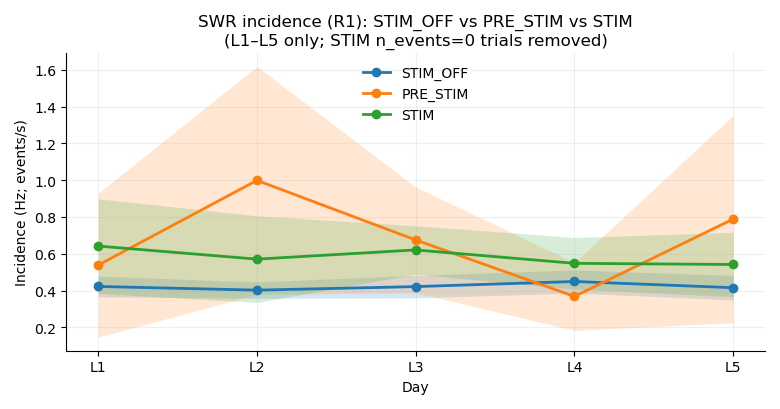


SWR mean duration (R1): STIM_OFF vs PRE_STIM vs STIM
(L1–L5 only; STIM n_events=0 trials removed)
Trials included per day (summed across animals):
  STIM_OFF: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  PRE_STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84


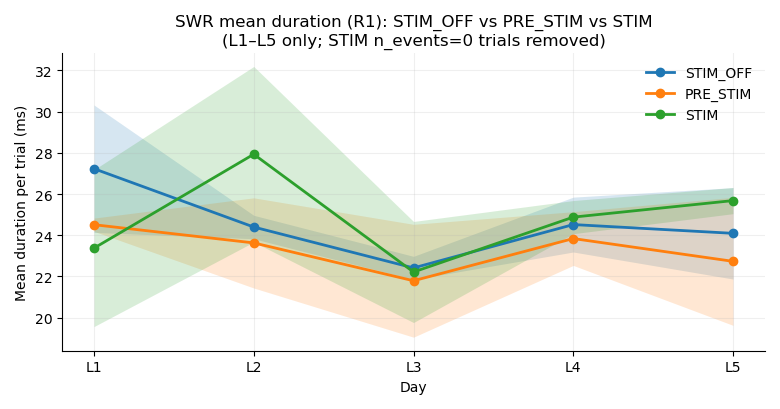


SWR peak frequency (R1): STIM_OFF vs PRE_STIM vs STIM
(L1–L5 only; STIM n_events=0 trials removed)
Trials included per day (summed across animals):
  STIM_OFF: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  PRE_STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84


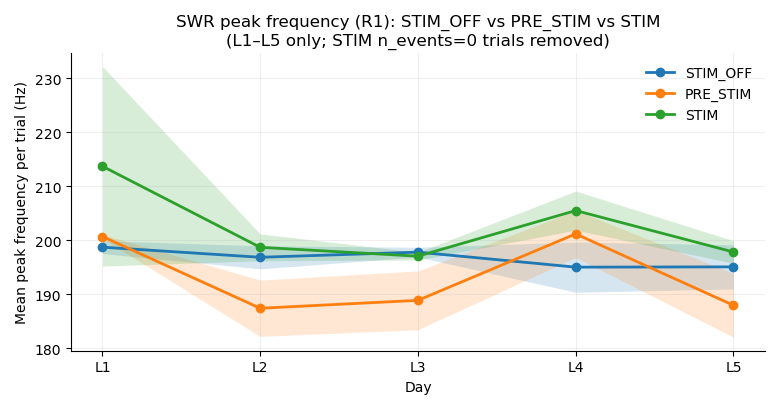

In [67]:
# ============================================================
# SWR day-by-day (R1 only) across 3 animals:
#   - Learning days only: trial_type == 'L' (L1..L5)
#   - Compare STIM vs STIM_OFF vs PRE_STIM
#   - REMOVE TRIALS where STIM has n_events == 0 (drop that trial across ALL conditions)
#   - For each plot: print number of trials included
#   - Plot SEM as pale shaded band (mean ± SEM)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- REQUIRE df_trial_metrics ----
if "df_trial_metrics" not in globals() or df_trial_metrics is None or len(df_trial_metrics) == 0:
    raise RuntimeError("df_trial_metrics not found / empty. Run your batch SWR metrics first (with PRE_STIM included).")

df = df_trial_metrics.copy()

# ----------------------------
# Basic normalization
# ----------------------------
def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size <= 1:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(x.size))

df["id"] = df["id"].astype(str).str.strip().str.upper()
df["trial_type"] = df["trial_type"].astype(str).str.strip().str.upper()
df["condition"] = df["condition"].astype(str).str.strip().str.upper()
df["channel"] = df["channel"].astype(str).str.strip().str.upper()

df["trial_id_num"] = _to_num(df.get("trial_id"))
df["ses_num"] = _to_num(df.get("ses"))

# Build an ordering key per animal/session:
if df["ses_num"].notna().any():
    df["order_key"] = df["ses_num"]
    ORDER_KEY_NAME = "ses_num"
else:
    if "date" not in df.columns:
        raise ValueError("No usable session ordering: need numeric 'ses' or a 'date' column.")
    df["order_key"] = pd.to_datetime(df["date"], errors="coerce")
    ORDER_KEY_NAME = "date"

# ----------------------------
# Filter to: R1, Learning only, STIM/STIM_OFF/PRE_STIM, valid trials 1..8
# ----------------------------
wanted_conds = ["STIM_OFF", "PRE_STIM", "STIM"]
df = df[
    (df["channel"] == "R1")
    & (df["trial_type"] == "L")                   # REMOVE TEST DAY here
    & (df["condition"].isin(wanted_conds))
    & (df["trial_id_num"].between(1, 8, inclusive="both"))
].copy()

if df.empty:
    raise RuntimeError(
        "After filtering to R1 + trial_type=='L' + trial_id 1..8 + conditions STIM_OFF/PRE_STIM/STIM, no rows remained.\n"
        "Check: trial_type labels, channel labels, condition labels, and that PRE_STIM exists in df_trial_metrics."
    )

# ----------------------------
# Build day labels: L1..L5 (per animal)
# ----------------------------
day_rows = []

for aid, dfa in df.groupby("id", sort=False):
    dfa = dfa.copy()
    dfa["day_label"] = pd.NA
    dfa["day_index"] = pd.NA

    # unique learning session keys in chronological order
    L_sess = (
        dfa[["order_key"]]
        .drop_duplicates()
        .sort_values("order_key")
        .reset_index(drop=True)
    )

    # first 5 learning days
    L_sess5 = L_sess.iloc[:5].copy()

    for i, ok in enumerate(L_sess5["order_key"].tolist(), start=1):
        m = (dfa["order_key"] == ok)
        dfa.loc[m, "day_label"] = f"L{i}"
        dfa.loc[m, "day_index"] = i

    dfa = dfa[dfa["day_label"].notna()].copy()
    day_rows.append(dfa)

df_use = pd.concat(day_rows, ignore_index=True) if len(day_rows) else pd.DataFrame()
if df_use.empty:
    raise RuntimeError(
        "No rows matched after labeling L1..L5. "
        "Check ses/date ordering and that you have learning sessions."
    )

df_use["day_index"] = pd.to_numeric(df_use["day_index"], errors="coerce")

# ----------------------------
# REQUIRED: drop trials where STIM has n_events == 0
#   trial key = (id, order_key, trial_id_num, trial_type)
# ----------------------------
if "n_events" not in df_use.columns:
    raise ValueError("df_trial_metrics must contain 'n_events' to apply the exclusion rule.")

stim_zero = df_use[
    (df_use["condition"] == "STIM") &
    (pd.to_numeric(df_use["n_events"], errors="coerce").fillna(0) == 0)
].copy()

trial_keys = ["id", "order_key", "trial_type", "trial_id_num"]
drop_keys = stim_zero[trial_keys].drop_duplicates()

before_n = len(df_use)
df_use = df_use.merge(drop_keys.assign(_drop=1), on=trial_keys, how="left")
df_use = df_use[df_use["_drop"].isna()].drop(columns=["_drop"])
after_n = len(df_use)

print(f"Dropped {before_n - after_n} rows total due to STIM n_events==0 rule "
      f"(trials dropped: {len(drop_keys)}).")

# ----------------------------
# Sanity check: trials per animal-day-condition AFTER dropping
# ----------------------------
trial_counts = (
    df_use.groupby(["id", "day_label", "condition"], dropna=False)
          .agg(n_trials=("trial_id_num", "nunique"))
          .reset_index()
          .sort_values(["id", "day_label", "condition"])
)
print("\nTrial counts per id/day/condition AFTER dropping (L-days may now be < 8):")
print(trial_counts.head(120))

# ----------------------------
# Verify required metrics exist
# ----------------------------
metrics = ["incidence_hz", "duration_mean_ms", "peak_freq_mean_hz"]
missing = [m for m in metrics if m not in df_use.columns]
if missing:
    raise ValueError(f"Missing expected metric columns in df_trial_metrics: {missing}")

# ----------------------------
# Aggregate per animal-day-condition (mean across remaining trials)
# ----------------------------
df_animal_day = (
    df_use.groupby(["id", "day_index", "day_label", "condition"], dropna=False)
          .agg(
              n_trials=("trial_id_num", "nunique"),
              incidence_hz_mean=("incidence_hz", "mean"),
              duration_mean_ms_mean=("duration_mean_ms", "mean"),
              peak_freq_mean_hz_mean=("peak_freq_mean_hz", "mean"),
          )
          .reset_index()
          .sort_values(["id", "day_index", "condition"])
)

# ----------------------------
# Group across animals: mean ± SEM for plotting
# each animal-day is one unit
# ----------------------------
df_group = (
    df_animal_day.groupby(["day_index", "day_label", "condition"], dropna=False)
        .agg(
            n_animal=("id", "nunique"),
            n_trials_mean=("n_trials", "mean"),
            n_trials_sum=("n_trials", "sum"),   # total trials contributing across animals

            incidence_hz=("incidence_hz_mean", "mean"),
            incidence_sem=("incidence_hz_mean", _sem),

            duration_ms=("duration_mean_ms_mean", "mean"),
            duration_sem=("duration_mean_ms_mean", _sem),

            peak_hz=("peak_freq_mean_hz_mean", "mean"),
            peak_sem=("peak_freq_mean_hz_mean", _sem),
        )
        .reset_index()
        .sort_values(["day_index", "condition"])
)

print(f"\nSession ordering key used: {ORDER_KEY_NAME}")
print("\nAnimal-day summary (R1) AFTER dropping STIM-zero trials:")
display(df_animal_day)

print("\nAcross-animals day summary (mean±SEM) AFTER dropping STIM-zero trials:")
display(df_group)

# ----------------------------
# Plot helper:
#   - shaded SEM band (mean ± SEM)
#   - print number of trials included per condition (per day + total)
# ----------------------------
def plot_day_comparison(df_group, ycol, yerr, title, ylabel):
    order = ["L1", "L2", "L3", "L4", "L5"]
    x_map = {lab: i for i, lab in enumerate(order, start=1)}

    fig, ax = plt.subplots(figsize=(7.8, 4.1))

    # PRINT trial counts used in THIS plot (from df_group n_trials_sum)
    print("\n" + "=" * 80)
    print(title)
    print("Trials included per day (summed across animals):")
    for cond in ["STIM_OFF", "PRE_STIM", "STIM"]:
        dcnt = df_group[df_group["condition"] == cond].copy()
        dcnt = dcnt[dcnt["day_label"].isin(order)].copy()
        dcnt = dcnt.sort_values("day_index")
        if dcnt.empty:
            print(f"  {cond}: (no data)")
            continue
        per_day = ", ".join([f"{dl}:{int(n)}" for dl, n in zip(dcnt["day_label"], dcnt["n_trials_sum"])])
        total = int(np.nansum(dcnt["n_trials_sum"].values))
        print(f"  {cond}: {per_day} | TOTAL={total}")

    # plot with shaded SEM
    for cond in ["STIM_OFF", "PRE_STIM", "STIM"]:
        d = df_group[df_group["condition"] == cond].copy()
        d = d[d["day_label"].isin(order)].copy()
        d["x"] = d["day_label"].map(x_map)
        d = d.dropna(subset=["x"]).sort_values("x")
        if d.empty:
            continue

        x = d["x"].values.astype(float)
        y = d[ycol].values.astype(float)
        se = d[yerr].values.astype(float)

        (ln,) = ax.plot(x, y, marker="o", linewidth=2, label=cond)
        # use the SAME color as the line, but pale
        ax.fill_between(x, y - se, y + se, alpha=0.18, color=ln.get_color(), linewidth=0)

    ax.set_xticks(list(x_map.values()))
    ax.set_xticklabels(order)
    ax.set_title(title)
    ax.set_xlabel("Day")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

# ----------------------------
# Make the 3 requested plots (Learning days only)
# ----------------------------
plot_day_comparison(
    df_group,
    ycol="incidence_hz",
    yerr="incidence_sem",
    title="SWR incidence (R1): STIM_OFF vs PRE_STIM vs STIM\n(L1–L5 only; STIM n_events=0 trials removed)",
    ylabel="Incidence (Hz; events/s)"
)

plot_day_comparison(
    df_group,
    ycol="duration_ms",
    yerr="duration_sem",
    title="SWR mean duration (R1): STIM_OFF vs PRE_STIM vs STIM\n(L1–L5 only; STIM n_events=0 trials removed)",
    ylabel="Mean duration per trial (ms)"
)

plot_day_comparison(
    df_group,
    ycol="peak_hz",
    yerr="peak_sem",
    title="SWR peak frequency (R1): STIM_OFF vs PRE_STIM vs STIM\n(L1–L5 only; STIM n_events=0 trials removed)",
    ylabel="Mean peak frequency per trial (Hz)"
)

In [56]:
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def events_to_mask(events, n):
    m = np.zeros(n, dtype=bool)
    if events is None or len(events) == 0:
        return m
    for s, e in np.asarray(events, dtype=int):
        s = max(0, s)
        e = min(n, e)
        if e > s:
            m[s:e] = True
    return m

def compare_swr_detections_viewer(
    lfp_data, fs, stim_trains,
    pair_right=(9, 15), pair_left=(25, 27),
    results=None,
    hemi="RIGHT",
    start_s=0.0, window_s=10.0,
    ttl_pad_s=1.0,
    ylim_raw=None, ylim_bp=None,
):
    assert results is not None, "Pass the `results` dict produced by your detection step."
    n = lfp_data.shape[0]

    ch1, ch2 = pair_right if hemi.upper() == "RIGHT" else pair_left
    x = np.asarray(lfp_data[:, ch1] - lfp_data[:, ch2], dtype=np.float32)

    j = results[hemi]["Jadhav"]
    k = results[hemi]["Kuga"]
    x_bp = j.get("bandpassed", k.get("bandpassed", np.zeros_like(x)))

    env, thr_j = j["env"], float(j["threshold"])
    rms, thr_k = k["rms"], float(k["threshold"])
    ev_j = np.asarray(j["events"]) if len(j["events"]) else np.empty((0, 2), dtype=int)
    ev_k = np.asarray(k["events"]) if len(k["events"]) else np.empty((0, 2), dtype=int)

    ttl_pad = int(round(ttl_pad_s * fs))
    ttl_spans = []
    for s, e in np.asarray(stim_trains, dtype=int):
        s0 = max(0, int(s) - ttl_pad)
        e0 = min(n, int(e) + ttl_pad)
        ttl_spans.append((s0, e0))

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    plt.subplots_adjust(bottom=0.14, hspace=0.25)

    ax_sl = fig.add_axes([0.12, 0.05, 0.76, 0.035])
    max_start = max(0.0, (n / fs) - window_s)
    sld = Slider(ax_sl, "Start (s)", 0.0, max_start, valinit=start_s)

    def shade_ttl(ax, i0, i1):
        for s0, e0 in ttl_spans:
            if e0 <= i0 or s0 >= i1:
                continue
            ax.axvspan(max(s0, i0) / fs, min(e0, i1) / fs, alpha=0.08)

    def shade_events(ax, i0, i1, events, label, alpha=0.15):
        first = True
        for s, e in events:
            if e <= i0 or s >= i1:
                continue
            ax.axvspan(max(s, i0) / fs, min(e, i1) / fs, alpha=alpha, label=(label if first else None))
            first = False

    def render(s0):
        i0 = int(s0 * fs)
        i1 = min(int((s0 + window_s) * fs), n)
        t = np.arange(i0, i1) / fs

        for ax in axes:
            ax.clear()

        axes[0].plot(t, x[i0:i1], lw=0.7)
        shade_ttl(axes[0], i0, i1)
        axes[0].set_ylabel("Bipolar (a.u.)")
        axes[0].set_title(f"{hemi} bipolar ch{ch1}-ch{ch2} | window={window_s}s")
        if ylim_raw is not None:
            axes[0].set_ylim(*ylim_raw)
        axes[0].grid(True, alpha=0.2)

        axes[1].plot(t, x_bp[i0:i1], lw=0.7)
        shade_ttl(axes[1], i0, i1)
        axes[1].set_ylabel("150-250 Hz")
        if ylim_bp is not None:
            axes[1].set_ylim(*ylim_bp)
        axes[1].grid(True, alpha=0.2)

        axes[2].plot(t, env[i0:i1], lw=0.8)
        axes[2].axhline(thr_j, ls="--", lw=0.8)
        shade_events(axes[2], i0, i1, ev_j, "Jadhav events", alpha=0.18)
        shade_ttl(axes[2], i0, i1)
        axes[2].set_ylabel("Env (J)")
        axes[2].grid(True, alpha=0.2)
        axes[2].legend(loc="upper right")

        axes[3].plot(t, rms[i0:i1], lw=0.8)
        axes[3].axhline(thr_k, ls="--", lw=0.8)
        shade_events(axes[3], i0, i1, ev_k, "Kuga events", alpha=0.18)
        shade_ttl(axes[3], i0, i1)
        axes[3].set_ylabel("RMS (K)")
        axes[3].set_xlabel("Time (s)")
        axes[3].grid(True, alpha=0.2)
        axes[3].legend(loc="upper right")

        axes[3].set_xlim(s0, s0 + window_s)
        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(start_s)
    plt.show()

lfp_view = np.asarray(globals().get("lfp_raw", globals().get("lfp_ds")), dtype=np.float32)
fs_view = float(globals().get("fs", globals().get("fs_ds", 2000.0)))
trains_view = np.asarray(globals().get("stim_trains_raw", globals().get("pulses_ds", np.zeros((0, 2), dtype=np.int64))), dtype=np.int64)

compare_swr_detections_viewer(
    lfp_view, fs_view, trains_view,
    pair_right=(9, 15), pair_left=(25, 27),
    results=results, hemi="RIGHT", start_s=0.0, window_s=10.0, ttl_pad_s=1.0,
)

compare_swr_detections_viewer(
    lfp_view, fs_view, trains_view,
    pair_right=(9, 15), pair_left=(25, 27),
    results=results, hemi="LEFT", start_s=0.0, window_s=10.0, ttl_pad_s=1.0,
)



NameError: name 'results' is not defined

In [59]:
# ============================================================
# Average SWR incidence by day (learning trials, STIM only),
# per animal and channel R1-R4, using trial_id 1..8.
# Highlight highest-incidence channel for each animal-day.
# ============================================================

import numpy as np
import pandas as pd

# ---- REQUIRE df_trial_metrics ----
if "df_trial_metrics" not in globals() or df_trial_metrics is None:
    raise RuntimeError("df_trial_metrics not found. Run the batch Jadhav metrics code first.")

dfi = df_trial_metrics.copy()

# ----------------------------
# Helpers
# ----------------------------
def _to_num(x):
    return pd.to_numeric(x, errors="coerce")

def _is_learning(df):
    # Prefer explicit boolean if you already made it
    if "is_learning" in df.columns:
        return df["is_learning"].fillna(False).astype(bool)
    # Otherwise, use trial_type == L
    if "trial_type" in df.columns:
        return df["trial_type"].astype(str).str.upper().eq("L")
    if "trial_type_day" in df.columns:
        return df["trial_type_day"].astype(str).str.upper().eq("L")
    raise ValueError("No learning indicator found. Need is_learning or trial_type/trial_type_day.")

def _find_day_key(df):
    # Your “day” can be session index or date
    for k in ["ses", "session", "day", "date"]:
        if k in df.columns:
            return k
    raise ValueError("No day/session column found. Expected one of: ses/session/day/date.")

def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size <= 1:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(x.size))

# ----------------------------
# Normalize / filter rows
# ----------------------------
dfi["trial_id_num"] = _to_num(dfi.get("trial_id"))

day_key = _find_day_key(dfi)

# Learning + STIM + R1-R4 + trial_id 1..8
dfi = dfi[
    _is_learning(dfi)
    & (dfi["condition"].astype(str).str.upper() == "STIM")
    & (dfi["channel"].isin(["R1"]))
    & (dfi["trial_id_num"].between(1, 8, inclusive="both"))
].copy()

# ----------------------------
# Aggregate: animal x day x channel
# ----------------------------
group_cols = ["id", day_key, "channel"]
if "trial_type_day" in dfi.columns:
    group_cols.insert(2, "trial_type_day")  # keep this if you use it

df_day_inc = (
    dfi.groupby(group_cols, dropna=False)
      .agg(
          n_trials=("trial_id_num", "nunique"),
          avg_incidence_hz=("incidence_hz", "mean"),
          sem_incidence_hz=("incidence_hz", _sem),
      )
      .reset_index()
      .sort_values(group_cols)
)

# Option A: enforce exactly 8 trials per day (recommended for your design)
df_day_inc_8 = df_day_inc[df_day_inc["n_trials"] == 8].copy()

# Use strict if it exists, else fallback
df_day_use = df_day_inc_8 if len(df_day_inc_8) else df_day_inc.copy()

# ----------------------------
# Highlight highest channel per animal-day
# ----------------------------
max_group = ["id", day_key]
if "trial_type_day" in df_day_use.columns:
    max_group.insert(2, "trial_type_day")

df_day_use["highest_incidence_hz_day"] = df_day_use.groupby(max_group)["avg_incidence_hz"].transform("max")
df_day_use["is_highest_channel"] = df_day_use["avg_incidence_hz"].eq(df_day_use["highest_incidence_hz_day"])

# ----------------------------
# Wide view: one row per animal-day, columns R1..R4
# ----------------------------
pivot_index = ["id", day_key]
if "trial_type_day" in df_day_use.columns:
    pivot_index.append("trial_type_day")

pivot_inc = (
    df_day_use.pivot_table(
        index=pivot_index,
        columns="channel",
        values="avg_incidence_hz",
        aggfunc="mean"
    )
    .reset_index()
    .sort_values(pivot_index)
)

chan_cols = [c for c in ["R1", "R2", "R3", "R4"] if c in pivot_inc.columns]
if chan_cols:
    pivot_inc["highest_channel"] = pivot_inc[chan_cols].idxmax(axis=1)
    pivot_inc["highest_incidence_hz"] = pivot_inc[chan_cols].max(axis=1)

print(f"Day key used: {day_key}")
print("Rows used:", len(df_day_use), "| strict 8-trial rows:", len(df_day_inc_8))

display(df_day_use)   # long format with highlight flag
display(pivot_inc)    # wide format with highest channel per day

# (Optional) UI tables if available
try:
    from caas_jupyter_tools import display_dataframe_to_user
    display_dataframe_to_user("SWR incidence by day/channel (STIM, learning) — long", df_day_use)
    display_dataframe_to_user("SWR incidence by day (R1–R4) — wide", pivot_inc)
except Exception:
    pass

Day key used: ses
Rows used: 12 | strict 8-trial rows: 12


,id,ses,trial_type_day,channel,n_trials,avg_incidence_hz,sem_incidence_hz,highest_incidence_hz_day,is_highest_channel
0,AM,4,1,R1,8,0.024519,0.024519,0.024519,True
1,AM,5,2,R1,8,0.314443,0.097209,0.314443,True
2,AM,6,3,R1,8,0.454811,0.054136,0.454811,True
3,AM,7,4,R1,8,0.276616,0.252203,0.276616,True
6,AN,30,2,R1,8,0.854509,0.150540,0.854509,True
7,AN,31,3,R1,8,0.820577,0.108961,0.820577,True
9,AN,33,5,R1,8,0.701508,0.100686,0.701508,True
10,AO,29,1,R1,8,0.561433,0.294240,0.561433,True
11,AO,30,2,R1,8,0.053953,0.042170,0.053953,True
12,AO,31,3,R1,8,0.585957,0.065499,0.585957,True


channel,id,ses,trial_type_day,R1,highest_channel,highest_incidence_hz
0,AM,4,1,0.024519,R1,0.024519
1,AM,5,2,0.314443,R1,0.314443
2,AM,6,3,0.454811,R1,0.454811
3,AM,7,4,0.276616,R1,0.276616
4,AN,30,2,0.854509,R1,0.854509
5,AN,31,3,0.820577,R1,0.820577
6,AN,33,5,0.701508,R1,0.701508
7,AO,29,1,0.561433,R1,0.561433
8,AO,30,2,0.053953,R1,0.053953
9,AO,31,3,0.585957,R1,0.585957


1) User data inputs + helper functions

In [237]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks, peak_widths


# ============================================================
# 1) USER DATA INPUTS
# ============================================================
ALIGNED_NPY_PATH = Path(
    "/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/"
    "sub-018_id-AO/ses-33_date-20250924/ephys/sub-018_ses-33_trial-14_ephys/"
    "sub-018_ses-33_trial-14_ephys_aligned.npy"
)

CHANNEL_CSV_PATH = Path(
    "/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/channel.csv"
)
CHANNEL_NAMES = ["R1", "R2", "R3", "R4"]

# ----------------------------
# Wavelet parameters
# ----------------------------
WAVELET_W = 10.0
RIPPLE_FREQ_MIN = 120.0
RIPPLE_FREQ_MAX = 250.0
N_FREQS = 80

# ----------------------------
# Baseline option for thresholding
# True  = use STIM_OFF only (non-stim, artifact removed)
# False = use whole trace with artifact removed
# ----------------------------
BASELINE_USE_STIM_OFF_ONLY = False

# ----------------------------
# Detection parameters
# ----------------------------
THR_SD = 3.0
MIN_DURATION_MS = 20.0
PEAK_REL_HEIGHT = 0.7
PEAK_PROMINENCE_SD = 1.0

# ----------------------------
# Stim train parameters
# ----------------------------
STIM_GAP_S = 1.0
STIM_PRE_S = 0.0
STIM_POST_S = 0.0

# ----------------------------
# Mask window parameters
# ----------------------------
INCLUDE_PRE_STIM = True
PRE_STIM_SECONDS = 8.0

INCLUDE_POST_STIM = True
POST_STIM_SECONDS = 8.0

INCLUDE_NEAR_STIM = True
NEAR_STIM_SECONDS = 8.0

# ----------------------------
# Artifact parameters
# ----------------------------
ARTIFACT_REMOVE_FIRST_S = 1.0
ARTIFACT_RAW_AMP_K = 10.0

# ----------------------------
# Plotting
# ----------------------------
MAKE_PLOTS = True
PLOT_WINDOW_S = 20.0


# ============================================================
# HELPERS
# ============================================================
def _load_channel_map_by_id(channel_csv_path: Path):
    if not channel_csv_path.is_file():
        raise FileNotFoundError(f"channel csv not found: {channel_csv_path}")

    chdf = pd.read_csv(channel_csv_path).copy()
    req = {"id", *CHANNEL_NAMES}
    miss = req - set(chdf.columns)
    if miss:
        raise ValueError(f"channel csv missing columns: {sorted(miss)}")

    chdf["id"] = chdf["id"].astype(str).str.strip().str.upper()
    for c in CHANNEL_NAMES:
        chdf[c] = pd.to_numeric(chdf[c], errors="coerce")

    by_id = {}
    for _, rr in chdf.iterrows():
        aid = rr["id"]
        mp = {}
        for c in CHANNEL_NAMES:
            v = rr[c]
            if pd.notna(v):
                mp[c] = int(v)
        if aid and mp:
            by_id[aid] = mp
    return by_id


def _infer_alignment_json_path(aligned_npy_path: Path):
    aligned_npy_path = Path(aligned_npy_path)
    if not aligned_npy_path.is_file():
        raise FileNotFoundError(f"aligned npy not found: {aligned_npy_path}")

    out_dir = aligned_npy_path.parent
    stem = aligned_npy_path.name.replace("_aligned.npy", "")
    json_path = out_dir / f"{stem}_alignment.json"
    if json_path.is_file():
        return json_path

    cands = sorted(out_dir.glob("*_alignment.json"))
    if not cands:
        raise FileNotFoundError(f"No alignment json found in {out_dir}")
    return cands[0]


def _extract_id_from_path(path_obj: Path):
    for p in path_obj.parts:
        if "_id-" in p:
            return p.split("_id-")[-1].upper()
    raise ValueError(f"Could not infer animal id from path: {path_obj}")


def _extract_ttl_pulses_raw(sample_numbers, states):
    sample_numbers = np.asarray(sample_numbers)
    states = np.asarray(states)

    start_idx = np.where(states == 1)[0]
    end_idx = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    if n == 0:
        return np.zeros((0, 2), dtype=np.int64)

    pulses = np.stack(
        [sample_numbers[start_idx[:n]], sample_numbers[end_idx[:n]]],
        axis=1
    )
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    return pulses.astype(np.int64)


def _load_ttl_as_raw_lfp_indices(ttl_folder: Path, cont_folder: Path):
    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states = np.load(ttl_folder / "states.npy")
    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    pulses_raw = _extract_ttl_pulses_raw(stim_samp, states)
    if pulses_raw.size == 0:
        return np.zeros((0, 2), dtype=np.int64)

    pulses_idx = (pulses_raw - cont0).astype(np.int64)
    pulses_idx = pulses_idx[pulses_idx[:, 1] > pulses_idx[:, 0]]
    pulses_idx = pulses_idx[pulses_idx[:, 1] > 0]
    return pulses_idx


def _load_shifted_ttl_on_aligned_axis(info: dict, fs_align: float, n_aligned: int):
    continuous_dat = Path(info["continuous_dat"])
    rec_dir = continuous_dat.parents[2]
    cont_folder = continuous_dat.parent
    ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"

    ttl_ok = (
        (ttl_folder / "sample_numbers.npy").is_file()
        and (ttl_folder / "states.npy").is_file()
        and (cont_folder / "sample_numbers.npy").is_file()
    )
    if not ttl_ok:
        return np.zeros((0, 2), dtype=np.int64), pd.DataFrame(), {
            "ttl_ok": False,
            "ttl_folder": str(ttl_folder),
            "cont_folder": str(cont_folder),
        }

    fs_raw = float(info.get("fs_raw") or 2000.0)
    trim_s = float(info.get("trim_start_s") or 0.0)
    pad_s = float(info.get("pad_start_s") or 0.0)
    ttl_shift_s = float(info.get("ttl_time_shift_s", pad_s - trim_s))

    pulses_idx_raw = _load_ttl_as_raw_lfp_indices(ttl_folder, cont_folder)
    if pulses_idx_raw.size == 0:
        return np.zeros((0, 2), dtype=np.int64), pd.DataFrame(), {
            "ttl_ok": True,
            "n_pulses": 0,
            "ttl_shift_s": ttl_shift_s,
        }

    starts_s_aligned = (pulses_idx_raw[:, 0] / fs_raw) + ttl_shift_s
    ends_s_aligned = (pulses_idx_raw[:, 1] / fs_raw) + ttl_shift_s

    starts_idx_aligned = np.floor(starts_s_aligned * fs_align).astype(np.int64)
    ends_idx_aligned = np.ceil(ends_s_aligned * fs_align).astype(np.int64)

    pulses_aligned = np.stack([starts_idx_aligned, ends_idx_aligned], axis=1)
    pulses_aligned[:, 0] = np.clip(pulses_aligned[:, 0], 0, n_aligned)
    pulses_aligned[:, 1] = np.clip(pulses_aligned[:, 1], 0, n_aligned)
    pulses_aligned = pulses_aligned[pulses_aligned[:, 1] > pulses_aligned[:, 0]]

    pulses_table = pd.DataFrame({
        "start_idx_aligned": pulses_aligned[:, 0] if len(pulses_aligned) else [],
        "end_idx_aligned": pulses_aligned[:, 1] if len(pulses_aligned) else [],
        "start_s_aligned": pulses_aligned[:, 0] / fs_align if len(pulses_aligned) else [],
        "end_s_aligned": pulses_aligned[:, 1] / fs_align if len(pulses_aligned) else [],
    })
    if len(pulses_table):
        pulses_table["duration_s"] = pulses_table["end_s_aligned"] - pulses_table["start_s_aligned"]

    return pulses_aligned, pulses_table, {
        "ttl_ok": True,
        "n_pulses": int(len(pulses_aligned)),
        "ttl_shift_s": ttl_shift_s,
    }


def build_stim_mask_from_trains(
    n_samples: int,
    pulses_ds: np.ndarray,
    fs: float,
    gap_s: float = 1.0,
    pre_s: float = 0.0,
    post_s: float = 0.0,
):
    stim_mask = np.zeros(n_samples, dtype=bool)

    if pulses_ds is None or len(pulses_ds) == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    pulses = np.asarray(pulses_ds, dtype=np.int64).copy()
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    if pulses.size == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    order = np.argsort(pulses[:, 0])
    pulses = pulses[order]

    starts = pulses[:, 0]
    ends = pulses[:, 1]

    gap = int(round(gap_s * fs))
    pre = int(round(pre_s * fs))
    post = int(round(post_s * fs))

    trains = []
    cur_start = int(starts[0])
    cur_end = int(ends[0])

    for i in range(1, len(pulses)):
        if (int(starts[i]) - int(starts[i - 1])) > gap:
            trains.append((cur_start, cur_end))
            cur_start = int(starts[i])
            cur_end = int(ends[i])
        else:
            cur_end = max(cur_end, int(ends[i]))

    trains.append((cur_start, cur_end))

    trains_ds = []
    for s, e in trains:
        s0 = max(0, s - pre)
        e0 = min(n_samples, e + post)
        if e0 > s0:
            stim_mask[s0:e0] = True
            trains_ds.append((s0, e0))

    trains_ds = np.asarray(trains_ds, dtype=np.int64)

    trains_table = pd.DataFrame({
        "train_idx": np.arange(len(trains_ds)),
        "start_s": trains_ds[:, 0] / fs if len(trains_ds) else [],
        "end_s": trains_ds[:, 1] / fs if len(trains_ds) else [],
    })
    if len(trains_table):
        trains_table["duration_s"] = trains_table["end_s"] - trains_table["start_s"]

    return stim_mask, trains_ds, trains_table


def _intervals_to_mask(n_samples: int, intervals, fs: float):
    mask = np.zeros(n_samples, dtype=bool)
    rows = []

    for s, e in intervals:
        s = int(max(0, min(n_samples, s)))
        e = int(max(0, min(n_samples, e)))
        if e > s:
            mask[s:e] = True
            rows.append((s, e))

    arr = np.asarray(rows, dtype=np.int64) if len(rows) else np.zeros((0, 2), dtype=np.int64)
    table = pd.DataFrame({
        "interval_idx": np.arange(len(arr)),
        "start_s": arr[:, 0] / fs if len(arr) else [],
        "end_s": arr[:, 1] / fs if len(arr) else [],
    })
    if len(table):
        table["duration_s"] = table["end_s"] - table["start_s"]
    return mask, arr, table


def build_pre_post_near_stim_masks(
    n_samples: int,
    stim_trains_ds: np.ndarray,
    fs: float,
    pre_window_s: float = 8.0,
    post_window_s: float = 8.0,
    near_window_s: float = 8.0,
):
    """
    PRE_STIM, POST_STIM and NEAR_STIM are built independently.

    PRE_STIM:
      up to pre_window_s before each stim train

    POST_STIM:
      up to post_window_s after each stim train

    NEAR_STIM:
      near_window_s before each stim train + near_window_s after each stim train,
      merged by boolean mask so overlaps count only once

    All masks exclude actual stim samples.
    """
    empty_arr = np.zeros((0, 2), dtype=np.int64)
    empty_table = pd.DataFrame(columns=["interval_idx", "start_s", "end_s", "duration_s"])

    pre_mask = np.zeros(n_samples, dtype=bool)
    post_mask = np.zeros(n_samples, dtype=bool)
    near_mask = np.zeros(n_samples, dtype=bool)

    if stim_trains_ds is None or len(stim_trains_ds) == 0:
        return {
            "pre_mask": pre_mask,
            "post_mask": post_mask,
            "near_mask": near_mask,
            "pre_intervals": empty_arr,
            "post_intervals": empty_arr,
            "near_intervals": empty_arr,
            "pre_table": empty_table.copy(),
            "post_table": empty_table.copy(),
            "near_table": empty_table.copy(),
        }

    trains = np.asarray(stim_trains_ds, dtype=np.int64)
    trains = trains[trains[:, 1] > trains[:, 0]]
    if trains.size == 0:
        return {
            "pre_mask": pre_mask,
            "post_mask": post_mask,
            "near_mask": near_mask,
            "pre_intervals": empty_arr,
            "post_intervals": empty_arr,
            "near_intervals": empty_arr,
            "pre_table": empty_table.copy(),
            "post_table": empty_table.copy(),
            "near_table": empty_table.copy(),
        }

    pre_len = int(round(float(pre_window_s) * fs))
    post_len = int(round(float(post_window_s) * fs))
    near_len = int(round(float(near_window_s) * fs))

    pre_intervals = []
    post_intervals = []
    near_intervals = []

    for s, e in trains:
        if pre_len > 0:
            pre_intervals.append((max(0, s - pre_len), s))
        if post_len > 0:
            post_intervals.append((e, min(n_samples, e + post_len)))
        if near_len > 0:
            near_intervals.append((max(0, s - near_len), s))
            near_intervals.append((e, min(n_samples, e + near_len)))

    pre_mask, pre_arr, pre_table = _intervals_to_mask(n_samples, pre_intervals, fs)
    post_mask, post_arr, post_table = _intervals_to_mask(n_samples, post_intervals, fs)
    near_mask, near_arr, near_table = _intervals_to_mask(n_samples, near_intervals, fs)

    stim_exact_mask, _, _ = _intervals_to_mask(n_samples, trains.tolist(), fs)
    pre_mask = pre_mask & (~stim_exact_mask)
    post_mask = post_mask & (~stim_exact_mask)
    near_mask = near_mask & (~stim_exact_mask)

    return {
        "pre_mask": pre_mask,
        "post_mask": post_mask,
        "near_mask": near_mask,
        "pre_intervals": pre_arr,
        "post_intervals": post_arr,
        "near_intervals": near_arr,
        "pre_table": pre_table,
        "post_table": post_table,
        "near_table": near_table,
    }


def build_artifact_mask(
    x,
    fs,
    remove_first_s=1.0,
    raw_amp_k=10.0,
):
    x = np.asarray(x, dtype=np.float32)
    n = x.size
    valid = np.isfinite(x)

    artifact_mask = np.zeros(n, dtype=bool)

    n_first = int(round(float(remove_first_s) * float(fs)))
    n_first = max(0, min(n_first, n))
    if n_first > 0:
        artifact_mask[:n_first] = True

    x_valid = x[valid]
    if x_valid.size > 0:
        med = float(np.nanmedian(x_valid))
        mad = float(np.nanmedian(np.abs(x_valid - med)))
        robust_sd = 1.4826 * mad if mad > 0 else np.nan

        if np.isfinite(robust_sd) and robust_sd > 0:
            amp_mask = np.abs(x - med) > (float(raw_amp_k) * robust_sd)
            amp_mask = np.asarray(amp_mask, dtype=bool) & valid
            artifact_mask |= amp_mask
        else:
            amp_mask = np.zeros(n, dtype=bool)
    else:
        med = np.nan
        mad = np.nan
        robust_sd = np.nan
        amp_mask = np.zeros(n, dtype=bool)

    info = {
        "remove_first_s": float(remove_first_s),
        "n_first_samples": int(n_first),
        "raw_amp_k": float(raw_amp_k),
        "median": med,
        "mad": mad,
        "robust_sd": robust_sd,
        "n_artifact_samples_total": int(artifact_mask.sum()),
        "n_artifact_samples_amp_only": int(amp_mask.sum()),
    }
    return artifact_mask, info


def _build_wavelet_freqs_and_widths(fs, fmin=120.0, fmax=200.0, n_freqs=80, w=10.0):
    freq = np.linspace(fmin, fmax, n_freqs)
    widths = w * fs / (2 * np.pi * freq)
    return freq, widths

2. creating masks

In [187]:
# ============================================================
# 2) LOAD DATA + CREATE MASKS
# ============================================================
json_path = _infer_alignment_json_path(ALIGNED_NPY_PATH)
info = json.loads(json_path.read_text())

lfp_aligned = np.load(ALIGNED_NPY_PATH, mmap_mode="r")
lfp_aligned = np.asarray(lfp_aligned, dtype=np.float32)

fs = float(info.get("fs_align") or info.get("fs_ds") or 1000.0)
animal_id = _extract_id_from_path(ALIGNED_NPY_PATH)
n_aligned = lfp_aligned.shape[0]

print("Aligned file:", ALIGNED_NPY_PATH)
print("Alignment json:", json_path)
print("Animal ID:", animal_id)
print("Aligned LFP shape:", lfp_aligned.shape)
print("fs:", fs)

CHANNEL_MAP_BY_ID = _load_channel_map_by_id(CHANNEL_CSV_PATH)
channel_map = CHANNEL_MAP_BY_ID[animal_id]
print("Channel map:", channel_map)

pulses_aligned, pulses_table, ttl_meta = _load_shifted_ttl_on_aligned_axis(
    info=info,
    fs_align=fs,
    n_aligned=n_aligned,
)

stim_mask, stim_trains_ds, stim_trains_table = build_stim_mask_from_trains(
    n_samples=n_aligned,
    pulses_ds=pulses_aligned,
    fs=fs,
    gap_s=STIM_GAP_S,
    pre_s=STIM_PRE_S,
    post_s=STIM_POST_S,
)

mask_info = build_pre_post_near_stim_masks(
    n_samples=n_aligned,
    stim_trains_ds=stim_trains_ds,
    fs=fs,
    pre_window_s=PRE_STIM_SECONDS,
    post_window_s=POST_STIM_SECONDS,
    near_window_s=NEAR_STIM_SECONDS,
)

pre_stim_mask = mask_info["pre_mask"] if INCLUDE_PRE_STIM else np.zeros(n_aligned, dtype=bool)
post_stim_mask = mask_info["post_mask"] if INCLUDE_POST_STIM else np.zeros(n_aligned, dtype=bool)
near_stim_mask = mask_info["near_mask"] if INCLUDE_NEAR_STIM else np.zeros(n_aligned, dtype=bool)

pre_stim_table = mask_info["pre_table"]
post_stim_table = mask_info["post_table"]
near_stim_table = mask_info["near_table"]

# non-stim only; artifact exclusion is applied later channel-by-channel
stim_off_mask_nominal = ~stim_mask

print("\nTTL / MASK INFO")
print("ttl_meta:", ttl_meta)
print("n shifted TTL pulses:", len(pulses_aligned))
print("n stim trains:", len(stim_trains_ds))
print("stim samples:", int(stim_mask.sum()), "(", stim_mask.sum() / fs, "s )")
print("pre-stim samples:", int(pre_stim_mask.sum()), "(", pre_stim_mask.sum() / fs, "s )")
print("post-stim samples:", int(post_stim_mask.sum()), "(", post_stim_mask.sum() / fs, "s )")
print("near-stim samples:", int(near_stim_mask.sum()), "(", near_stim_mask.sum() / fs, "s )")
print("stim-off samples (ignoring artifacts for now):", int(stim_off_mask_nominal.sum()), "(", stim_off_mask_nominal.sum() / fs, "s )")
print("Baseline mode:", "STIM_OFF only" if BASELINE_USE_STIM_OFF_ONLY else "whole trace (artifact removed)")

display(stim_trains_table)
display(pre_stim_table)
display(post_stim_table)
display(near_stim_table)


Aligned file: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-33_date-20250924/ephys/sub-018_ses-33_trial-14_ephys/sub-018_ses-33_trial-14_ephys_aligned.npy
Alignment json: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-018_id-AO/ses-33_date-20250924/ephys/sub-018_ses-33_trial-14_ephys/sub-018_ses-33_trial-14_ephys_alignment.json
Animal ID: AO
Aligned LFP shape: (407751, 35)
fs: 2000.0
Channel map: {'R1': 10, 'R2': 12, 'R3': 14, 'R4': 16}

TTL / MASK INFO
ttl_meta: {'ttl_ok': True, 'n_pulses': 495, 'ttl_shift_s': -1.948500000000001}
n shifted TTL pulses: 495
n stim trains: 11
stim samples: 192300 ( 96.15 s )
pre-stim samples: 111201 ( 55.6005 s )
post-stim samples: 98236 ( 49.118 s )
near-stim samples: 162236 ( 81.118 s )
stim-off samples (ignoring artifacts for now): 215451 ( 107.7255 s )
Baseline mode: whole trace (artifact removed)


,train_idx,start_s,end_s,duration_s
0,0,12.0170,23.9465,11.9295
1,1,30.6710,30.8805,0.2095
2,2,32.8155,42.6065,9.7910
3,3,70.9310,71.1400,0.2090
4,4,73.0665,78.6215,5.5550
5,5,80.0000,84.4715,4.4715
6,6,101.3320,101.5425,0.2105
7,7,104.5330,133.5360,29.0030
8,8,138.1270,138.3360,0.2090
9,9,163.7415,187.4180,23.6765


,interval_idx,start_s,end_s,duration_s
0,0,4.0170,12.0170,8.0
1,1,22.6710,30.6710,8.0
2,2,24.8155,32.8155,8.0
3,3,62.9310,70.9310,8.0
4,4,65.0665,73.0665,8.0
5,5,72.0000,80.0000,8.0
6,6,93.3320,101.3320,8.0
7,7,96.5330,104.5330,8.0
8,8,130.1270,138.1270,8.0
9,9,155.7415,163.7415,8.0


,interval_idx,start_s,end_s,duration_s
0,0,23.9465,31.9465,8.0000
1,1,30.8805,38.8805,8.0000
2,2,42.6065,50.6065,8.0000
3,3,71.1400,79.1400,8.0000
4,4,78.6215,86.6215,8.0000
5,5,84.4715,92.4715,8.0000
6,6,101.5425,109.5425,8.0000
7,7,133.5360,141.5360,8.0000
8,8,138.3360,146.3360,8.0000
9,9,187.4180,195.4180,8.0000


,interval_idx,start_s,end_s,duration_s
0,0,4.0170,12.0170,8.0000
1,1,23.9465,31.9465,8.0000
2,2,22.6710,30.6710,8.0000
3,3,30.8805,38.8805,8.0000
4,4,24.8155,32.8155,8.0000
5,5,42.6065,50.6065,8.0000
6,6,62.9310,70.9310,8.0000
7,7,71.1400,79.1400,8.0000
8,8,65.0665,73.0665,8.0000
9,9,78.6215,86.6215,8.0000


3) wavelet analysis


Running wavelet SWR detection for R1 (index 10)


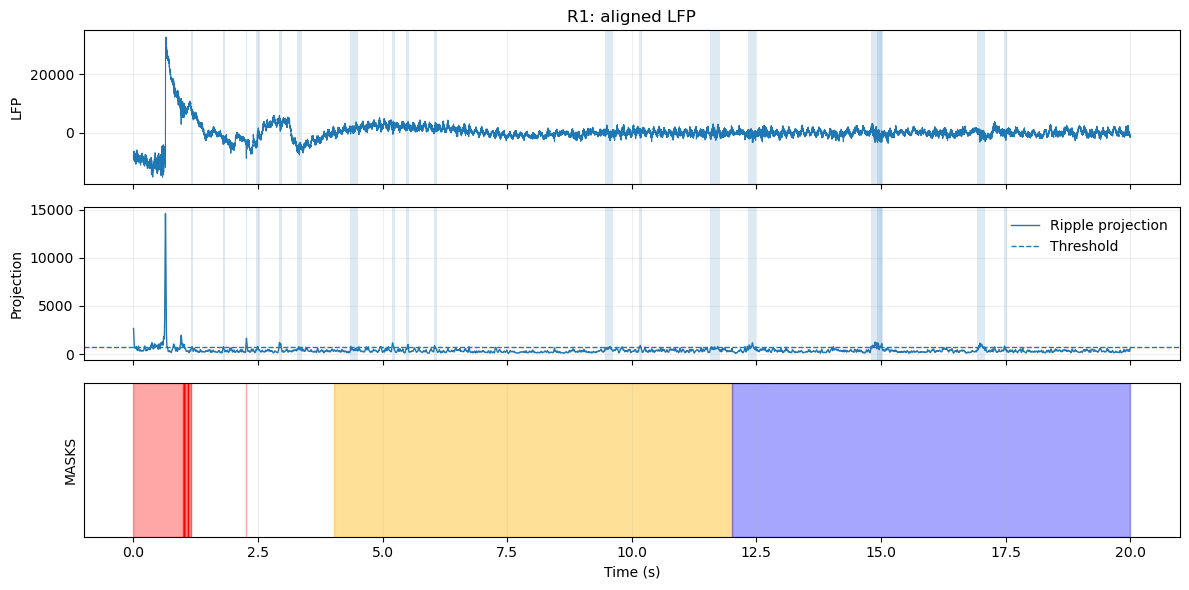


Running wavelet SWR detection for R2 (index 12)


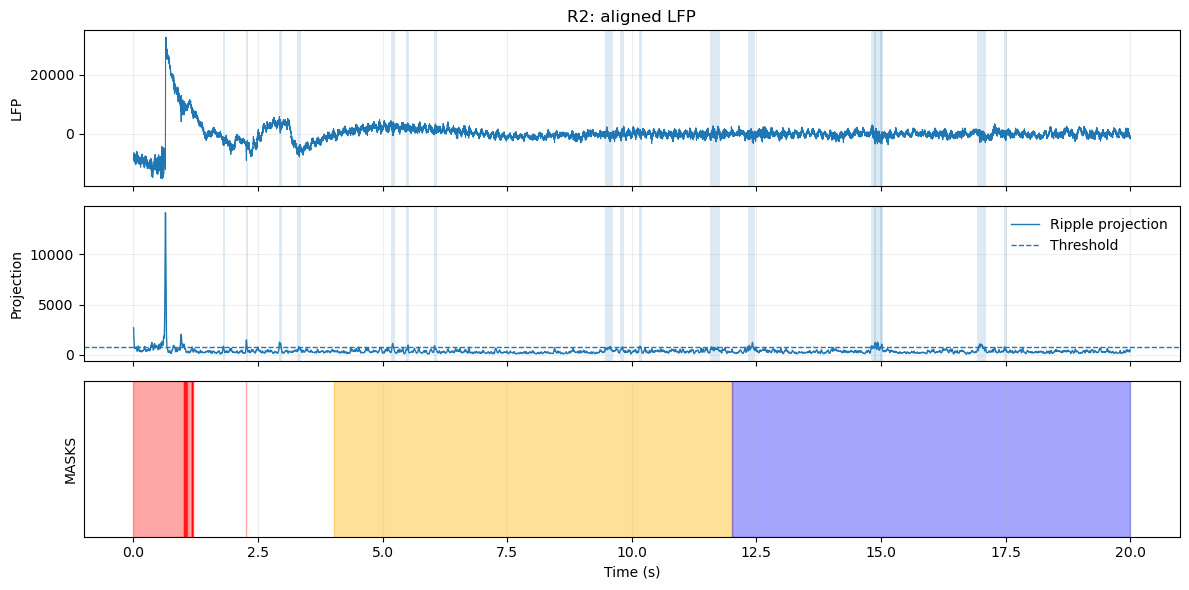


Running wavelet SWR detection for R3 (index 14)


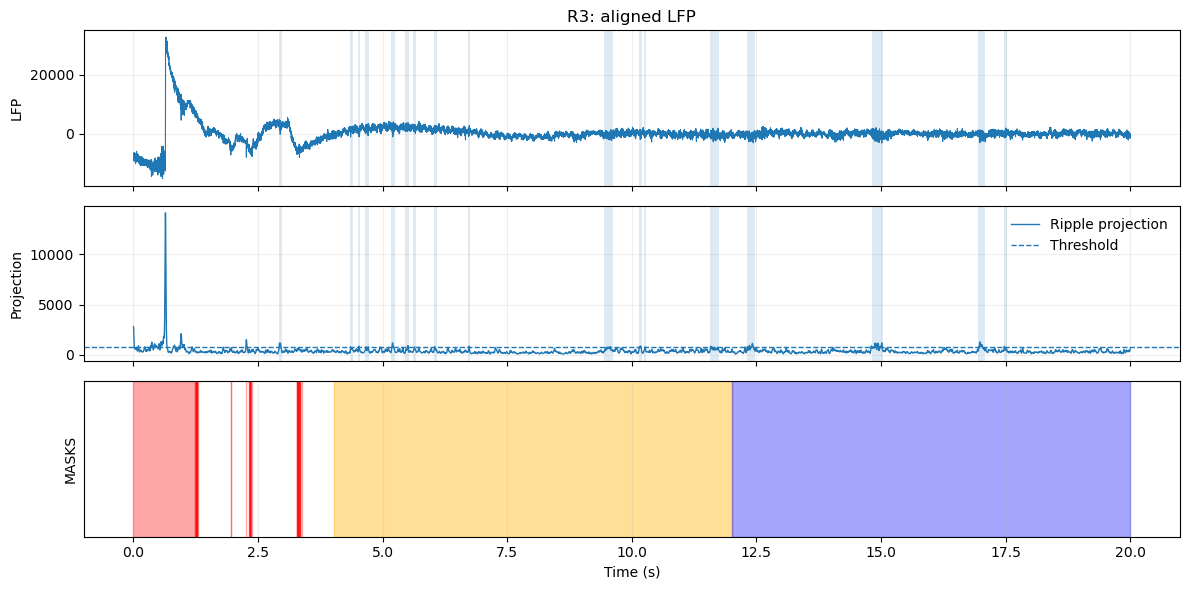


Running wavelet SWR detection for R4 (index 16)


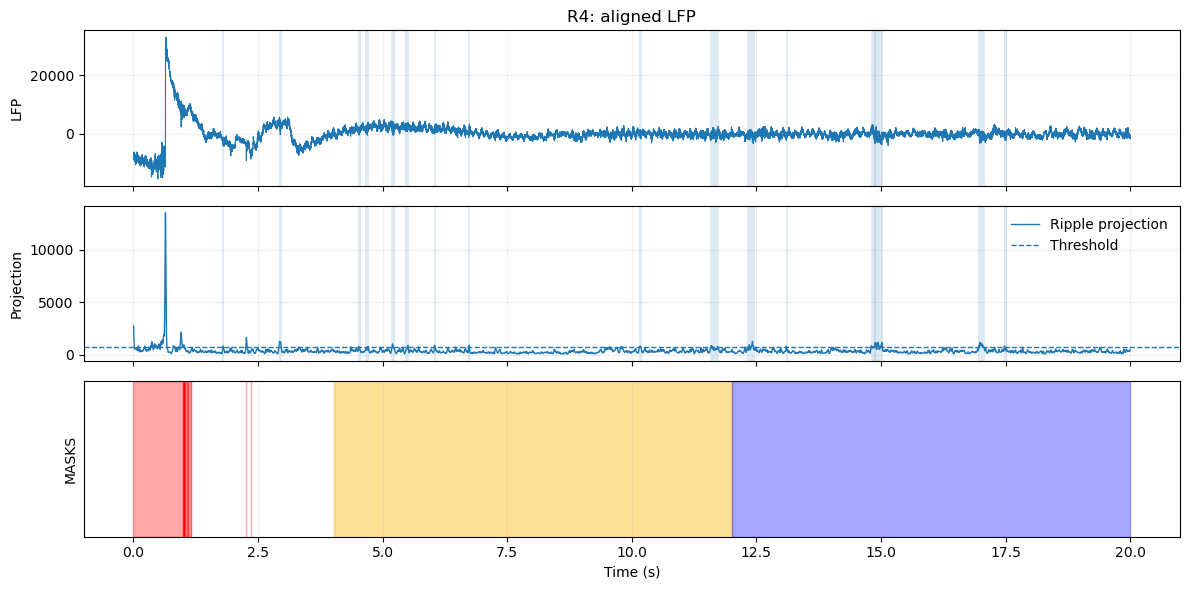


================ ARTIFACT INFO BY CHANNEL ================



,remove_first_s,n_first_samples,raw_amp_k,median,mad,robust_sd,n_artifact_samples_total,n_artifact_samples_amp_only,channel,animal_id,aligned_npy_path
0,1.0,2000,10.0,-29.0,574.0,851.0124,2168,1830,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,1.0,2000,10.0,-10.0,543.0,805.0518,2356,2164,R2,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,1.0,2000,10.0,20.0,415.0,615.2790,2617,2608,R3,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,1.0,2000,10.0,-24.0,541.0,802.0866,2183,1922,R4,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ WHOLE-TRACE SUMMARY BY CHANNEL ================



,channel,n_events_total,valid_duration_s,baseline_duration_s,baseline_mean_projection,baseline_sd_projection,threshold,event_rate_total_hz,mean_duration_total_ms,mean_peak_frequency_total_hz,mean_max_frequency_total_hz,mean_peak_intensity_total,mean_max_intensity_total,artifact_duration_s,baseline_mode,animal_id,aligned_npy_path
0,R2,141,202.6975,202.6975,292.564876,162.601019,780.367933,0.695618,67.347518,185.507958,229.436215,1206.996786,1646.424293,1.1780,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,R1,141,202.7915,202.7915,283.029545,161.864496,768.623035,0.695295,68.964539,184.659186,230.544932,1197.984315,1625.547244,1.0840,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,R3,136,202.5670,202.5670,298.729546,161.718750,783.885796,0.671383,67.988971,181.628425,228.135704,1215.978381,1633.331107,1.3085,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,R4,133,202.7840,202.7840,289.490441,162.571497,777.204933,0.655870,70.541353,185.533197,233.061768,1211.014156,1642.687735,1.0915,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ PARAMETERS BY CONDITION SET ================



,condition_set,condition,duration_s,n_events,event_rate_hz,mean_duration_ms,mean_peak_frequency_hz,mean_max_frequency_hz,mean_peak_intensity,mean_max_intensity,channel,animal_id,aligned_npy_path
0,condition_pre_post,WHOLE_TRACE,202.7915,141,0.695295,68.964539,184.659186,230.544932,1197.984315,1625.547244,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,condition_pre_post,STIM,96.1500,72,0.748830,72.770833,186.924342,229.613221,1173.517284,1607.500073,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,condition_pre_post,PRE_STIM,55.6005,24,0.431651,80.187500,179.160595,238.343882,1121.209026,1521.510616,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,condition_pre_post,POST_STIM,49.1180,31,0.631133,56.338710,189.425165,233.225806,1354.563537,1809.721797,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
4,condition_pre_post,STIM_OFF,106.6415,14,0.131281,58.107143,171.882731,216.030741,1108.718409,1488.894696,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
5,condition_pre_post,ARTIFACT,1.0840,0,0.000000,NaN,NaN,NaN,NaN,NaN,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
6,condition_stim_near,WHOLE_TRACE,202.7915,141,0.695295,68.964539,184.659186,230.544932,1197.984315,1625.547244,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
7,condition_stim_near,STIM,96.1500,72,0.748830,72.770833,186.924342,229.613221,1173.517284,1607.500073,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
8,condition_stim_near,NEAR_STIM,81.1180,55,0.678025,66.745455,184.946080,235.459148,1252.736114,1683.956918,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
9,condition_stim_near,STIM_OFF,106.6415,14,0.131281,58.107143,171.882731,216.030741,1108.718409,1488.894696,R1,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ EVENT TABLE (FIRST 50 ROWS) ================



,channel,peak_idx,peak_time_s,start_idx,end_idx,start_s,end_s,duration_ms,peak_projection,threshold,max_ripple_frequency_hz,avg_ripple_frequency_hz,max_ripple_intensity,avg_ripple_intensity,condition_stim_near,condition_pre_post,condition,animal_id,aligned_npy_path
0,R1,2351,1.1755,2295,2392,1.1475,1.1960,48.5,774.711510,768.623035,154.556962,151.327532,1574.422221,1240.258367,STIM_OFF,STIM_OFF,STIM_OFF,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,R1,3602,1.8010,3574,3660,1.7870,1.8300,43.0,775.253177,768.623035,177.594937,153.906388,1121.591295,875.663070,STIM_OFF,STIM_OFF,STIM_OFF,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,R1,4532,2.2660,4506,4573,2.2530,2.2865,33.5,1638.439977,768.623035,202.278481,176.846951,2056.928520,1590.173687,STIM_OFF,STIM_OFF,STIM_OFF,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,R1,4985,2.4925,4909,5070,2.4545,2.5350,80.5,787.933410,768.623035,250.000000,213.511282,1116.648189,782.386158,STIM_OFF,STIM_OFF,STIM_OFF,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
4,R1,5860,2.9300,5824,5950,2.9120,2.9750,63.0,1201.880648,768.623035,210.506329,176.393410,2036.518539,1441.074617,STIM_OFF,STIM_OFF,STIM_OFF,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
5,R1,6628,3.3140,6548,6754,3.2740,3.3770,103.0,770.324032,768.623035,250.000000,158.231535,1285.061441,900.823842,STIM_OFF,STIM_OFF,STIM_OFF,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
6,R1,8717,4.3585,8695,9000,4.3475,4.5000,152.5,783.904033,768.623035,250.000000,177.724424,1131.078811,771.647591,NEAR_STIM,PRE_STIM,NEAR_STIM,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
7,R1,10398,5.1990,10359,10481,5.1795,5.2405,61.0,1165.928768,768.623035,210.506329,175.342395,1885.585581,1436.406449,NEAR_STIM,PRE_STIM,NEAR_STIM,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
8,R1,11018,5.5090,10920,11045,5.4600,5.5225,62.5,1000.589216,768.623035,215.443038,175.554430,1642.668518,1084.270571,NEAR_STIM,PRE_STIM,NEAR_STIM,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
9,R1,12082,6.0410,12055,12182,6.0275,6.0910,63.5,877.024404,768.623035,218.734177,169.768763,1143.074712,949.365281,NEAR_STIM,PRE_STIM,NEAR_STIM,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...


In [189]:
# ============================================================
# 3) WAVELET ANALYSIS
# ============================================================
def detect_swr_wavelet_channel(
    x,
    fs,
    channel_name,
    baseline_mask,
    artifact_mask=None,
    w=10.0,
    fmin=120.0,
    fmax=250.0,
    n_freqs=80,
    thr_sd=3.0,
    min_duration_ms=20.0,
    prominence_sd=1.0,
    rel_height=0.7,
):
    x = np.asarray(x, dtype=np.float32)
    n = x.size
    t = np.arange(n) / fs

    valid_mask = np.isfinite(x)
    baseline_mask = np.asarray(baseline_mask, dtype=bool) & valid_mask

    if artifact_mask is None:
        artifact_mask = np.zeros(n, dtype=bool)
    else:
        artifact_mask = np.asarray(artifact_mask, dtype=bool)

    if baseline_mask.sum() == 0:
        raise ValueError(f"{channel_name}: baseline_mask has no valid samples")

    x_centered = x.copy()
    x_centered[valid_mask] = x_centered[valid_mask] - np.nanmedian(x_centered[valid_mask])
    x_centered[~valid_mask] = 0.0

    freq, widths = _build_wavelet_freqs_and_widths(
        fs=fs, fmin=fmin, fmax=fmax, n_freqs=n_freqs, w=w
    )
    cwt = signal.cwt(x_centered, signal.morlet2, widths, w=w)
    abs_cwt = np.abs(cwt)

    proj = np.mean(abs_cwt, axis=0)

    mu = float(np.mean(proj[baseline_mask]))
    sd = float(np.std(proj[baseline_mask], ddof=0))
    thr = mu + thr_sd * sd
    prominence = prominence_sd * sd

    min_width_samples = max(1, int(round(min_duration_ms * fs / 1000.0)))

    peaks, properties = find_peaks(
        proj,
        height=thr,
        prominence=prominence,
        width=min_width_samples,
    )

    if len(peaks) > 0:
        keep = valid_mask[peaks] & (~artifact_mask[peaks])
        peaks = peaks[keep]
        for k in list(properties.keys()):
            properties[k] = properties[k][keep]

    if len(peaks) > 0:
        width_results = peak_widths(proj, peaks, rel_height=rel_height)
        left_ips = width_results[2]
        right_ips = width_results[3]
    else:
        left_ips = np.array([], dtype=float)
        right_ips = np.array([], dtype=float)

    max_intensity_per_t = np.max(abs_cwt, axis=0)
    dominant_freq_per_t = freq[np.argmax(abs_cwt, axis=0)]

    rows = []
    for i_evt, pk in enumerate(peaks):
        start_idx = int(np.floor(left_ips[i_evt]))
        end_idx = int(np.ceil(right_ips[i_evt]))

        start_idx = max(0, min(start_idx, n - 1))
        end_idx = max(start_idx + 1, min(end_idx, n))

        if artifact_mask[pk]:
            continue

        evt_valid = valid_mask[start_idx:end_idx] & (~artifact_mask[start_idx:end_idx])
        if evt_valid.sum() == 0:
            continue

        evt_dom_freq = dominant_freq_per_t[start_idx:end_idx][evt_valid]
        evt_max_int = max_intensity_per_t[start_idx:end_idx][evt_valid]

        rows.append({
            "channel": channel_name,
            "peak_idx": int(pk),
            "peak_time_s": float(pk / fs),
            "start_idx": int(start_idx),
            "end_idx": int(end_idx),
            "start_s": float(start_idx / fs),
            "end_s": float(end_idx / fs),
            "duration_ms": float((end_idx - start_idx) * 1000.0 / fs),
            "peak_projection": float(proj[pk]),
            "threshold": float(thr),
            "max_ripple_frequency_hz": float(np.max(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "avg_ripple_frequency_hz": float(np.mean(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "max_ripple_intensity": float(np.max(evt_max_int)) if evt_max_int.size else np.nan,
            "avg_ripple_intensity": float(np.mean(evt_max_int)) if evt_max_int.size else np.nan,
        })

    events_df = pd.DataFrame(rows)

    summary = {
        "channel": channel_name,
        "n_events_total": int(len(events_df)),
        "valid_duration_s": float((valid_mask & ~artifact_mask).sum() / fs),
        "baseline_duration_s": float(baseline_mask.sum() / fs),
        "baseline_mean_projection": mu,
        "baseline_sd_projection": sd,
        "threshold": thr,
        "event_rate_total_hz": float(len(events_df) / ((valid_mask & ~artifact_mask).sum() / fs))
        if (valid_mask & ~artifact_mask).sum() > 0 else np.nan,
        "mean_duration_total_ms": float(events_df["duration_ms"].mean()) if len(events_df) else np.nan,
        "mean_peak_frequency_total_hz": float(events_df["avg_ripple_frequency_hz"].mean()) if len(events_df) else np.nan,
        "mean_max_frequency_total_hz": float(events_df["max_ripple_frequency_hz"].mean()) if len(events_df) else np.nan,
        "mean_peak_intensity_total": float(events_df["avg_ripple_intensity"].mean()) if len(events_df) else np.nan,
        "mean_max_intensity_total": float(events_df["max_ripple_intensity"].mean()) if len(events_df) else np.nan,
    }

    return {
        "events_df": events_df,
        "summary": summary,
        "t": t,
        "x": x,
        "projection": proj,
        "threshold": thr,
        "freq": freq,
        "abs_cwt": abs_cwt,
    }


def add_condition_set_stim_near(events_df, stim_mask, near_stim_mask, artifact_mask):
    """
    Separate condition system:
      STIM / STIM_OFF / NEAR_STIM / ARTIFACT
    """
    out = events_df.copy()
    if len(out) == 0:
        out["condition_stim_near"] = pd.Series(dtype=object)
        return out

    peak_idx = out["peak_idx"].to_numpy(dtype=int)
    cond = np.full(len(out), "STIM_OFF", dtype=object)

    valid = (peak_idx >= 0) & (peak_idx < len(stim_mask))
    non_art = valid & (~artifact_mask[peak_idx])

    cond[valid & artifact_mask[peak_idx]] = "ARTIFACT"
    cond[non_art & near_stim_mask[peak_idx]] = "NEAR_STIM"
    cond[non_art & stim_mask[peak_idx]] = "STIM"

    out["condition_stim_near"] = cond
    return out


def add_condition_set_pre_post(events_df, stim_mask, pre_stim_mask, post_stim_mask, artifact_mask):
    """
    Separate condition system:
      STIM / STIM_OFF / PRE_STIM / POST_STIM / ARTIFACT
    """
    out = events_df.copy()
    if len(out) == 0:
        out["condition_pre_post"] = pd.Series(dtype=object)
        return out

    peak_idx = out["peak_idx"].to_numpy(dtype=int)
    cond = np.full(len(out), "STIM_OFF", dtype=object)

    valid = (peak_idx >= 0) & (peak_idx < len(stim_mask))
    non_art = valid & (~artifact_mask[peak_idx])

    cond[valid & artifact_mask[peak_idx]] = "ARTIFACT"
    cond[non_art & post_stim_mask[peak_idx]] = "POST_STIM"
    cond[non_art & pre_stim_mask[peak_idx]] = "PRE_STIM"
    cond[non_art & stim_mask[peak_idx]] = "STIM"

    out["condition_pre_post"] = cond
    return out


def summarise_events_condition_set(
    events_df,
    condition_col,
    condition_masks,
    artifact_mask,
    fs,
    x,
):
    """
    condition_masks: ordered dict-like mapping from condition name -> mask
    For STIM_OFF, pass the intended mask directly.
    """
    valid_mask = np.isfinite(x)
    artifact_mask_valid = np.asarray(artifact_mask, dtype=bool) & valid_mask
    whole_mask_valid = valid_mask & (~artifact_mask_valid)

    rows = []

    rows.append({
        "condition_set": condition_col,
        "condition": "WHOLE_TRACE",
        "duration_s": float(whole_mask_valid.sum() / fs),
        "n_events": int(len(events_df[events_df[condition_col] != "ARTIFACT"])),
        "event_rate_hz": float(len(events_df[events_df[condition_col] != "ARTIFACT"]) / (whole_mask_valid.sum() / fs))
        if whole_mask_valid.sum() > 0 else np.nan,
        "mean_duration_ms": float(events_df.loc[events_df[condition_col] != "ARTIFACT", "duration_ms"].mean())
        if len(events_df[events_df[condition_col] != "ARTIFACT"]) else np.nan,
        "mean_peak_frequency_hz": float(events_df.loc[events_df[condition_col] != "ARTIFACT", "avg_ripple_frequency_hz"].mean())
        if len(events_df[events_df[condition_col] != "ARTIFACT"]) else np.nan,
        "mean_max_frequency_hz": float(events_df.loc[events_df[condition_col] != "ARTIFACT", "max_ripple_frequency_hz"].mean())
        if len(events_df[events_df[condition_col] != "ARTIFACT"]) else np.nan,
        "mean_peak_intensity": float(events_df.loc[events_df[condition_col] != "ARTIFACT", "avg_ripple_intensity"].mean())
        if len(events_df[events_df[condition_col] != "ARTIFACT"]) else np.nan,
        "mean_max_intensity": float(events_df.loc[events_df[condition_col] != "ARTIFACT", "max_ripple_intensity"].mean())
        if len(events_df[events_df[condition_col] != "ARTIFACT"]) else np.nan,
    })

    for cond_name, mask_used in condition_masks.items():
        mask_used = np.asarray(mask_used, dtype=bool) & valid_mask
        d = events_df[events_df[condition_col] == cond_name].copy()
        duration_s = float(mask_used.sum() / fs)

        rows.append({
            "condition_set": condition_col,
            "condition": cond_name,
            "duration_s": duration_s,
            "n_events": int(len(d)),
            "event_rate_hz": float(len(d) / duration_s) if duration_s > 0 else np.nan,
            "mean_duration_ms": float(d["duration_ms"].mean()) if len(d) else np.nan,
            "mean_peak_frequency_hz": float(d["avg_ripple_frequency_hz"].mean()) if len(d) else np.nan,
            "mean_max_frequency_hz": float(d["max_ripple_frequency_hz"].mean()) if len(d) else np.nan,
            "mean_peak_intensity": float(d["avg_ripple_intensity"].mean()) if len(d) else np.nan,
            "mean_max_intensity": float(d["max_ripple_intensity"].mean()) if len(d) else np.nan,
        })

    return pd.DataFrame(rows)


def plot_channel_diagnostic(
    det_res,
    events_df,
    stim_trains_table,
    pre_stim_table,
    post_stim_table,
    near_stim_table,
    artifact_mask,
    channel_name,
    window_s=20.0,
):
    t = det_res["t"]
    x = det_res["x"]
    proj = det_res["projection"]
    thr = det_res["threshold"]

    dt = np.median(np.diff(t))
    i1 = min(len(t), int(round(window_s / dt)))

    tt = t[:i1]
    xx = x[:i1]
    pp = proj[:i1]
    aa = artifact_mask[:i1]

    fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    ax0, ax1, ax2 = axes

    ax0.plot(tt, xx, lw=0.8)
    ax0.set_ylabel("LFP")
    ax0.set_title(f"{channel_name}: aligned LFP")

    ax1.plot(tt, pp, lw=1.0, label="Ripple projection")
    ax1.axhline(thr, ls="--", lw=1.0, label="Threshold")
    ax1.set_ylabel("Projection")
    ax1.legend(frameon=False)

    for _, rr in near_stim_table.iterrows():
        s = rr["start_s"]
        e = rr["end_s"]
        if e <= tt[0] or s >= tt[-1]:
            continue
        ax2.axvspan(max(s, tt[0]), min(e, tt[-1]), alpha=0.18, color="gold")

    for _, rr in pre_stim_table.iterrows():
        s = rr["start_s"]
        e = rr["end_s"]
        if e <= tt[0] or s >= tt[-1]:
            continue
        ax2.axvspan(max(s, tt[0]), min(e, tt[-1]), alpha=0.28, color="orange")

    for _, rr in post_stim_table.iterrows():
        s = rr["start_s"]
        e = rr["end_s"]
        if e <= tt[0] or s >= tt[-1]:
            continue
        ax2.axvspan(max(s, tt[0]), min(e, tt[-1]), alpha=0.28, color="green")

    for _, tr in stim_trains_table.iterrows():
        s = tr["start_s"]
        e = tr["end_s"]
        if e <= tt[0] or s >= tt[-1]:
            continue
        ax2.axvspan(max(s, tt[0]), min(e, tt[-1]), alpha=0.35, color="blue")

    if aa.any():
        aa_i = aa.astype(int)
        starts = np.where(np.diff(np.r_[0, aa_i]) == 1)[0]
        ends = np.where(np.diff(np.r_[aa_i, 0]) == -1)[0]
        for s_idx, e_idx in zip(starts, ends):
            s = tt[s_idx]
            e = tt[min(e_idx, len(tt) - 1)]
            ax2.axvspan(s, e, alpha=0.35, color="red")

    for _, ev in events_df.iterrows():
        if ev["end_s"] <= tt[0] or ev["start_s"] >= tt[-1]:
            continue
        ax0.axvspan(max(ev["start_s"], tt[0]), min(ev["end_s"], tt[-1]), alpha=0.15)
        ax1.axvspan(max(ev["start_s"], tt[0]), min(ev["end_s"], tt[-1]), alpha=0.15)

    ax2.set_ylabel("MASKS")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylim(0, 1)
    ax2.set_yticks([])

    for ax in axes:
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


# ----------------------------
# Run channel-by-channel wavelet analysis
# ----------------------------
all_results = {}
all_events = []
all_summary = []
all_condition_summary = []
all_artifact_info = []

for ch_name in CHANNEL_NAMES:
    if ch_name not in channel_map:
        continue

    ch_idx = int(channel_map[ch_name])
    if ch_idx < 0 or ch_idx >= lfp_aligned.shape[1]:
        continue

    print(f"\nRunning wavelet SWR detection for {ch_name} (index {ch_idx})")

    x = lfp_aligned[:, ch_idx]

    artifact_mask, artifact_info = build_artifact_mask(
        x=x,
        fs=fs,
        remove_first_s=ARTIFACT_REMOVE_FIRST_S,
        raw_amp_k=ARTIFACT_RAW_AMP_K,
    )
    artifact_info["channel"] = ch_name
    all_artifact_info.append(pd.DataFrame([artifact_info]))

    if BASELINE_USE_STIM_OFF_ONLY:
        baseline_mask = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    else:
        baseline_mask = np.isfinite(x) & (~artifact_mask)

    det_res = detect_swr_wavelet_channel(
        x=x,
        fs=fs,
        channel_name=ch_name,
        baseline_mask=baseline_mask,
        artifact_mask=artifact_mask,
        w=WAVELET_W,
        fmin=RIPPLE_FREQ_MIN,
        fmax=RIPPLE_FREQ_MAX,
        n_freqs=N_FREQS,
        thr_sd=THR_SD,
        min_duration_ms=MIN_DURATION_MS,
        prominence_sd=PEAK_PROMINENCE_SD,
        rel_height=PEAK_REL_HEIGHT,
    )

    events_df = det_res["events_df"].copy()

    # two independent condition systems
    events_df = add_condition_set_stim_near(
        events_df,
        stim_mask=stim_mask,
        near_stim_mask=near_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df = add_condition_set_pre_post(
        events_df,
        stim_mask=stim_mask,
        pre_stim_mask=pre_stim_mask,
        post_stim_mask=post_stim_mask,
        artifact_mask=artifact_mask,
    )

    # keep a default condition column for convenience = stim/near system
    events_df["condition"] = events_df["condition_stim_near"]

    stim_off_mask_valid = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    stim_mask_valid = np.isfinite(x) & (~artifact_mask) & stim_mask
    near_mask_valid = np.isfinite(x) & (~artifact_mask) & near_stim_mask
    pre_mask_valid = np.isfinite(x) & (~artifact_mask) & pre_stim_mask
    post_mask_valid = np.isfinite(x) & (~artifact_mask) & post_stim_mask
    artifact_mask_valid = np.isfinite(x) & artifact_mask

    summary_stim_near = summarise_events_condition_set(
        events_df,
        condition_col="condition_stim_near",
        condition_masks={
            "STIM": stim_mask_valid,
            "NEAR_STIM": near_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_stim_near["channel"] = ch_name

    summary_pre_post = summarise_events_condition_set(
        events_df,
        condition_col="condition_pre_post",
        condition_masks={
            "STIM": stim_mask_valid,
            "PRE_STIM": pre_mask_valid,
            "POST_STIM": post_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_pre_post["channel"] = ch_name

    condition_summary = pd.concat(
        [summary_stim_near, summary_pre_post],
        ignore_index=True
    )

    summary_row = pd.DataFrame([det_res["summary"]])
    summary_row["channel"] = ch_name
    summary_row["artifact_duration_s"] = float(artifact_mask.sum() / fs)
    summary_row["baseline_mode"] = "STIM_OFF_ONLY" if BASELINE_USE_STIM_OFF_ONLY else "WHOLE_TRACE_MINUS_ARTIFACT"

    all_results[ch_name] = {
        "det_res": det_res,
        "events_df": events_df,
        "summary": summary_row,
        "condition_summary": condition_summary,
        "artifact_mask": artifact_mask,
        "artifact_info": artifact_info,
        "baseline_mode": summary_row["baseline_mode"].iloc[0],
    }

    all_events.append(events_df)
    all_summary.append(summary_row)
    all_condition_summary.append(condition_summary)

    if MAKE_PLOTS:
        plot_channel_diagnostic(
            det_res=det_res,
            events_df=events_df,
            stim_trains_table=stim_trains_table,
            pre_stim_table=pre_stim_table,
            post_stim_table=post_stim_table,
            near_stim_table=near_stim_table,
            artifact_mask=artifact_mask,
            channel_name=ch_name,
            window_s=PLOT_WINDOW_S,
        )

# ----------------------------
# Combine outputs
# ----------------------------
df_events = pd.concat(all_events, ignore_index=True) if len(all_events) else pd.DataFrame()
df_summary = pd.concat(all_summary, ignore_index=True) if len(all_summary) else pd.DataFrame()
df_condition_summary = pd.concat(all_condition_summary, ignore_index=True) if len(all_condition_summary) else pd.DataFrame()
df_artifact_info = pd.concat(all_artifact_info, ignore_index=True) if len(all_artifact_info) else pd.DataFrame()

for df_ in [df_events, df_summary, df_condition_summary, df_artifact_info]:
    if len(df_) > 0:
        df_["animal_id"] = animal_id
        df_["aligned_npy_path"] = str(ALIGNED_NPY_PATH)

if len(df_summary):
    df_summary = df_summary.sort_values(
        ["event_rate_total_hz", "n_events_total"],
        ascending=[False, False]
    ).reset_index(drop=True)

if len(df_condition_summary):
    df_condition_summary["condition"] = pd.Categorical(
        df_condition_summary["condition"],
        categories=["WHOLE_TRACE", "STIM", "NEAR_STIM", "PRE_STIM", "POST_STIM", "STIM_OFF", "ARTIFACT"],
        ordered=True
    )
    df_condition_summary = df_condition_summary.sort_values(
        ["channel", "condition_set", "condition"]
    ).reset_index(drop=True)

print("\n================ ARTIFACT INFO BY CHANNEL ================\n")
display(df_artifact_info)

print("\n================ WHOLE-TRACE SUMMARY BY CHANNEL ================\n")
display(df_summary)

print("\n================ PARAMETERS BY CONDITION SET ================\n")
display(df_condition_summary)

print("\n================ EVENT TABLE (FIRST 50 ROWS) ================\n")
display(df_events.head(50))

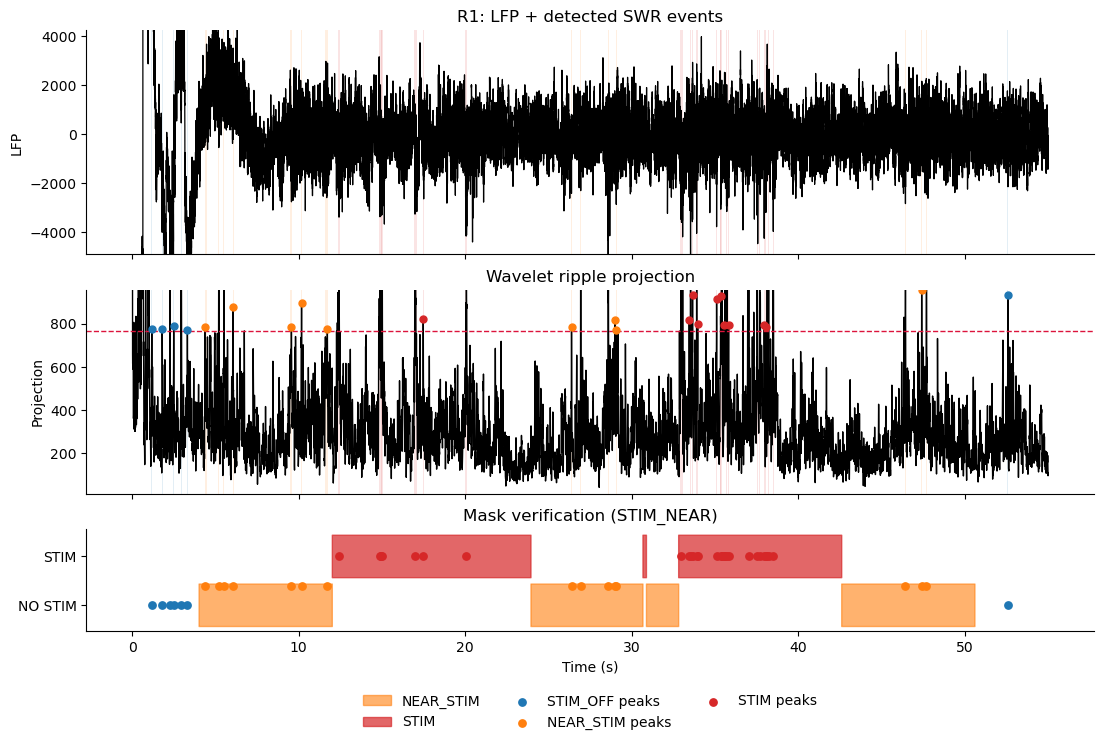

In [190]:
# ============================================================
# PLOT MASKS + EVENT PEAKS FOR ONE CHANNEL
# ============================================================

CHANNEL_TO_PLOT = "R1"
WINDOW_S = 55.0
START_S = 0.0

# ----------------------------
# NEW OPTION
# ----------------------------
# "STIM_NEAR" or "PRE_POST"
PLOT_MODE = "STIM_NEAR"

if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

det_res = all_results[CHANNEL_TO_PLOT]["det_res"]
events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()

t = det_res["t"]
x = det_res["x"]
proj = det_res["projection"]
thr = det_res["threshold"]

n = len(t)
if WINDOW_S is None:
    idx0 = 0
    idx1 = n
    i0 = t[0]
    i1 = t[-1]
else:
    idx0 = max(0, int(np.floor(START_S * fs)))
    idx1 = min(n, int(np.ceil((START_S + WINDOW_S) * fs)))
    if idx1 <= idx0:
        idx1 = min(n, idx0 + 1)
    i0 = idx0 / fs
    i1 = idx1 / fs

tt = t[idx0:idx1]
xx = x[idx0:idx1]
pp = proj[idx0:idx1]

stim_win = stim_mask[idx0:idx1].astype(float)
pre_win = pre_stim_mask[idx0:idx1].astype(float)

# optional masks (if exist)
near_win = near_stim_mask[idx0:idx1].astype(float) if "near_stim_mask" in globals() else np.zeros_like(stim_win)
post_win = post_stim_mask[idx0:idx1].astype(float) if "post_stim_mask" in globals() else np.zeros_like(stim_win)

# remove connector lines
stim_win_masked = np.where(stim_win > 0, stim_win, np.nan)
pre_win_masked = np.where(pre_win > 0, pre_win, np.nan)
near_win_masked = np.where(near_win > 0, near_win, np.nan)
post_win_masked = np.where(post_win > 0, post_win, np.nan)

events_win = events_df[
    (events_df["peak_time_s"] >= i0) &
    (events_df["peak_time_s"] < i1)
].copy()

cond_colors = {
    "STIM": "tab:red",
    "PRE_STIM": "tab:orange",
    "POST_STIM": "tab:orange",
    "NEAR_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
    "ARTIFACT": "gray",
}

def _robust_ylim(y, low=2, high=98, pad_frac=0.12, fallback=(-1, 1)):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return fallback
    lo, hi = np.percentile(y, [low, high])
    if not np.isfinite(lo) or not np.isfinite(hi):
        return fallback
    if hi <= lo:
        mid = float(np.nanmedian(y))
        return (mid - 1.0, mid + 1.0)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad

fig, axes = plt.subplots(
    3, 1, figsize=(13, 7.8), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 2.0, 1.0]}
)

ax0, ax1, ax2 = axes

# ------------------------------------------------------------
# Top: LFP
# ------------------------------------------------------------
ax0.plot(tt, xx, lw=0.9, color="black")

for _, ev in events_win.iterrows():
    c = cond_colors.get(ev["condition"], "gray")
    ax0.axvspan(ev["start_s"], ev["end_s"], color=c, alpha=0.12, lw=0)

ax0.set_ylabel("LFP")
ax0.set_title(f"{CHANNEL_TO_PLOT}: LFP + detected SWR events")
ax0.set_ylim(*_robust_ylim(xx))
ax0.spines["top"].set_visible(False)
ax0.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Middle: projection
# ------------------------------------------------------------
ax1.plot(tt, pp, lw=1.0, color="black")
ax1.axhline(thr, color="crimson", ls="--", lw=1.0)

for _, ev in events_win.iterrows():
    c = cond_colors.get(ev["condition"], "gray")
    ax1.axvspan(ev["start_s"], ev["end_s"], color=c, alpha=0.12, lw=0)
    ax1.plot(ev["peak_time_s"], ev["peak_projection"], marker="o", ms=5, color=c)

p_lo, p_hi = _robust_ylim(np.r_[pp, [thr]])
p_hi = max(p_hi, thr * 1.05)
ax1.set_ylim(p_lo, p_hi)

ax1.set_ylabel("Projection")
ax1.set_title("Wavelet ripple projection")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Bottom: masks + event peaks
# ------------------------------------------------------------

# PRE / NEAR / POST (same colour)
if PLOT_MODE == "PRE_POST":
    ax2.fill_between(
        tt, 0, pre_win_masked,
        step="pre", alpha=0.7, color="tab:orange", label="PRE_STIM"
    )
    ax2.fill_between(
        tt, 0, post_win_masked,
        step="pre", alpha=0.5, color="tab:orange", label="POST_STIM"
    )

elif PLOT_MODE == "STIM_NEAR":
    ax2.fill_between(
        tt, 0, near_win_masked,
        step="pre", alpha=0.6, color="tab:orange", label="NEAR_STIM"
    )

# STIM band
ax2.fill_between(
    tt, 1.15, 1.15 + stim_win_masked,
    step="pre", alpha=0.7, label="STIM", color="tab:red"
)

# ----------------------------
# EVENT DOTS (FIXED)
# ----------------------------
if PLOT_MODE == "STIM_NEAR":
    plot_conds = ["STIM_OFF", "NEAR_STIM", "STIM"]
    y_map = {
        "STIM_OFF": 0.5,
        "NEAR_STIM": 0.95,   # ← added back properly
        "STIM": 1.65
    }

elif PLOT_MODE == "PRE_POST":
    plot_conds = ["PRE_STIM", "POST_STIM"]
    y_map = {
        "PRE_STIM": 0.5,
        "POST_STIM": 0.5
    }

for cond in plot_conds:
    d = events_win[events_win["condition"] == cond]
    if len(d):
        c = cond_colors.get(cond, "gray")
        ax2.scatter(
            d["peak_time_s"],
            np.full(len(d), y_map[cond]),
            s=28,
            color=c,
            label=f"{cond} peaks"
        )

# ----------------------------
# AXIS FIX (what you asked)
# ----------------------------
ax2.set_ylim(-0.1, 2.3)
ax2.set_yticks([0.5, 1.65])
ax2.set_yticklabels(["NO STIM", "STIM"])  # ← fixed labels

ax2.set_xlabel("Time (s)")
ax2.set_title(f"Mask verification ({PLOT_MODE})")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# legend clean
handles, labels = ax2.get_legend_handles_labels()
seen = set()
uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        uniq_h.append(h)
        uniq_l.append(l)
        seen.add(l)

ax2.legend(
    uniq_h, uniq_l,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.5),
    ncol=3
)

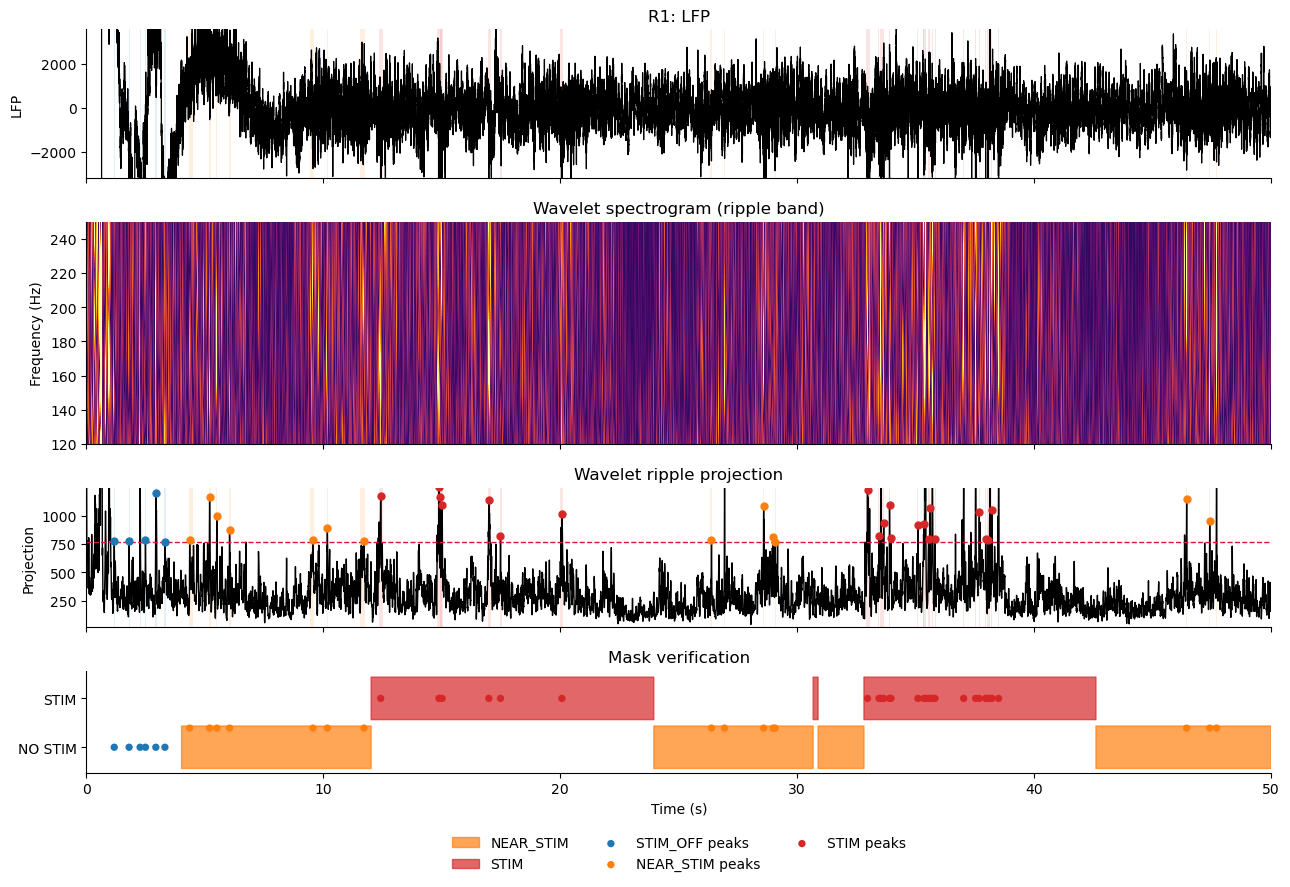

Plotted channel: R1
Window: 0.000 s to 50.000 s
Events in window: 49
condition
STIM         28
NEAR_STIM    15
STIM_OFF      6
Name: count, dtype: int64


In [191]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

def truncate_colormap(cmap_name="inferno", minval=0.15, maxval=1.0, n=256):
    cmap = plt.get_cmap(cmap_name)
    return mpl.colors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap_name}",
        cmap(np.linspace(minval, maxval, n))
    )

cmap_trunc = truncate_colormap("inferno", 0.15, 1.0)

def plot_swr_combined_panel(
    det_res,
    events_df,
    channel_name,
    stim_mask,
    near_stim_mask,
    fs,
    artifact_mask=None,
    start_s=0.0,
    window_s=10.0,
    vmax_percentile=99.5,
):
    """
    Combined plot:
      1) LFP
      2) Wavelet spectrogram
      3) Ripple projection
      4) Mask verification

    Uses:
      - STIM
      - NEAR_STIM
      - STIM_OFF

    Assumes your wavelet detection may now use 120–250 Hz.
    The spectrogram y-axis is set automatically from det_res["freq"].
    """

    t = det_res["t"]
    x = det_res["x"]
    proj = det_res["projection"]
    thr = det_res["threshold"]
    freq = det_res["freq"]
    abs_cwt = det_res["abs_cwt"]

    fs_local = 1.0 / np.median(np.diff(t))
    n = len(t)

    if artifact_mask is None:
        artifact_mask = np.zeros(n, dtype=bool)
    else:
        artifact_mask = np.asarray(artifact_mask, dtype=bool)

    idx0 = max(0, int(np.floor(start_s * fs_local)))
    idx1 = min(n, int(np.ceil((start_s + window_s) * fs_local)))
    if idx1 <= idx0:
        idx1 = min(n, idx0 + 1)

    # exact window bounds
    i0 = float(t[idx0])
    if idx1 < n:
        i1 = float(t[idx1])
    else:
        i1 = float(t[idx1 - 1] + 1.0 / fs_local)

    tt = t[idx0:idx1]
    xx = x[idx0:idx1]
    pp = proj[idx0:idx1]
    cwt_win = abs_cwt[:, idx0:idx1]

    stim_win = stim_mask[idx0:idx1].astype(float)
    near_win = near_stim_mask[idx0:idx1].astype(float)
    art_win = artifact_mask[idx0:idx1].astype(bool)

    stim_win_masked = np.where(stim_win > 0, stim_win, np.nan)
    near_win_masked = np.where(near_win > 0, near_win, np.nan)

    events_win = events_df[
        (events_df["peak_time_s"] >= i0) &
        (events_df["peak_time_s"] < i1)
    ].copy()

    cond_colors = {
        "STIM": "tab:red",
        "NEAR_STIM": "tab:orange",
        "STIM_OFF": "tab:blue",
        "ARTIFACT": "gray",
    }

    def _robust_ylim(y, mask=None, low=2, high=98, pad_frac=0.12, fallback=(-1, 1)):
        y = np.asarray(y, dtype=float)
        if mask is not None:
            mask = np.asarray(mask, dtype=bool)
            y = y[mask]
        y = y[np.isfinite(y)]

        if y.size == 0:
            return fallback

        lo, hi = np.percentile(y, [low, high])

        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            mid = np.nanmedian(y)
            return (mid - 1.0, mid + 1.0)

        pad = pad_frac * (hi - lo)
        return lo - pad, hi + pad

    # robust scaling excluding artifacts
    valid_non_art = (~art_win) & np.isfinite(xx)
    lfp_ylim = _robust_ylim(xx, mask=valid_non_art, low=2, high=98, pad_frac=0.12)

    valid_proj = (~art_win) & np.isfinite(pp)
    p_lo, p_hi = _robust_ylim(pp, mask=valid_proj, low=2, high=98, pad_frac=0.12)
    p_hi = max(p_hi, thr * 1.05)

    # spectrogram color scaling excluding artifact columns if possible
    if np.any(~art_win):
        cwt_for_vmax = cwt_win[:, ~art_win]
    else:
        cwt_for_vmax = cwt_win
    cwt_vals = cwt_for_vmax[np.isfinite(cwt_for_vmax)]
    vmax = np.percentile(cwt_vals, vmax_percentile) if cwt_vals.size else 1.0

    fig, axes = plt.subplots(
        4, 1, figsize=(13, 9.8), sharex=True,
        gridspec_kw={"height_ratios": [1.6, 2.4, 1.5, 1.1]}
    )

    ax0, ax1, ax2, ax3 = axes

    # ------------------------------------------------------------
    # 1) LFP
    # ------------------------------------------------------------
    ax0.plot(tt, xx, lw=0.9, color="black")

    for _, ev in events_win.iterrows():
        c = cond_colors.get(ev["condition"], "gray")
        ax0.axvspan(ev["start_s"], ev["end_s"], color=c, alpha=0.12, lw=0)

    ax0.set_ylabel("LFP")
    ax0.set_title(f"{channel_name}: LFP")
    ax0.set_ylim(*lfp_ylim)
    ax0.set_xlim(i0, i1)
    ax0.spines["top"].set_visible(False)
    ax0.spines["right"].set_visible(False)

    # ------------------------------------------------------------
    # 2) Wavelet spectrogram
    # ------------------------------------------------------------
    t_start = float(i0)
    t_end = float(i1)

    im = ax1.imshow(
        cwt_win,
        aspect="auto",
        origin="lower",
        extent=[t_start, t_end, freq[0], freq[-1]],
        interpolation="nearest",
        vmin=0,
        vmax=vmax,
        cmap=cmap_trunc,
    )

    ax1.set_xlim(t_start, t_end)
    for ax in [ax0, ax1, ax2, ax3]:
        ax.set_xlim(t_start, t_end)

    # if you're using 120-250 Hz, this will show the full actual range
    ax1.set_ylim(freq[0], freq[-1])

    # sensible ticks for 120–250 Hz
    if float(np.min(freq)) <= 120 and float(np.max(freq)) >= 250:
        ax1.set_yticks([120, 140, 160, 180, 200, 220, 240])
    else:
        ax1.set_yticks(np.linspace(freq[0], freq[-1], 5))

    ax1.set_ylabel("Frequency (Hz)")
    ax1.set_title("Wavelet spectrogram (ripple band)")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # ------------------------------------------------------------
    # 3) Projection
    # ------------------------------------------------------------
    ax2.plot(tt, pp, lw=1.0, color="black", label="Ripple projection")
    ax2.axhline(thr, color="crimson", ls="--", lw=1.0, label=f"Threshold ({thr:.3g})")

    for _, ev in events_win.iterrows():
        c = cond_colors.get(ev["condition"], "gray")
        ax2.axvspan(ev["start_s"], ev["end_s"], color=c, alpha=0.12, lw=0)
        ax2.plot(ev["peak_time_s"], ev["peak_projection"], marker="o", ms=5, color=c)

    ax2.set_ylabel("Projection")
    ax2.set_title("Wavelet ripple projection")
    ax2.set_ylim(p_lo, p_hi * 1.4)
    ax2.set_xlim(i0, i1)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # ------------------------------------------------------------
    # 4) Mask verification
    # ------------------------------------------------------------
    # NEAR_STIM
    ax3.fill_between(
        tt, 0, near_win_masked,
        step="pre", alpha=0.7, label="NEAR_STIM", color="tab:orange"
    )

    # STIM
    ax3.fill_between(
        tt, 1.15, 1.15 + stim_win_masked,
        step="pre", alpha=0.7, label="STIM", color="tab:red"
    )

    # optional artifact blocks
    # if art_win.any():
    #     art_i = art_win.astype(int)
    #     starts = np.where(np.diff(np.r_[0, art_i]) == 1)[0]
    #     ends = np.where(np.diff(np.r_[art_i, 0]) == -1)[0]
    #     for s_idx, e_idx in zip(starts, ends):
    #         s = tt[s_idx]
    #         e = tt[min(e_idx, len(tt) - 1)]
    #         ax3.axvspan(s, e, alpha=0.35, color="gray", label="ARTIFACT")

    # Event peaks
    for cond, yval in [("STIM_OFF", 0.5), ("NEAR_STIM", 0.95), ("STIM", 1.65)]:
        d = events_win[events_win["condition"] == cond]
        if len(d):
            c = cond_colors[cond]
            ax3.scatter(
                d["peak_time_s"],
                np.full(len(d), yval),
                s=28,
                color=c,
                edgecolors="none",
                linewidths=0,
                label=f"{cond} peaks"
            )

    ax3.set_ylim(-0.1, 2.3)
    ax3.set_yticks([0.5, 1.65])
    ax3.set_yticklabels(["NO STIM", "STIM"])
    ax3.set_xlabel("Time (s)")
    ax3.set_title("Mask verification")
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)

    # legend
    handles, labels = ax3.get_legend_handles_labels()
    seen = set()
    uniq_handles, uniq_labels = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            uniq_handles.append(h)
            uniq_labels.append(l)
            seen.add(l)

    ax3.legend(
        uniq_handles,
        uniq_labels,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.5),
        ncol=3
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

    print(f"Plotted channel: {channel_name}")
    print(f"Window: {i0:.3f} s to {i1:.3f} s")
    print(f"Events in window: {len(events_win)}")
    if len(events_win):
        print(events_win["condition"].value_counts(dropna=False))


plot_swr_combined_panel(
    det_res=all_results["R1"]["det_res"],
    events_df=all_results["R1"]["events_df"],
    channel_name="R1",
    stim_mask=stim_mask,
    near_stim_mask=near_stim_mask,
    fs=fs,
    artifact_mask=all_results["R1"]["artifact_mask"],
    start_s=0.0,
    window_s=50.0,
)

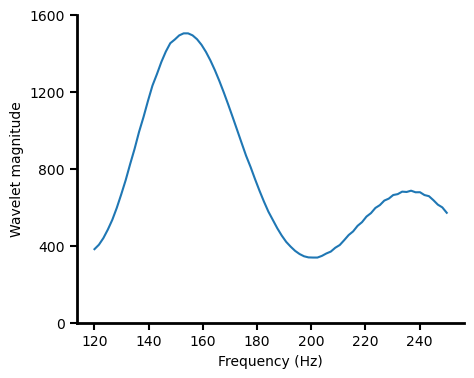

In [192]:
pk = int(all_results["R1"]["events_df"].iloc[0]["peak_idx"])
spec_slice = all_results["R1"]["det_res"]["abs_cwt"][:, pk]
freq = all_results["R1"]["det_res"]["freq"]

fig, ax = plt.subplots(figsize=(5, 4))

# ✅ default matplotlib blue (remove color=...)
ax.plot(freq, spec_slice, lw=1.5)

# labels
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Wavelet magnitude")

# y-axis starts at 0
ax.set_ylim(bottom=0)

# ✅ y ticks every 400
ymax = np.nanmax(spec_slice)
yticks = np.arange(0, ymax + 400, 400)
ax.set_yticks(yticks)

# remove box (top/right spines)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# thick left/bottom axes
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

# thicker ticks
ax.tick_params(axis='both', width=1.5, length=5)

plt.show()

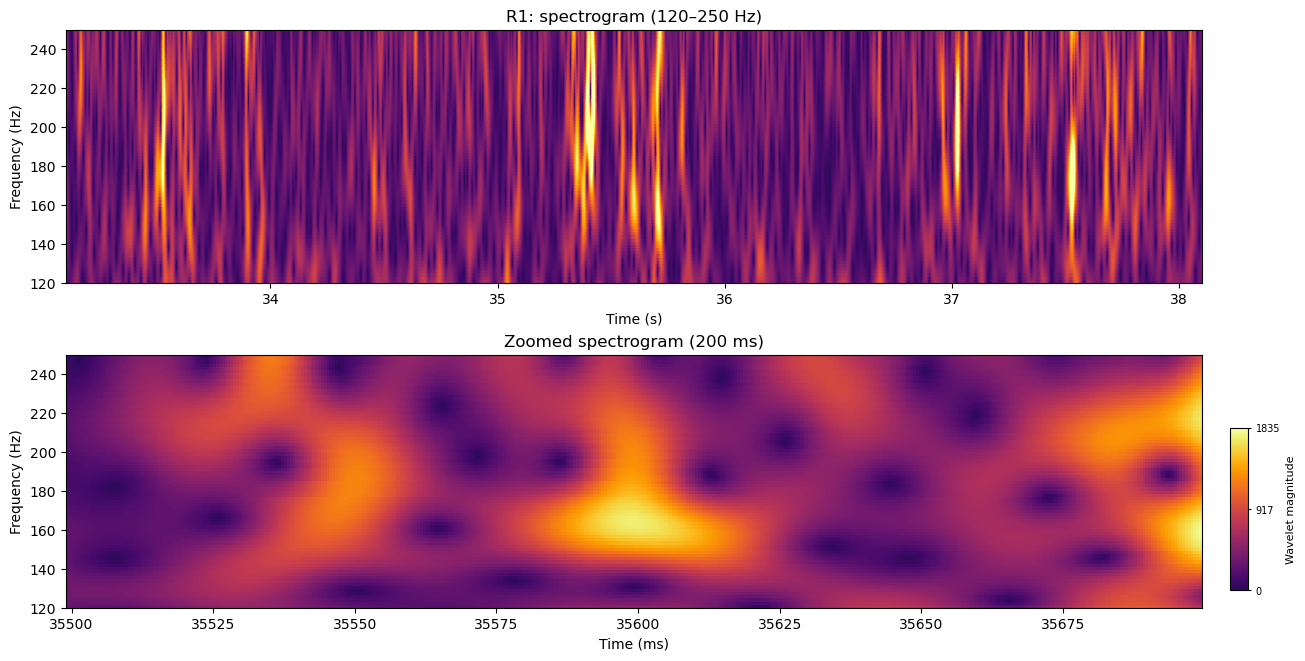

In [194]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def truncate_colormap(cmap_name="inferno", minval=0.15, maxval=1.0, n=256):
    cmap = plt.get_cmap(cmap_name)
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap_name}_{minval:.2f}_{maxval:.2f}",
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap


def plot_swr_spectrogram_two_panel_manual(
    det_res,
    channel_name,
    start_s=0.0,
    context_window_s=5.0,
    zoom_window_s=0.15,
    fmin_plot=120.0,
    fmax_plot=250.0,
    vmax_percentile=99.5,
    cmap_name="inferno",
    cmap_minval=0.15,
    cmap_maxval=1.0,
):
    """
    Two-panel spectrogram plot:
      1) context window in seconds
      2) zoom window in milliseconds

    Designed for current wavelet output in det_res.
    """

    t = np.asarray(det_res["t"], dtype=float)
    freq = np.asarray(det_res["freq"], dtype=float)
    abs_cwt = np.asarray(det_res["abs_cwt"], dtype=float)

    fs = 1.0 / np.median(np.diff(t))
    n = len(t)

    # --------------------------------------------------
    # Frequency selection
    # --------------------------------------------------
    freq_mask = (freq >= fmin_plot) & (freq <= fmax_plot)
    freq_sel = freq[freq_mask]

    if len(freq_sel) == 0:
        raise ValueError(
            f"No frequencies remain after applying fmin_plot={fmin_plot} and fmax_plot={fmax_plot}. "
            f"Available range in det_res is {freq.min():.1f}–{freq.max():.1f} Hz."
        )

    # --------------------------------------------------
    # Context window
    # --------------------------------------------------
    idx0 = max(0, int(np.floor(start_s * fs)))
    idx1 = min(n, int(np.ceil((start_s + context_window_s) * fs)))
    if idx1 <= idx0:
        idx1 = min(n, idx0 + 1)

    i0_ctx = float(t[idx0])
    i1_ctx = float(t[idx1]) if idx1 < n else float(t[idx1 - 1] + 1 / fs)
    cwt_ctx = abs_cwt[freq_mask, idx0:idx1]

    # --------------------------------------------------
    # Zoom window centered inside context window
    # --------------------------------------------------
    center_s = i0_ctx + context_window_s / 2.0
    idx0_z = max(0, int(np.floor((center_s - zoom_window_s / 2) * fs)))
    idx1_z = min(n, int(np.ceil((center_s + zoom_window_s / 2) * fs)))
    if idx1_z <= idx0_z:
        idx1_z = min(n, idx0_z + 1)

    i0_zoom = float(t[idx0_z])
    i1_zoom = float(t[idx1_z]) if idx1_z < n else float(t[idx1_z - 1] + 1 / fs)
    cwt_zoom = abs_cwt[freq_mask, idx0_z:idx1_z]

    # --------------------------------------------------
    # Shared color scaling
    # --------------------------------------------------
    vals_ctx = cwt_ctx[np.isfinite(cwt_ctx)].ravel()
    vals_zoom = cwt_zoom[np.isfinite(cwt_zoom)].ravel()
    vals = np.concatenate([vals_ctx, vals_zoom]) if (vals_ctx.size + vals_zoom.size) > 0 else np.array([1.0])
    vmax = np.percentile(vals, vmax_percentile) if vals.size else 1.0

    # --------------------------------------------------
    # Truncated colormap
    # --------------------------------------------------
    cmap_trunc = truncate_colormap(
        cmap_name=cmap_name,
        minval=cmap_minval,
        maxval=cmap_maxval,
        n=256
    )

    fig, axes = plt.subplots(
        2, 1,
        figsize=(12, 6.5),
        sharey=True,
        constrained_layout=True
    )
    ax0, ax1 = axes

    # --------------------------------------------------
    # Context spectrogram (seconds)
    # --------------------------------------------------
    im0 = ax0.imshow(
        cwt_ctx,
        aspect="auto",
        origin="lower",
        extent=[i0_ctx, i1_ctx, freq_sel[0], freq_sel[-1]],
        interpolation="none",
        vmin=0,
        vmax=vmax,
        cmap=cmap_trunc,
    )
    ax0.set_xlim(i0_ctx, i1_ctx)
    ax0.set_ylim(freq_sel[0], freq_sel[-1])
    ax0.set_xlabel("Time (s)")
    ax0.set_ylabel("Frequency (Hz)")
    ax0.set_title(f"{channel_name}: spectrogram ({fmin_plot:.0f}–{fmax_plot:.0f} Hz)")

    # make ticks sensible for 120–250
    if fmin_plot <= 120 and fmax_plot >= 250:
        ax0.set_yticks([120, 140, 160, 180, 200, 220, 240])
    else:
        ax0.set_yticks(np.linspace(freq_sel[0], freq_sel[-1], 5))

    # --------------------------------------------------
    # Zoom spectrogram (milliseconds)
    # --------------------------------------------------
    im1 = ax1.imshow(
        cwt_zoom,
        aspect="auto",
        origin="lower",
        extent=[i0_zoom * 1000, i1_zoom * 1000, freq_sel[0], freq_sel[-1]],
        interpolation="none",
        vmin=0,
        vmax=vmax,
        cmap=cmap_trunc,
    )
    ax1.set_xlim(i0_zoom * 1000, i1_zoom * 1000)
    ax1.set_ylim(freq_sel[0], freq_sel[-1])
    ax1.set_xlabel("Time (ms)")
    ax1.set_ylabel("Frequency (Hz)")
    ax1.set_title(f"Zoomed spectrogram ({zoom_window_s * 1000:.0f} ms)")

    if fmin_plot <= 120 and fmax_plot >= 250:
        ax1.set_yticks([120, 140, 160, 180, 200, 220, 240])
    else:
        ax1.set_yticks(np.linspace(freq_sel[0], freq_sel[-1], 5))

    # --------------------------------------------------
    # Short vertical colorbar (right side)
    # --------------------------------------------------
    cax = fig.add_axes([1.02, 0.10, 0.015, 0.25])
    cbar = fig.colorbar(im1, cax=cax, orientation="vertical")
    cbar.set_label("Wavelet magnitude", fontsize=8)
    cbar.ax.tick_params(labelsize=7, length=2)
    cbar.set_ticks([
        np.round(0, 2),
        np.round(vmax / 2, 2),
        np.round(vmax, 2)
    ])

    plt.show()


plot_swr_spectrogram_two_panel_manual(
    det_res=all_results["R1"]["det_res"],
    channel_name="R1",
    start_s=33.1,
    context_window_s=5.0,
    zoom_window_s=0.2,
    fmin_plot=120,
    fmax_plot=250,
)

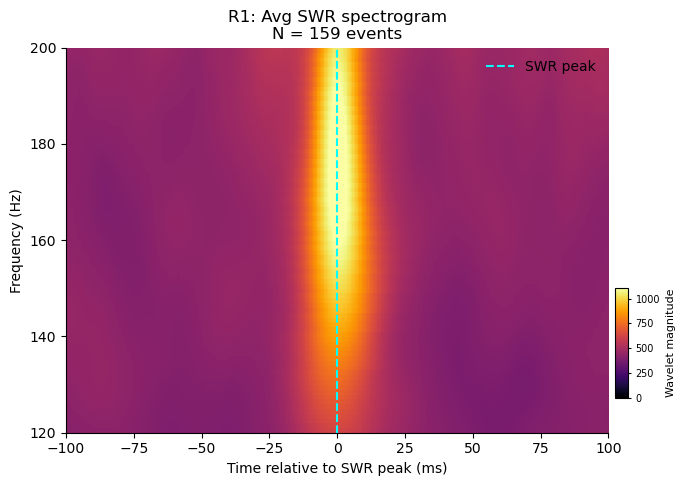

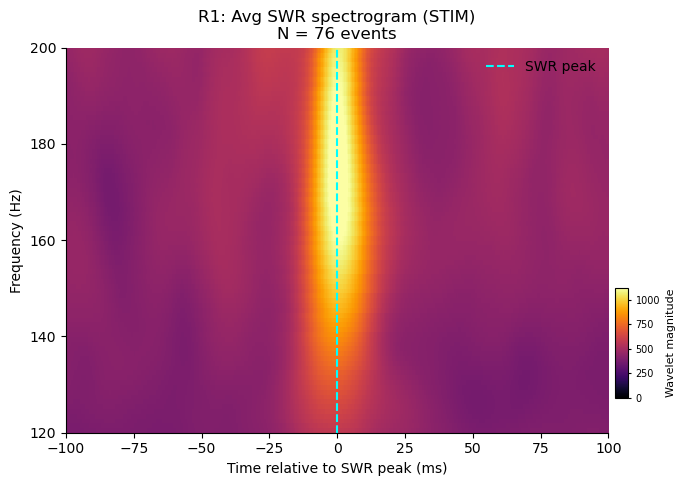

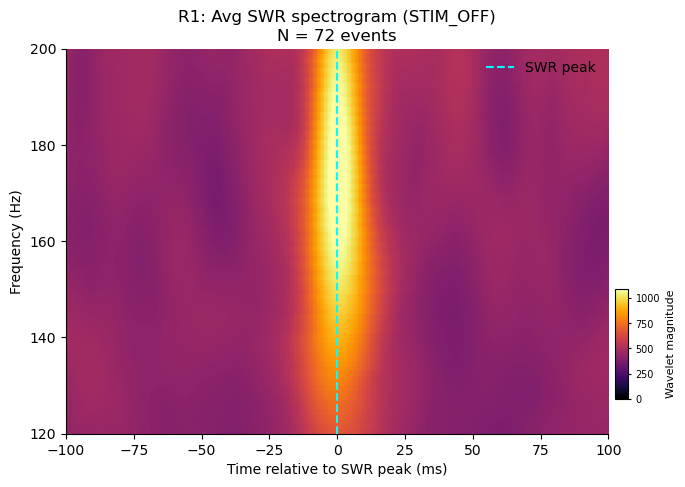

In [135]:

def truncate_colormap(cmap_name="inferno", minval=0, maxval=1.0, n=256):
    cmap = plt.get_cmap(cmap_name)
    return mpl.colors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap_name}",
        cmap(np.linspace(minval, maxval, n))
    )

def plot_event_triggered_avg_spectrogram(
    det_res,
    events_df,
    channel_name,
    condition=None,          # "STIM", "PRE_STIM", "STIM_OFF", or None
    t_before=0.1,            # seconds before peak
    t_after=0.1,             # seconds after peak
    vmax_percentile=99,
    cmap_name="inferno",
    cmap_minval=0,
    cmap_maxval=1.0,
):
    """
    Compute and plot event-triggered average wavelet spectrogram.
    """

    t = det_res["t"]
    freq = det_res["freq"]
    abs_cwt = det_res["abs_cwt"]

    fs = 1.0 / np.median(np.diff(t))
    n = len(t)

    # --------------------------------------------------
    # Select events
    # --------------------------------------------------
    df = events_df.copy()

    if condition is not None:
        df = df[df["condition"] == condition]

    if len(df) == 0:
        raise ValueError("No events found for this condition")

    # --------------------------------------------------
    # Window in samples
    # --------------------------------------------------
    n_before = int(round(t_before * fs))
    n_after = int(round(t_after * fs))
    win_len = n_before + n_after

    all_snippets = []

    # --------------------------------------------------
    # Extract spectrogram snippets
    # --------------------------------------------------
    for _, ev in df.iterrows():
        pk = int(ev["peak_idx"])

        i0 = pk - n_before
        i1 = pk + n_after

        if i0 < 0 or i1 >= n:
            continue

        snippet = abs_cwt[:, i0:i1]

        if snippet.shape[1] == win_len:
            all_snippets.append(snippet)

    if len(all_snippets) == 0:
        raise ValueError("No valid events after windowing")

    # --------------------------------------------------
    # Stack and average
    # --------------------------------------------------
    stack = np.stack(all_snippets, axis=0)   # (events, freq, time)
    mean_spec = np.mean(stack, axis=0)       # (freq, time)

    # --------------------------------------------------
    # Time axis relative to peak (ms)
    # --------------------------------------------------
    rel_t_ms = np.linspace(-t_before * 1000, t_after * 1000, win_len)

    vmax = np.percentile(mean_spec[np.isfinite(mean_spec)], vmax_percentile)

    # truncated colormap
    cmap_trunc = truncate_colormap(
        cmap_name=cmap_name,
        minval=cmap_minval,
        maxval=cmap_maxval,
        n=256
    )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))

    im = ax.imshow(
        mean_spec,
        aspect="auto",
        origin="lower",
        extent=[rel_t_ms[0], rel_t_ms[-1], freq[0], freq[-1]],
        vmin=0,
        vmax=vmax,
        cmap=cmap_trunc,
        interpolation="nearest",
    )

    ax.axvline(0, color="cyan", ls="--", lw=1.5, label="SWR peak")

    ax.set_xlabel("Time relative to SWR peak (ms)")
    ax.set_ylabel("Frequency (Hz)")

    # y ticks every 20 Hz
    y0 = int(np.ceil(freq[0] / 20.0) * 20)
    y1 = int(np.floor(freq[-1] / 20.0) * 20)
    ax.set_yticks(np.arange(y0, y1 + 1, 20))

    title = f"{channel_name}: Avg SWR spectrogram"
    if condition:
        title += f" ({condition})"
    title += f"\nN = {len(all_snippets)} events"

    ax.set_title(title)
    ax.legend(frameon=False, loc="upper right")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------------------------------------------------
    # Short vertical colorbar at bottom right
    # --------------------------------------------------
    cax = fig.add_axes([0.91, 0.18, 0.018, 0.22])
    cbar = fig.colorbar(im, cax=cax, orientation="vertical")
    cbar.set_label("Wavelet magnitude", fontsize=8)
    cbar.ax.tick_params(labelsize=7, length=2)

    plt.show()

plot_event_triggered_avg_spectrogram(
    det_res=all_results["R1"]["det_res"],
    events_df=all_results["R1"]["events_df"],
    channel_name="R1")

plot_event_triggered_avg_spectrogram(
    all_results["R1"]["det_res"],
    all_results["R1"]["events_df"],
    "R1",
    condition="STIM")

plot_event_triggered_avg_spectrogram(
    all_results["R1"]["det_res"],
    all_results["R1"]["events_df"],
    "R1",
    condition="STIM_OFF")

AO ses-33_date-20250924


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/2491570536.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


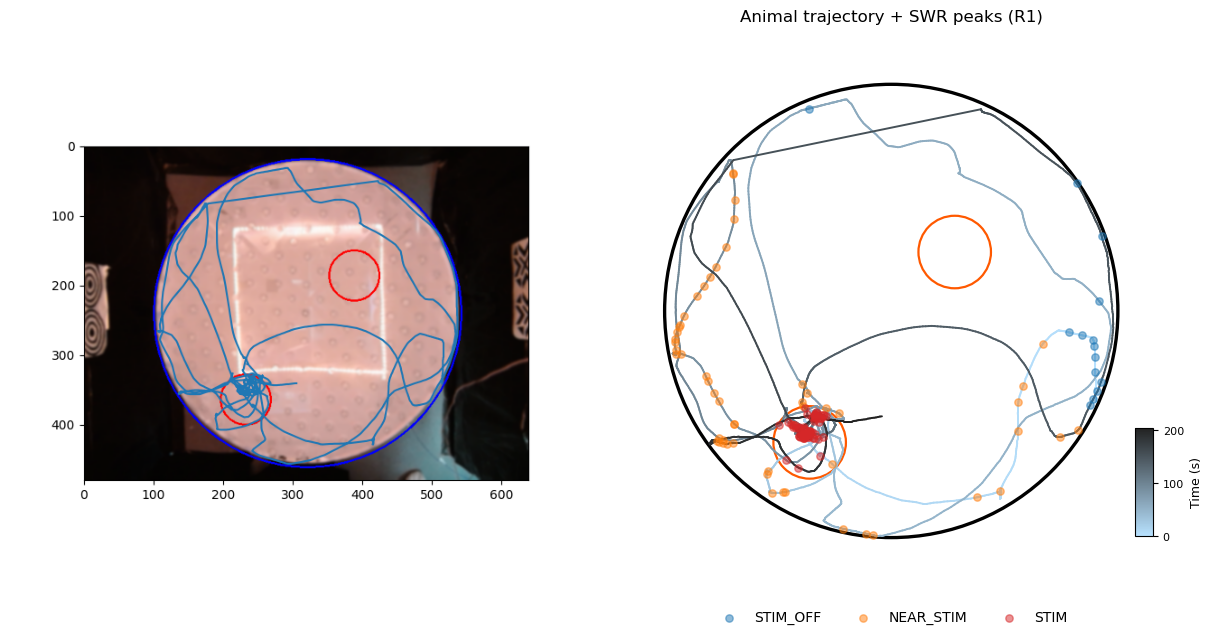

Channel used: R1
Condition column used: condition_stim_near
Total SWR peaks in events_df: 141
condition_stim_near
STIM         72
NEAR_STIM    55
STIM_OFF     14
Name: count, dtype: int64


In [195]:
# animal trajectory + SWR locations

from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
import matplotlib as mpl
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Load trial data
# ------------------------------------------------------------
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[2235])

position = dl.get_data('position')
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

print(dl.id, dl.ses_dir)

# ------------------------------------------------------------
# Choose SWR channel + condition system
# ------------------------------------------------------------
CHANNEL_TO_PLOT = "R1"

# choose which event-condition column to use
# options:
#   "condition_stim_near"  -> STIM / NEAR_STIM / STIM_OFF
#   "condition_pre_post"   -> STIM / PRE_STIM / POST_STIM / STIM_OFF
#   "condition"            -> default column if present
CONDITION_COLUMN = "condition_stim_near"

if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()

if CONDITION_COLUMN not in events_df.columns:
    raise ValueError(
        f"{CONDITION_COLUMN} not found in events_df. "
        f"Available columns: {list(events_df.columns)}"
    )

# remove artifact events
events_df = events_df[events_df[CONDITION_COLUMN] != "ARTIFACT"].copy()

# ------------------------------------------------------------
# Cheeseboard geometry
# ------------------------------------------------------------
BOARD_CENTER_X = 50
BOARD_CENTER_Y = 50
BOARD_RADIUS = 50
TRIGGER_RADIUS = 8
PLOT_PADDING = 12

fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=(1, 1))

# ------------------------------------------------------------
# Left panel: image
# ------------------------------------------------------------
axes[0].imshow(img)
axes[0].axis('off')

# ------------------------------------------------------------
# Right panel: trajectory
# ------------------------------------------------------------
ax = axes[1]
ax.set_facecolor("white")

# ------------------------------------------------------------
# Position time axis
# ------------------------------------------------------------
if 't' not in position.columns:
    raise ValueError("position dataframe does not contain column 't'.")

t = position['t'].values.astype(float)

# if t looks like ms, convert to s
dt = np.nanmedian(np.diff(t)) if len(t) > 1 else np.nan
if np.isfinite(dt) and dt > 1.0:
    t = t / 1000.0

x = position['x'].values.astype(float)
y = position['y'].values.astype(float)

ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)
x = x[ok]
y = y[ok]
t = t[ok]

# ------------------------------------------------------------
# Time-coloured trajectory
# ------------------------------------------------------------
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "traj_time",
    ['#b8e2ff', '#222222']
)
norm = mpl.colors.Normalize(t.min(), t.max())

lc = LineCollection(
    segments,
    cmap=cmap,
    norm=norm,
    linewidth=1.4,
    capstyle='round'
)
lc.set_array(t[:-1])
ax.add_collection(lc)

# ------------------------------------------------------------
# Map SWR peak times to nearest position points
# ------------------------------------------------------------
cond_colors = {
    "STIM": "tab:red",
    "NEAR_STIM": "tab:orange",
    "PRE_STIM": "tab:orange",
    "POST_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

if CONDITION_COLUMN == "condition_stim_near":
    cond_order = ["STIM_OFF", "NEAR_STIM", "STIM"]
elif CONDITION_COLUMN == "condition_pre_post":
    cond_order = ["STIM_OFF", "PRE_STIM", "POST_STIM", "STIM"]
else:
    # fallback
    cond_order = [c for c in ["STIM_OFF", "NEAR_STIM", "PRE_STIM", "POST_STIM", "STIM"] if c in events_df[CONDITION_COLUMN].unique()]

legend_done = set()

if len(events_df) and len(t):
    events_df = events_df.copy()
    events_df = events_df[
        (events_df["peak_time_s"] >= t.min()) &
        (events_df["peak_time_s"] <= t.max())
    ].copy()

    if len(events_df):
        swr_peak_times = events_df["peak_time_s"].to_numpy(dtype=float)

        idx = np.searchsorted(t, swr_peak_times)
        idx = np.clip(idx, 0, len(t) - 1)

        idx_prev = np.clip(idx - 1, 0, len(t) - 1)
        use_prev = np.abs(t[idx_prev] - swr_peak_times) < np.abs(t[idx] - swr_peak_times)
        idx[use_prev] = idx_prev[use_prev]

        events_df["traj_x"] = x[idx]
        events_df["traj_y"] = y[idx]

        # plot each condition separately
        for cond in cond_order:
            d = events_df[events_df[CONDITION_COLUMN] == cond]
            if len(d):
                ax.scatter(
                    d["traj_x"],
                    d["traj_y"],
                    s=28,
                    c=cond_colors.get(cond, "gray"),
                    alpha=0.5,
                    zorder=5,
                    label=cond if cond not in legend_done else None
                )
                legend_done.add(cond)

# ------------------------------------------------------------
# Cheeseboard circle
# ------------------------------------------------------------
board_circle = Circle(
    (BOARD_CENTER_X, BOARD_CENTER_Y),
    BOARD_RADIUS,
    color='black',
    fill=False,
    linewidth=2.4
)
ax.add_artist(board_circle)

# ------------------------------------------------------------
# Reward zones
# ------------------------------------------------------------
for i in range(len(triggerLoc)):
    cx = triggerLoc['x'][i]
    cy = triggerLoc['y'][i]

    reward_circle = Circle(
        (cx, cy),
        TRIGGER_RADIUS,
        color="#ff5900",
        fill=False,
        linewidth=1.6
    )
    ax.add_artist(reward_circle)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
ax.set_xlim(
    BOARD_CENTER_X - BOARD_RADIUS - PLOT_PADDING,
    BOARD_CENTER_X + BOARD_RADIUS + PLOT_PADDING
)

ax.set_ylim(
    BOARD_CENTER_Y + BOARD_RADIUS + PLOT_PADDING,
    BOARD_CENTER_Y - BOARD_RADIUS - PLOT_PADDING
)

ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f"Animal trajectory + SWR peaks ({CHANNEL_TO_PLOT})", fontsize=12)

if len(legend_done):
    ncol = 3 if len(legend_done) <= 3 else 4
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=ncol)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------
cax = fig.add_axes([0.95, 0.13, 0.015, 0.18])
cbar = fig.colorbar(lc, cax=cax)
cbar.set_label("Time (s)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print(f"Channel used: {CHANNEL_TO_PLOT}")
print(f"Condition column used: {CONDITION_COLUMN}")
print(f"Total SWR peaks in events_df: {len(events_df)}")
if len(events_df):
    print(events_df[CONDITION_COLUMN].value_counts(dropna=False))

In [ ]:
# making video of trajectory + L1FP + SWR events with audio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import Circle, Ellipse
from matplotlib.animation import FuncAnimation, FFMpegWriter
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, savgol_filter
import subprocess

# ============================================================
# USER SETTINGS
# ============================================================
ROW_IDX = 2235
CHANNEL_TO_PLOT = "R1"

# choose which condition system to use
# options:
#   "condition_stim_near" -> STIM / NEAR_STIM / STIM_OFF
#   "condition_pre_post"  -> STIM / PRE_STIM / POST_STIM / STIM_OFF
#   "condition"           -> fallback/default if present
CONDITION_COLUMN = "condition_stim_near"

VIDEO_FPS = 30
LFP_WINDOW_SECONDS = 2.0
OUTPUT_VIDEO = "trajectory_lfp_only.mp4"
OUTPUT_AUDIO = "trajectory_lfp_only_audio.wav"
FINAL_VIDEO = "trajectory_lfp_only_with_audio.mp4"

BOARD_CENTER_X = 50
BOARD_CENTER_Y = 50
BOARD_RADIUS = 50
TRIGGER_RADIUS = 8
PLOT_PADDING = 12

# --- audio ---
AUDIO_SR = 44100
BASE_LFP_GAIN = 0.025
RIPPLE_BOOST_GAIN = 0.35
FINAL_AUDIO_GAIN = 0.9

# now using 120–250 Hz ripple band
RIPPLE_AUDIO_FMIN = 120
RIPPLE_AUDIO_FMAX = 250

# --- SWR dot appearance ---
SWR_DOT_SIZE = 55
SWR_DOT_ALPHA = 0.45

# --- LFP SWR shading ---
LFP_SWR_SHADE_ALPHA = 0.18

# --- mouse shape on trajectory ---
MOUSE_BODY_LENGTH = 4.0
MOUSE_BODY_WIDTH = 2.4
MOUSE_HEAD_SIZE = 1.3
MOUSE_EAR_SIZE = 0.7

# ============================================================
# HELPERS
# ============================================================
def robust_normalize(x, q=99.5):
    x = np.asarray(x, dtype=float)
    finite = np.isfinite(x)
    if not np.any(finite):
        return np.zeros_like(x, dtype=float)
    scale = np.percentile(np.abs(x[finite]), q)
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0
    return np.clip(x / scale, -1, 1)

def bandpass_filter(x, fs, low, high, order=3):
    nyq = fs / 2.0
    low = max(low / nyq, 1e-6)
    high = min(high / nyq, 0.999)
    if high <= low:
        raise ValueError(f"Invalid bandpass range: {low*nyq}–{high*nyq} Hz")
    b, a = butter(order, [low, high], btype="bandpass")
    return filtfilt(b, a, x)

def lowpass_filter(x, fs, high, order=3):
    nyq = fs / 2.0
    high = min(high / nyq, 0.999)
    b, a = butter(order, high, btype="low")
    return filtfilt(b, a, x)

def resample_to_audio_time(t_src, x_src, sr, t0, t1):
    t_audio = np.arange(int(np.ceil((t1 - t0) * sr))) / sr + t0
    x_interp = np.interp(t_audio, t_src, x_src)
    return t_audio, x_interp

def rotate_points(points_xy, angle_rad):
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    R = np.array([[c, -s], [s, c]])
    return points_xy @ R.T

# ============================================================
# LOAD TRIAL DATA
# ============================================================
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[ROW_IDX])

position = dl.get_data("position")
triggerLoc = dl.get_data("triggerLoc")

print("Trial row:", ROW_IDX)
print("DataLoader:", dl.id, dl.ses_dir)

if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

det_res = all_results[CHANNEL_TO_PLOT]["det_res"]
events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()

if CONDITION_COLUMN not in events_df.columns:
    raise ValueError(
        f"{CONDITION_COLUMN} not found in events_df. "
        f"Available columns: {list(events_df.columns)}"
    )

events_df = events_df[events_df[CONDITION_COLUMN] != "ARTIFACT"].copy()

# keep a generic column for plotting downstream
events_df["condition_plot"] = events_df[CONDITION_COLUMN]

# ============================================================
# POSITION TIME / XY
# ============================================================
if "t" not in position.columns:
    raise ValueError("position dataframe does not contain column 't'.")

t_pos = position["t"].to_numpy(dtype=float)
if np.nanmedian(np.diff(t_pos)) > 1.0:
    t_pos = t_pos / 1000.0

x = position["x"].to_numpy(dtype=float)
y = position["y"].to_numpy(dtype=float)

ok = np.isfinite(t_pos) & np.isfinite(x) & np.isfinite(y)
t_pos = t_pos[ok]
x = x[ok]
y = y[ok]

# ============================================================
# LFP / SWR TIMES
# ============================================================
t_lfp = np.asarray(det_res["t"], dtype=float)
lfp = np.asarray(det_res["x"], dtype=float)

t_min = max(np.nanmin(t_pos), np.nanmin(t_lfp))
t_max = min(np.nanmax(t_pos), np.nanmax(t_lfp))

events_df = events_df[
    (events_df["peak_time_s"] >= t_min) &
    (events_df["peak_time_s"] <= t_max)
].copy()

cond_colors = {
    "STIM": "tab:red",
    "NEAR_STIM": "tab:orange",
    "PRE_STIM": "tab:orange",
    "POST_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

# map event times to trajectory coords
if len(events_df):
    swr_t = events_df["peak_time_s"].to_numpy(dtype=float)
    idx = np.searchsorted(t_pos, swr_t)
    idx = np.clip(idx, 0, len(t_pos) - 1)
    idx_prev = np.clip(idx - 1, 0, len(t_pos) - 1)
    use_prev = np.abs(t_pos[idx_prev] - swr_t) < np.abs(t_pos[idx] - swr_t)
    idx[use_prev] = idx_prev[use_prev]
    events_df["traj_x"] = x[idx]
    events_df["traj_y"] = y[idx]

# ============================================================
# BUILD AUDIO
# ============================================================
fs_lfp = 1.0 / np.median(np.diff(t_lfp))
print("Aligned LFP fs:", fs_lfp)

lfp_finite = np.copy(lfp)
lfp_finite[~np.isfinite(lfp_finite)] = np.nanmedian(lfp[np.isfinite(lfp)])

lfp_base = lowpass_filter(lfp_finite, fs_lfp, high=40, order=3)
ripple_band = bandpass_filter(lfp_finite, fs_lfp, RIPPLE_AUDIO_FMIN, RIPPLE_AUDIO_FMAX, order=3)

t_audio, base_audio = resample_to_audio_time(t_lfp, lfp_base, AUDIO_SR, t_min, t_max)
_, ripple_audio = resample_to_audio_time(t_lfp, ripple_band, AUDIO_SR, t_min, t_max)

base_audio = robust_normalize(base_audio)
ripple_audio = robust_normalize(ripple_audio)

base_audio = savgol_filter(base_audio, 101, 3, mode="interp")
base_audio = np.tanh(1.2 * base_audio)
ripple_audio = np.tanh(2.5 * ripple_audio)

audio = BASE_LFP_GAIN * base_audio + RIPPLE_BOOST_GAIN * ripple_audio
audio = robust_normalize(audio) * FINAL_AUDIO_GAIN
audio = np.clip(audio, -0.98, 0.98)

wavfile.write(OUTPUT_AUDIO, AUDIO_SR, (audio * 32767).astype(np.int16))
print("Saved audio:", OUTPUT_AUDIO)

# ============================================================
# VIDEO FIGURE
# ============================================================
fig = plt.figure(figsize=(13.5, 7.2))

gs = fig.add_gridspec(
    3, 2,
    width_ratios=[1.12, 1.35],
    height_ratios=[0.35, 0.3, 0.40],
    wspace=0.18,
    hspace=0.02
)

ax_blank_top = fig.add_subplot(gs[0, 0])
ax_lfp = fig.add_subplot(gs[1, 0])
ax_blank_bottom = fig.add_subplot(gs[2, 0])
ax_traj = fig.add_subplot(gs[:, 1])

ax_blank_top.axis("off")
ax_blank_bottom.axis("off")

# ----------------------------
# Right panel: trajectory
# ----------------------------
ax_traj.set_facecolor("white")
ax_traj.set_xlim(
    BOARD_CENTER_X - BOARD_RADIUS - PLOT_PADDING,
    BOARD_CENTER_X + BOARD_RADIUS + PLOT_PADDING
)
ax_traj.set_ylim(
    BOARD_CENTER_Y + BOARD_RADIUS + PLOT_PADDING,
    BOARD_CENTER_Y - BOARD_RADIUS - PLOT_PADDING
)
ax_traj.set_aspect("equal")
ax_traj.set_xticks([])
ax_traj.set_yticks([])
for spine in ax_traj.spines.values():
    spine.set_visible(False)
ax_traj.set_title(f"Trajectory + SWRs ({CHANNEL_TO_PLOT})", fontsize=13, pad=10)

board_circle = Circle(
    (BOARD_CENTER_X, BOARD_CENTER_Y),
    BOARD_RADIUS,
    color="black",
    fill=False,
    linewidth=2.4
)
ax_traj.add_artist(board_circle)

for i in range(len(triggerLoc)):
    reward_circle = Circle(
        (float(triggerLoc["x"].iloc[i]), float(triggerLoc["y"].iloc[i])),
        TRIGGER_RADIUS,
        color="#ff5900",
        fill=False,
        linewidth=1.7
    )
    ax_traj.add_artist(reward_circle)

# static faint full trajectory
ax_traj.plot(x, y, color="0.85", lw=1.1, zorder=1)

# animated growing trajectory
traj_line, = ax_traj.plot([], [], color="black", lw=1.9, zorder=3)

# persistent SWR dots
swr_seen = ax_traj.scatter(
    [],
    [],
    s=SWR_DOT_SIZE,
    facecolors=[],
    edgecolors="none",
    linewidths=0,
    alpha=SWR_DOT_ALPHA,
    zorder=5
)

# mouse shape (body + head + ears)
mouse_body = Ellipse(
    (0, 0),
    width=MOUSE_BODY_LENGTH,
    height=MOUSE_BODY_WIDTH,
    angle=0,
    facecolor="black",
    edgecolor="none",
    zorder=6
)
ax_traj.add_patch(mouse_body)

mouse_head = Circle(
    (0, 0),
    radius=MOUSE_HEAD_SIZE / 2.0,
    facecolor="black",
    edgecolor="none",
    zorder=6
)
ax_traj.add_patch(mouse_head)

mouse_ear_left = Circle(
    (0, 0),
    radius=MOUSE_EAR_SIZE,
    facecolor="black",
    edgecolor="none",
    zorder=6
)
ax_traj.add_patch(mouse_ear_left)

mouse_ear_right = Circle(
    (0, 0),
    radius=MOUSE_EAR_SIZE,
    facecolor="black",
    edgecolor="none",
    zorder=6
)
ax_traj.add_patch(mouse_ear_right)

# ----------------------------
# Left panel: LFP
# ----------------------------
ax_lfp.set_title(f"{CHANNEL_TO_PLOT} aligned LFP", fontsize=12, pad=8)
ax_lfp.set_xlabel("Time (s)", fontsize=10)
ax_lfp.set_ylabel("LFP", fontsize=10)
ax_lfp.spines["top"].set_visible(False)
ax_lfp.spines["right"].set_visible(False)
ax_lfp.spines["left"].set_linewidth(1.5)
ax_lfp.spines["bottom"].set_linewidth(1.5)

ax_lfp.tick_params(axis="x", labelsize=8, width=1.2, length=4)
ax_lfp.tick_params(axis="y", labelsize=8, width=1.2, length=4)

lfp_line, = ax_lfp.plot([], [], lw=1.0, color="0.2")
lfp_now = ax_lfp.axvline(0, color="#e76f51", lw=1.2, alpha=0.9)

lfp_swr_patches = []
lfp_ylim = (-5000, 5000)

# ============================================================
# ANIMATION
# ============================================================
video_times = np.arange(t_min, t_max, 1.0 / VIDEO_FPS)

def update(frame_idx):
    global lfp_swr_patches

    t_now = video_times[frame_idx]

    # ---------------- trajectory grows from start ----------------
    i_pos = np.searchsorted(t_pos, t_now, side="right") - 1
    i_pos = np.clip(i_pos, 0, len(t_pos) - 1)

    traj_line.set_data(x[:i_pos + 1], y[:i_pos + 1])

    # direction for mouse orientation
    k_back = 5
    j = max(0, i_pos - k_back)

    dx_dir = x[i_pos] - x[j]
    dy_dir = y[i_pos] - y[j]
    disp = np.hypot(dx_dir, dy_dir)

    if frame_idx == 0:
        update.prev_theta = 0.0

    if disp > 0.5:
        theta = np.arctan2(dy_dir, dx_dir)
        update.prev_theta = theta
    else:
        theta = update.prev_theta

    # body
    mouse_body.center = (x[i_pos], y[i_pos])
    mouse_body.angle = np.degrees(theta)

    # head
    head_offset = np.array([[MOUSE_BODY_LENGTH * 0.32, 0.0]])
    head_xy = rotate_points(head_offset, theta)[0] + np.array([x[i_pos], y[i_pos]])
    mouse_head.center = tuple(head_xy)

    # ears
    ear_left_local = np.array([[MOUSE_BODY_LENGTH * 0.22,  MOUSE_BODY_WIDTH * 0.38]])
    ear_right_local = np.array([[MOUSE_BODY_LENGTH * 0.22, -MOUSE_BODY_WIDTH * 0.38]])

    ear_left_xy = rotate_points(ear_left_local, theta)[0] + np.array([x[i_pos], y[i_pos]])
    ear_right_xy = rotate_points(ear_right_local, theta)[0] + np.array([x[i_pos], y[i_pos]])

    mouse_ear_left.center = tuple(ear_left_xy)
    mouse_ear_right.center = tuple(ear_right_xy)

    # ---------------- persistent coloured SWR dots ----------------
    if len(events_df):
        d = events_df.loc[events_df["peak_time_s"] <= t_now]
        if len(d):
            pts = np.column_stack([d["traj_x"].to_numpy(float), d["traj_y"].to_numpy(float)])
            cols = [cond_colors.get(c, "tab:blue") for c in d["condition_plot"]]
            swr_seen.set_offsets(pts)
            swr_seen.set_facecolors(cols)
            swr_seen.set_edgecolors("none")
            swr_seen.set_linewidths(0)
            swr_seen.set_alpha(SWR_DOT_ALPHA)
        else:
            swr_seen.set_offsets(np.empty((0, 2)))
    else:
        swr_seen.set_offsets(np.empty((0, 2)))

    # ---------------- LFP plot: scrolling 2 s window ----------------
    if t_now <= LFP_WINDOW_SECONDS:
        l0 = 0.0
        l1 = LFP_WINDOW_SECONDS
    else:
        l0 = t_now - LFP_WINDOW_SECONDS
        l1 = t_now

    m = (t_lfp >= l0) & (t_lfp <= l1)
    tx = t_lfp[m]
    yy = lfp[m]

    if np.any(m):
        lfp_line.set_data(tx, yy)
        ax_lfp.set_xlim(l0, l1)
        ax_lfp.set_ylim(*lfp_ylim)

        tick_step = 0.5
        first_tick = np.ceil(l0 / tick_step) * tick_step
        xticks = np.arange(first_tick, l1 + 1e-9, tick_step)

        ax_lfp.set_xticks(xticks)
        ax_lfp.set_xticklabels([f"{v:.1f}" for v in xticks], fontsize=8)

        lfp_now.set_xdata([t_now, t_now])
    else:
        lfp_line.set_data([], [])

    # remove old LFP SWR patches
    for patch in lfp_swr_patches:
        patch.remove()
    lfp_swr_patches = []

    # add SWR shading in current LFP window
    if len(events_df):
        d_win = events_df.loc[
            (events_df["end_s"] >= l0) &
            (events_df["start_s"] <= l1) &
            (events_df["peak_time_s"] <= t_now)
        ]
        for _, ev in d_win.iterrows():
            c = cond_colors.get(ev["condition_plot"], "tab:blue")
            patch = ax_lfp.axvspan(
                ev["start_s"],
                ev["end_s"],
                color=c,
                alpha=LFP_SWR_SHADE_ALPHA,
                lw=0,
                zorder=0
            )
            lfp_swr_patches.append(patch)

    ax_traj.set_title(
        f"Trajectory + SWRs ({CHANNEL_TO_PLOT}, {CONDITION_COLUMN})   t = {t_now:0.2f} s",
        fontsize=13,
        pad=10
    )
    ax_lfp.set_title(f"{CHANNEL_TO_PLOT} aligned LFP", fontsize=12, pad=8)

    artists = [
        traj_line, swr_seen,
        mouse_body, mouse_head, mouse_ear_left, mouse_ear_right,
        lfp_line, lfp_now
    ]
    artists.extend(lfp_swr_patches)
    return artists

anim = FuncAnimation(
    fig,
    update,
    frames=len(video_times),
    interval=1000 / VIDEO_FPS,
    blit=False
)

# ============================================================
# SAVE VIDEO
# ============================================================
writer = FFMpegWriter(fps=VIDEO_FPS, bitrate=3000)
anim.save(OUTPUT_VIDEO, writer=writer)
plt.close(fig)
print("Saved silent video:", OUTPUT_VIDEO)

# ============================================================
# MUX AUDIO + VIDEO
# ============================================================
try:
    cmd = [
        "ffmpeg",
        "-y",
        "-i", OUTPUT_VIDEO,
        "-i", OUTPUT_AUDIO,
        "-c:v", "copy",
        "-c:a", "aac",
        "-shortest",
        FINAL_VIDEO,
    ]
    subprocess.run(cmd, check=True)
    print("Saved final video with audio:", FINAL_VIDEO)
except Exception as e:
    print("Could not mux audio automatically.")
    print("Silent video:", OUTPUT_VIDEO)
    print("Audio wav:", OUTPUT_AUDIO)
    print("Reason:", repr(e))

Trial row: 2235
DataLoader: AO ses-33_date-20250924
Aligned LFP fs: 1999.9999999904503
Saved audio: trajectory_lfp_only_audio.wav
Saved silent video: trajectory_lfp_only.mp4


ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with clang version 18.1.8
  configuration: --prefix=/Users/stella/miniforge3/envs/cheeseboard-lfp --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1732155217949/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libmp3lame --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zl

Saved final video with audio: trajectory_lfp_only_with_audio.mp4


[out#0/mp4 @ 0x1376159d0] video:55710KiB audio:1730KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.362014%
frame= 6115 fps=0.0 q=-1.0 Lsize=   57648KiB time=00:03:23.83 bitrate=2316.8kbits/s speed= 310x    
[aac @ 0x1376188f0] Qavg: 193.752


metadata row: 2235
DataLoader: AO ses-33_date-20250924


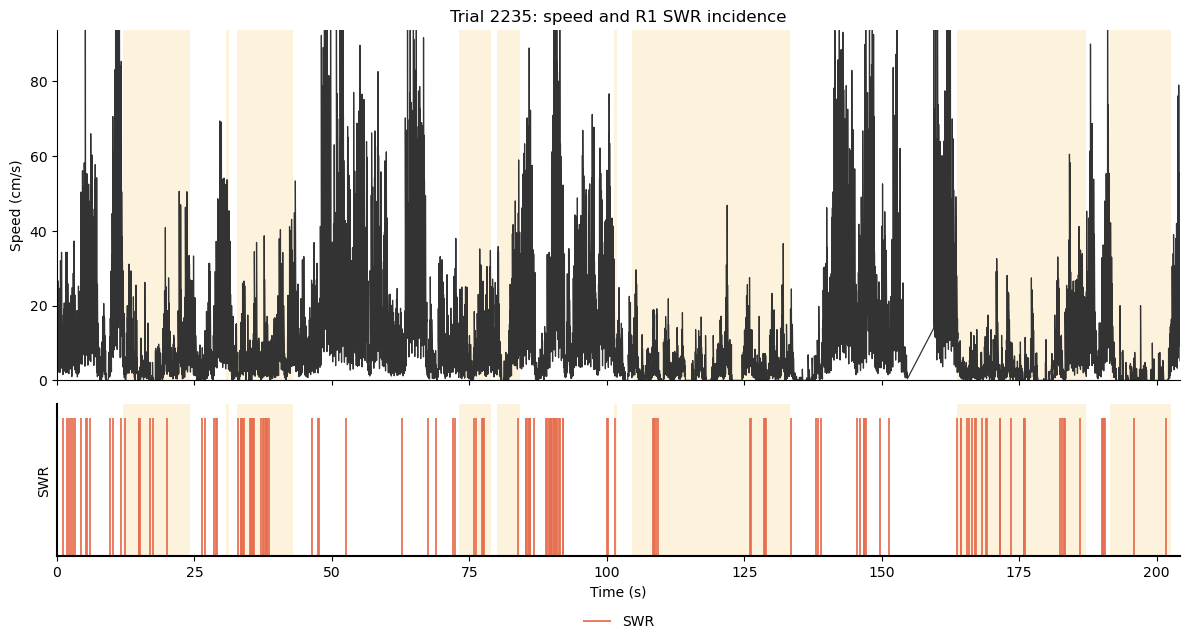

Channel used: R1
Number of SWRs plotted: 141
Number of inside_roi trains: 11
Board scaling applied to distance/speed: x1.2
Speed smoothing: method=none, window=11, std=3.0
condition
STIM         72
NEAR_STIM    55
STIM_OFF     14
Name: count, dtype: int64


In [196]:
# speed plot with SWR as separate panel 

# ------------------------------------------------------------
# Load trial data
# ------------------------------------------------------------
PLOT_SWR_IN_ONE_COLOUR = True   # False = use condition colors
BOARD_SCALE_TO_REAL = 1.2        # analysis board 100 -> real board 120 cm

# ----------------------------
# Speed smoothing options
# ----------------------------
SPEED_SMOOTH_METHOD = "none"   # "none", "median", "mean", "gaussian"
SPEED_SMOOTH_WINDOW = 11           # odd number recommended
SPEED_SMOOTH_STD = 3.0             # only used for gaussian

metadata = util.load_metadata()
row_idx = 2235
dl = DataLoader(metadata.iloc[row_idx])

position = dl.get_data("position")

print("metadata row:", row_idx)
print("DataLoader:", dl.id, dl.ses_dir)

# ------------------------------------------------------------
# Choose SWR channel from wavelet results
# ------------------------------------------------------------
CHANNEL_TO_PLOT = "R1"

if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()

# remove artifact events
if "condition" in events_df.columns:
    events_df = events_df[events_df["condition"] != "ARTIFACT"].copy()

# ------------------------------------------------------------
# Prepare position time axis
# ------------------------------------------------------------
if "t" not in position.columns:
    raise ValueError("position dataframe does not contain column 't'.")

t_all = position["t"].values.astype(float)

# convert ms -> s if needed
dt_guess = np.nanmedian(np.diff(t_all)) if len(t_all) > 1 else np.nan
if np.isfinite(dt_guess) and dt_guess > 1.0:
    t_all = t_all / 1000.0

x_all = position["x"].values.astype(float)
y_all = position["y"].values.astype(float)

if "inside_roi" not in position.columns:
    raise ValueError("position dataframe does not contain column 'inside_roi'.")

inside_raw = position["inside_roi"]
if inside_raw.dtype == bool:
    inside_all = inside_raw.to_numpy(dtype=bool)
else:
    inside_all = inside_raw.astype(str).str.upper().isin(["TRUE", "1", "T", "YES"]).to_numpy(dtype=bool)

ok = np.isfinite(t_all) & np.isfinite(x_all) & np.isfinite(y_all)
t = t_all[ok]
x = x_all[ok]
y = y_all[ok]
inside_roi = inside_all[ok]

if len(t) < 2:
    raise ValueError("Not enough valid position samples to compute speed.")

# ------------------------------------------------------------
# Compute speed
# x/y are on 100 x 100 analysis board, so multiply distances by 1.2
# to reflect real 120 cm cheeseboard.
# Resulting speed unit: cm/s
# ------------------------------------------------------------
dx = np.diff(x)
dy = np.diff(y)
dt = np.diff(t)

valid_step = np.isfinite(dx) & np.isfinite(dy) & np.isfinite(dt) & (dt > 0)
speed = np.full(len(t), np.nan, dtype=float)

step_dist_analysis = np.sqrt(dx**2 + dy**2)
step_dist_real_cm = step_dist_analysis * BOARD_SCALE_TO_REAL

step_speed = np.full_like(step_dist_real_cm, np.nan, dtype=float)
step_speed[valid_step] = step_dist_real_cm[valid_step] / dt[valid_step]

# assign speed to interval end sample
speed[1:] = step_speed

# ------------------------------------------------------------
# Optional speed smoothing
# ------------------------------------------------------------
def smooth_speed(speed_arr, method="gaussian", window=11, std=2.0):
    s = pd.Series(speed_arr)

    if method == "none":
        return s.to_numpy()

    if method == "median":
        return s.rolling(window=window, center=True, min_periods=1).median().to_numpy()

    if method == "mean":
        return s.rolling(window=window, center=True, min_periods=1).mean().to_numpy()

    if method == "gaussian":
        # fallback to mean if gaussian win_type is unavailable
        try:
            return (
                s.rolling(
                    window=window,
                    center=True,
                    min_periods=1,
                    win_type="gaussian"
                )
                .mean(std=std)
                .to_numpy()
            )
        except Exception:
            return s.rolling(window=window, center=True, min_periods=1).mean().to_numpy()

    raise ValueError("SPEED_SMOOTH_METHOD must be one of: 'none', 'median', 'mean', 'gaussian'")

speed_plot = smooth_speed(
    speed_arr=speed,
    method=SPEED_SMOOTH_METHOD,
    window=SPEED_SMOOTH_WINDOW,
    std=SPEED_SMOOTH_STD
)

# ------------------------------------------------------------
# Build inside_roi trains
# Rule:
# - train starts at inside_roi True onset
# - train ends if no more inside_roi True in the next 0.6 s
# ------------------------------------------------------------
GAP_S = 0.6

inside_times = t[inside_roi]

inside_roi_trains = []
if len(inside_times) > 0:
    train_start = float(inside_times[0])
    last_true_t = float(inside_times[0])

    for cur_t in inside_times[1:]:
        cur_t = float(cur_t)
        if (cur_t - last_true_t) > GAP_S:
            inside_roi_trains.append((train_start, last_true_t))
            train_start = cur_t
        last_true_t = cur_t

    inside_roi_trains.append((train_start, last_true_t))

inside_roi_trains = [(s, e if e > s else s + 1e-6) for s, e in inside_roi_trains]

# ------------------------------------------------------------
# Keep SWR events within this position time range
# ------------------------------------------------------------
if len(events_df):
    events_df = events_df[
        (events_df["peak_time_s"] >= t.min()) &
        (events_df["peak_time_s"] <= t.max())
    ].copy()

cond_colors = {
    "STIM": "tab:red",
    "PRE_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

# publication-style one-colour SWR option
SWR_ONE_COLOUR = "#e76f51"   # coral red

ROI_SHADE_COLOR = "#f6c453"   # faded orange-yellow
ROI_SHADE_ALPHA = 0.2

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(12, 6.5), sharex=True,
    gridspec_kw={"height_ratios": [2.3, 1.0]}
)

# ----------------------------
# Top: speed
# ----------------------------
for s, e in inside_roi_trains:
    ax0.axvspan(
        s, e,
        color=ROI_SHADE_COLOR,
        alpha=ROI_SHADE_ALPHA,
        lw=0,
    )

ax0.plot(t, speed_plot, lw=0.9, color="0.2")
ax0.set_ylabel("Speed (cm/s)")
ax0.set_title(f"Trial {row_idx}: speed and R1 SWR incidence")
ax0.spines["top"].set_visible(False)
ax0.spines["right"].set_visible(False)

speed_valid = speed_plot[np.isfinite(speed_plot)]
if speed_valid.size:
    lo, hi = np.percentile(speed_valid, [1, 99])
    pad = 0.08 * (hi - lo + 1e-9)
    ax0.set_ylim(max(0, lo - pad), hi + pad)

# ----------------------------
# Bottom: SWR incidence
# ----------------------------
for s, e in inside_roi_trains:
    ax1.axvspan(
        s, e,
        color=ROI_SHADE_COLOR,
        alpha=ROI_SHADE_ALPHA,
        lw=0
    )

legend_done = set()

if len(events_df):

    if PLOT_SWR_IN_ONE_COLOUR:
        ax1.vlines(
            events_df["peak_time_s"].to_numpy(),
            ymin=0,
            ymax=1,
            color=SWR_ONE_COLOUR,
            linewidth=1.4,
            alpha=0.9,
            label="SWR"
        )

    else:
        for cond in ["STIM_OFF", "PRE_STIM", "STIM"]:
            if "condition" in events_df.columns:
                d = events_df[events_df["condition"] == cond]
            else:
                d = events_df.copy()

            if len(d):
                ax1.vlines(
                    d["peak_time_s"].to_numpy(),
                    ymin=0,
                    ymax=1,
                    color=cond_colors.get(cond, "gray"),
                    linewidth=1.4,
                    alpha=0.8,
                    label=cond if cond not in legend_done else None
                )
                legend_done.add(cond)

ax1.set_ylim(0, 1.1)
ax1.set_yticks([])
ax1.set_ylabel("SWR")
ax1.set_xlabel("Time (s)")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_linewidth(1.5)
ax1.spines["bottom"].set_linewidth(1.5)

if PLOT_SWR_IN_ONE_COLOUR:
    ax1.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=1)
else:
    if len(legend_done):
        ax1.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3)

ax1.set_xlim(t.min(), t.max())

plt.tight_layout()
plt.show()

print(f"Channel used: {CHANNEL_TO_PLOT}")
print(f"Number of SWRs plotted: {len(events_df)}")
print(f"Number of inside_roi trains: {len(inside_roi_trains)}")
print(f"Board scaling applied to distance/speed: x{BOARD_SCALE_TO_REAL}")
print(f"Speed smoothing: method={SPEED_SMOOTH_METHOD}, window={SPEED_SMOOTH_WINDOW}, std={SPEED_SMOOTH_STD}")
if "condition" in events_df.columns and len(events_df):
    print(events_df["condition"].value_counts(dropna=False))

metadata row: 2235
DataLoader: AO ses-33_date-20250924


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/1512520017.py:541: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


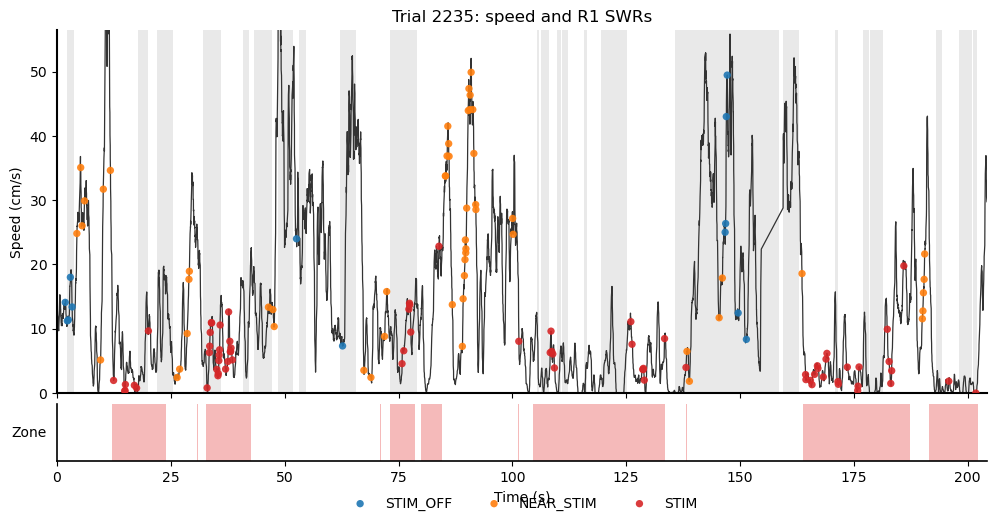

Channel used: R1
Theta channel used: R1
Condition column used: condition_stim_near
Number of SWRs plotted: 140
Number of theta bouts plotted (raw): 34
Number of theta intervals plotted (merged): 25
Hide events in artifact periods: True
Shading source: ttl_trains
Show reward-zone shade on main panel: False
Show separate reward-zone panel: True
Number of shaded intervals: 11
Board scaling applied to distance/speed: x1.2
Speed smoothing: method=gaussian, window=11, std=3.0
condition_stim_near
STIM         72
NEAR_STIM    55
STIM_OFF     13
Name: count, dtype: int64


In [300]:
# speed plot with optional SWR dots, theta shading,
# and optional separate reward-zone panel
# theta bouts are merged before plotting so grey bars do not overlap visually

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
row_idx = 2235
CHANNEL_TO_PLOT = "R1"
THETA_CHANNEL_TO_PLOT = "R1"

PLOT_SWR_IN_ONE_COLOUR = False   # False = use condition colors
BOARD_SCALE_TO_REAL = 1.2        # analysis board 100 -> real board 120 cm

# ------------------------------------------------------------
# Choose which SWR condition system to use
# options:
#   "condition_stim_near" -> STIM / NEAR_STIM / STIM_OFF
#   "condition_pre_post"  -> STIM / PRE_STIM / POST_STIM / STIM_OFF
# ------------------------------------------------------------
CONDITION_COLUMN = "condition_stim_near"

# ------------------------------------------------------------
# What to display
# ------------------------------------------------------------
SHOW_SWR = True
SHOW_THETA = True

# True -> hide SWR/theta events/bouts that overlap artifact periods
# False -> keep them
HIDE_EVENTS_IN_ARTIFACT = True

# ------------------------------------------------------------
# Behavioural / reward-zone shading options
# ------------------------------------------------------------
SHOW_SHADE = True
SHADE_SOURCE = "ttl_trains"      # "inside_roi" or "ttl_trains"
INSIDE_ROI_GAP_S = 0.6           # only used if SHADE_SOURCE == "inside_roi"

SHOW_REWARD_ZONE_SHADE_ON_MAIN = False
SHOW_REWARD_ZONE_PANEL = True

ROI_SHADE_COLOR = "#f6c453"
ROI_SHADE_ALPHA = 0.2

# separate lower reward-zone panel appearance
REWARD_PANEL_COLOR = "#f2a3a3"   # faded pink-red, similar family to stim red
REWARD_PANEL_ALPHA = 0.75

# ------------------------------------------------------------
# Theta shading options
# ------------------------------------------------------------
THETA_SHADE_COLOR = "#d0d0d0"
THETA_SHADE_ALPHA = 0.45
THETA_MERGE_GAP_S = 0.0   # increase slightly if you want tiny gaps merged too

# ----------------------------
# Speed smoothing options
# ----------------------------
SPEED_SMOOTH_METHOD = "gaussian"   # "none", "median", "mean", "gaussian"
SPEED_SMOOTH_WINDOW = 11           # odd number recommended
SPEED_SMOOTH_STD = 3.0             # only used for gaussian

# ------------------------------------------------------------
# Load trial data
# ------------------------------------------------------------
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[row_idx])

position = dl.get_data("position")

print("metadata row:", row_idx)
print("DataLoader:", dl.id, dl.ses_dir)

# ------------------------------------------------------------
# Choose SWR channel from wavelet results
# ------------------------------------------------------------
if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()
artifact_mask_swr = np.asarray(all_results[CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)
t_swr = np.asarray(all_results[CHANNEL_TO_PLOT]["det_res"]["t"], dtype=float)

if CONDITION_COLUMN not in events_df.columns:
    raise ValueError(
        f"{CONDITION_COLUMN} not found in events_df. "
        f"Available columns: {list(events_df.columns)}"
    )

events_df = events_df[events_df[CONDITION_COLUMN] != "ARTIFACT"].copy()

# ------------------------------------------------------------
# Theta channel
# ------------------------------------------------------------
theta_events_df = pd.DataFrame()
artifact_mask_theta = None
t_theta = None

if SHOW_THETA:
    if THETA_CHANNEL_TO_PLOT not in all_results_theta:
        raise ValueError(
            f"{THETA_CHANNEL_TO_PLOT} not found in all_results_theta. "
            f"Available: {list(all_results_theta.keys())}"
        )

    theta_events_df = all_results_theta[THETA_CHANNEL_TO_PLOT]["events_df"].copy()
    artifact_mask_theta = np.asarray(all_results_theta[THETA_CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)
    t_theta = np.asarray(all_results_theta[THETA_CHANNEL_TO_PLOT]["det_res"]["t"], dtype=float)

    for c in ["condition", "condition_stim_near", "condition_pre_post"]:
        if c in theta_events_df.columns:
            theta_events_df = theta_events_df[theta_events_df[c] != "ARTIFACT"].copy()

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def smooth_speed(speed_arr, method="gaussian", window=11, std=2.0):
    s = pd.Series(speed_arr)

    if method == "none":
        return s.to_numpy()

    if method == "median":
        return s.rolling(window=window, center=True, min_periods=1).median().to_numpy()

    if method == "mean":
        return s.rolling(window=window, center=True, min_periods=1).mean().to_numpy()

    if method == "gaussian":
        try:
            return (
                s.rolling(
                    window=window,
                    center=True,
                    min_periods=1,
                    win_type="gaussian"
                )
                .mean(std=std)
                .to_numpy()
            )
        except Exception:
            return s.rolling(window=window, center=True, min_periods=1).mean().to_numpy()

    raise ValueError("SPEED_SMOOTH_METHOD must be one of: 'none', 'median', 'mean', 'gaussian'")

def build_artifact_intervals_from_mask(mask_bool, t_axis):
    mask_bool = np.asarray(mask_bool, dtype=bool)
    t_axis = np.asarray(t_axis, dtype=float)

    if len(mask_bool) != len(t_axis):
        raise ValueError("artifact mask length does not match time axis length")

    if len(t_axis) < 2 or not np.any(mask_bool):
        return []

    starts = np.where(np.diff(np.r_[0, mask_bool.astype(int)]) == 1)[0]
    ends = np.where(np.diff(np.r_[mask_bool.astype(int), 0]) == -1)[0]

    dt_med = np.nanmedian(np.diff(t_axis))
    intervals = []

    for s_idx, e_idx in zip(starts, ends):
        s_t = float(t_axis[s_idx])
        if e_idx < len(t_axis):
            e_t = float(t_axis[e_idx])
        else:
            e_t = float(t_axis[-1] + dt_med)
        if e_t > s_t:
            intervals.append((s_t, e_t))

    return intervals

def interval_overlaps_any(s, e, intervals):
    for a, b in intervals:
        if (e > a) and (s < b):
            return True
    return False

def add_artifact_overlap_flag(df, intervals, start_col="start_s", end_col="end_s", peak_col="peak_time_s"):
    out = df.copy()
    if len(out) == 0:
        out["_artifact_overlap"] = pd.Series(dtype=bool)
        return out

    flags = []
    for _, ev in out.iterrows():
        s = float(ev[start_col]) if start_col in out.columns else float(ev[peak_col])
        e = float(ev[end_col]) if end_col in out.columns else float(ev[peak_col])
        pk = float(ev[peak_col])
        is_art = interval_overlaps_any(pk, pk + 1e-12, intervals) or interval_overlaps_any(s, e, intervals)
        flags.append(is_art)

    out["_artifact_overlap"] = np.asarray(flags, dtype=bool)
    return out

def merge_intervals(intervals, gap_s=0.0):
    """
    Merge overlapping or nearly touching intervals.
    """
    if len(intervals) == 0:
        return []

    intervals = sorted(
        [(float(s), float(e)) for s, e in intervals if np.isfinite(s) and np.isfinite(e) and e > s],
        key=lambda z: z[0]
    )
    if len(intervals) == 0:
        return []

    merged = [intervals[0]]
    for s, e in intervals[1:]:
        last_s, last_e = merged[-1]
        if s <= (last_e + gap_s):
            merged[-1] = (last_s, max(last_e, e))
        else:
            merged.append((s, e))

    return merged

# ------------------------------------------------------------
# Prepare position time axis
# ------------------------------------------------------------
if "t" not in position.columns:
    raise ValueError("position dataframe does not contain column 't'.")

t_all = position["t"].values.astype(float)

dt_guess = np.nanmedian(np.diff(t_all)) if len(t_all) > 1 else np.nan
if np.isfinite(dt_guess) and dt_guess > 1.0:
    t_all = t_all / 1000.0

x_all = position["x"].values.astype(float)
y_all = position["y"].values.astype(float)

if "inside_roi" not in position.columns:
    raise ValueError("position dataframe does not contain column 'inside_roi'.")

inside_raw = position["inside_roi"]
if inside_raw.dtype == bool:
    inside_all = inside_raw.to_numpy(dtype=bool)
else:
    inside_all = inside_raw.astype(str).str.upper().isin(["TRUE", "1", "T", "YES"]).to_numpy(dtype=bool)

ok = np.isfinite(t_all) & np.isfinite(x_all) & np.isfinite(y_all)
t = t_all[ok]
x = x_all[ok]
y = y_all[ok]
inside_roi = inside_all[ok]

if len(t) < 2:
    raise ValueError("Not enough valid position samples to compute speed.")

# ------------------------------------------------------------
# Compute speed
# ------------------------------------------------------------
dx = np.diff(x)
dy = np.diff(y)
dt = np.diff(t)

valid_step = np.isfinite(dx) & np.isfinite(dy) & np.isfinite(dt) & (dt > 0)
speed = np.full(len(t), np.nan, dtype=float)

step_dist_analysis = np.sqrt(dx**2 + dy**2)
step_dist_real_cm = step_dist_analysis * BOARD_SCALE_TO_REAL

step_speed = np.full_like(step_dist_real_cm, np.nan, dtype=float)
step_speed[valid_step] = step_dist_real_cm[valid_step] / dt[valid_step]

speed[1:] = step_speed

speed_plot = smooth_speed(
    speed_arr=speed,
    method=SPEED_SMOOTH_METHOD,
    window=SPEED_SMOOTH_WINDOW,
    std=SPEED_SMOOTH_STD
)

# ------------------------------------------------------------
# Build reward-zone / TTL shading intervals
# ------------------------------------------------------------
shade_intervals = []

if SHADE_SOURCE == "inside_roi":
    inside_times = t[inside_roi]

    if len(inside_times) > 0:
        train_start = float(inside_times[0])
        last_true_t = float(inside_times[0])

        for cur_t in inside_times[1:]:
            cur_t = float(cur_t)
            if (cur_t - last_true_t) > INSIDE_ROI_GAP_S:
                shade_intervals.append((train_start, last_true_t))
                train_start = cur_t
            last_true_t = cur_t

        shade_intervals.append((train_start, last_true_t))

    shade_intervals = [(s, e if e > s else s + 1e-6) for s, e in shade_intervals]

elif SHADE_SOURCE == "ttl_trains":
    if "stim_trains_table" not in globals():
        raise ValueError(
            "SHADE_SOURCE='ttl_trains' requires stim_trains_table from your TTL code."
        )

    if not isinstance(stim_trains_table, pd.DataFrame):
        raise ValueError("stim_trains_table exists but is not a pandas DataFrame.")

    required_cols = {"start_s", "end_s"}
    if not required_cols.issubset(stim_trains_table.columns):
        raise ValueError(
            f"stim_trains_table must contain columns {required_cols}. "
            f"Found: {list(stim_trains_table.columns)}"
        )

    for _, rr in stim_trains_table.iterrows():
        s = float(rr["start_s"])
        e = float(rr["end_s"])

        if e < t.min() or s > t.max():
            continue

        s_clip = max(s, float(t.min()))
        e_clip = min(e, float(t.max()))

        if e_clip > s_clip:
            shade_intervals.append((s_clip, e_clip))

else:
    raise ValueError("SHADE_SOURCE must be 'inside_roi' or 'ttl_trains'")

# ------------------------------------------------------------
# Artifact intervals
# ------------------------------------------------------------
artifact_intervals = build_artifact_intervals_from_mask(artifact_mask_swr, t_swr)

if SHOW_THETA and artifact_mask_theta is not None:
    artifact_intervals += build_artifact_intervals_from_mask(artifact_mask_theta, t_theta)

# ------------------------------------------------------------
# Keep SWR events within this position time range
# ------------------------------------------------------------
if len(events_df):
    events_df = events_df[
        (events_df["peak_time_s"] >= t.min()) &
        (events_df["peak_time_s"] <= t.max())
    ].copy()

if HIDE_EVENTS_IN_ARTIFACT and len(events_df):
    events_df = add_artifact_overlap_flag(events_df, artifact_intervals)
    events_df = events_df[~events_df["_artifact_overlap"]].copy()

# ------------------------------------------------------------
# Keep theta bouts within this position time range
# ------------------------------------------------------------
if SHOW_THETA and len(theta_events_df):
    theta_events_df = theta_events_df[
        (theta_events_df["end_s"] >= t.min()) &
        (theta_events_df["start_s"] <= t.max())
    ].copy()

    if HIDE_EVENTS_IN_ARTIFACT:
        theta_events_df = add_artifact_overlap_flag(theta_events_df, artifact_intervals)
        theta_events_df = theta_events_df[~theta_events_df["_artifact_overlap"]].copy()

# ------------------------------------------------------------
# Merge theta bouts before plotting so grey bars do not overlap
# ------------------------------------------------------------
theta_intervals_merged = []
if SHOW_THETA and len(theta_events_df):
    theta_intervals_raw = [
        (float(ev["start_s"]), float(ev["end_s"]))
        for _, ev in theta_events_df.iterrows()
    ]
    theta_intervals_merged = merge_intervals(theta_intervals_raw, gap_s=THETA_MERGE_GAP_S)

# ------------------------------------------------------------
# Map SWR times to speed values
# ------------------------------------------------------------
if len(events_df):
    swr_t = events_df["peak_time_s"].to_numpy(dtype=float)

    idx = np.searchsorted(t, swr_t)
    idx = np.clip(idx, 0, len(t) - 1)

    idx_prev = np.clip(idx - 1, 0, len(t) - 1)
    use_prev = np.abs(t[idx_prev] - swr_t) < np.abs(t[idx] - swr_t)
    idx[use_prev] = idx_prev[use_prev]

    events_df["speed_at_swr"] = speed_plot[idx]

# ------------------------------------------------------------
# Colours/order
# ------------------------------------------------------------
cond_colors = {
    "STIM": "tab:red",
    "NEAR_STIM": "tab:orange",
    "PRE_STIM": "tab:orange",
    "POST_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

if CONDITION_COLUMN == "condition_stim_near":
    cond_order = ["STIM_OFF", "NEAR_STIM", "STIM"]
elif CONDITION_COLUMN == "condition_pre_post":
    cond_order = ["STIM_OFF", "PRE_STIM", "POST_STIM", "STIM"]
else:
    cond_order = [c for c in ["STIM_OFF", "NEAR_STIM", "PRE_STIM", "POST_STIM", "STIM"] if c in events_df[CONDITION_COLUMN].unique()]

SWR_ONE_COLOUR = "#e76f51"

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
if SHOW_REWARD_ZONE_PANEL:
    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(12, 5.6), sharex=True,
        gridspec_kw={"height_ratios": [4.4, 0.7], "hspace": 0.05}
    )
else:
    fig, ax = plt.subplots(figsize=(12, 4.8))
    axr = None

# ------------------------------------------------------------
# Main panel
# ------------------------------------------------------------
if SHOW_SHADE and SHOW_REWARD_ZONE_SHADE_ON_MAIN:
    for s, e in shade_intervals:
        ax.axvspan(
            s, e,
            color=ROI_SHADE_COLOR,
            alpha=ROI_SHADE_ALPHA,
            lw=0,
        )

if SHOW_THETA and len(theta_intervals_merged):
    for s, e in theta_intervals_merged:
        ax.axvspan(
            s,
            e,
            color=THETA_SHADE_COLOR,
            alpha=THETA_SHADE_ALPHA,
            lw=0,
            zorder=0.5
        )

# speed trace
ax.plot(t, speed_plot, lw=0.9, color="0.2")

# SWR dots
legend_done = set()

if SHOW_SWR and len(events_df):
    if PLOT_SWR_IN_ONE_COLOUR:
        ax.scatter(
            events_df["peak_time_s"].to_numpy(),
            events_df["speed_at_swr"].to_numpy(),
            s=28,
            color=SWR_ONE_COLOUR,
            edgecolors="none",
            linewidths=0,
            alpha=0.9,
            zorder=5,
            label="SWR"
        )
    else:
        for cond in cond_order:
            d = events_df[events_df[CONDITION_COLUMN] == cond]
            if len(d):
                ax.scatter(
                    d["peak_time_s"].to_numpy(),
                    d["speed_at_swr"].to_numpy(),
                    s=28,
                    color=cond_colors.get(cond, "gray"),
                    edgecolors="none",
                    linewidths=0,
                    alpha=0.9,
                    zorder=5,
                    label=cond if cond not in legend_done else None
                )
                legend_done.add(cond)

ax.set_ylabel("Speed (cm/s)")
ax.set_title(f"Trial {row_idx}: speed and {CHANNEL_TO_PLOT} SWRs")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

speed_valid = speed_plot[np.isfinite(speed_plot)]
if speed_valid.size:
    lo, hi = np.percentile(speed_valid, [1, 99])
    pad = 0.08 * (hi - lo + 1e-9)
    ax.set_ylim(max(0, lo - pad), hi + pad)

ax.set_xlim(t.min(), t.max())

# ------------------------------------------------------------
# Reward-zone panel
# ------------------------------------------------------------
if SHOW_REWARD_ZONE_PANEL:
    axr.set_ylim(0, 1)
    axr.set_yticks([])
    axr.set_ylabel("Zone", rotation=0, labelpad=20, va="center")

    if SHOW_SHADE:
        for s, e in shade_intervals:
            axr.axvspan(
                s, e,
                color=REWARD_PANEL_COLOR,
                alpha=REWARD_PANEL_ALPHA,
                lw=0
            )

    axr.spines["top"].set_visible(False)
    axr.spines["right"].set_visible(False)
    axr.spines["left"].set_linewidth(1.2)
    axr.spines["bottom"].set_linewidth(1.2)
    axr.set_xlabel("Time (s)")
else:
    ax.set_xlabel("Time (s)")

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
if SHOW_SWR:
    if PLOT_SWR_IN_ONE_COLOUR:
        ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=1)
    else:
        handles, labels = ax.get_legend_handles_labels()
        if len(labels):
            ncol = 3 if len(labels) <= 3 else 4
            ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=ncol)

plt.tight_layout()
plt.show()

print(f"Channel used: {CHANNEL_TO_PLOT}")
print(f"Theta channel used: {THETA_CHANNEL_TO_PLOT}")
print(f"Condition column used: {CONDITION_COLUMN}")
print(f"Number of SWRs plotted: {len(events_df)}")
print(f"Number of theta bouts plotted (raw): {len(theta_events_df) if SHOW_THETA else 0}")
print(f"Number of theta intervals plotted (merged): {len(theta_intervals_merged) if SHOW_THETA else 0}")
print(f"Hide events in artifact periods: {HIDE_EVENTS_IN_ARTIFACT}")
print(f"Shading source: {SHADE_SOURCE}")
print(f"Show reward-zone shade on main panel: {SHOW_REWARD_ZONE_SHADE_ON_MAIN}")
print(f"Show separate reward-zone panel: {SHOW_REWARD_ZONE_PANEL}")
print(f"Number of shaded intervals: {len(shade_intervals)}")
print(f"Board scaling applied to distance/speed: x{BOARD_SCALE_TO_REAL}")
print(f"Speed smoothing: method={SPEED_SMOOTH_METHOD}, window={SPEED_SMOOTH_WINDOW}, std={SPEED_SMOOTH_STD}")

if len(events_df):
    print(events_df[CONDITION_COLUMN].value_counts(dropna=False))

metadata row: 2235
DataLoader: AO ses-33_date-20250924


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/238250249.py:478: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


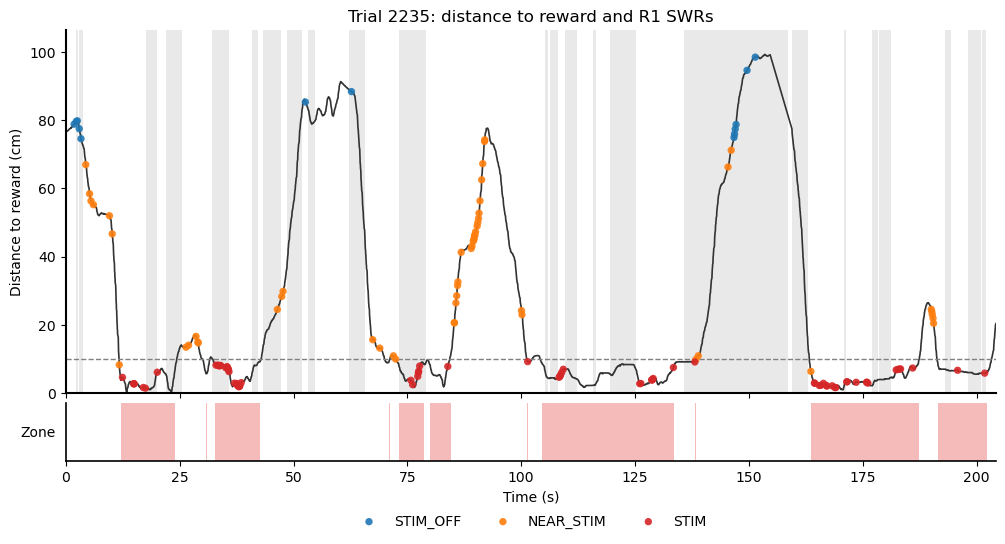

Channel used: R1
Theta channel used: R1
Condition column used: condition_stim_near
Trigger plotted: 2
Number of SWRs plotted: 140
Number of theta bouts plotted (raw): 34
Number of theta intervals plotted (merged): 25
Hide events in artifact periods: True
Shading source: ttl_trains
Show reward-zone shade on main panel: False
Show separate reward-zone panel: True
Number of shaded intervals: 11
Board scaling applied to distance: x1.2
condition_stim_near
STIM         72
NEAR_STIM    55
STIM_OFF     13
Name: count, dtype: int64


In [299]:
# distance-to-reward plot with optional SWR dots, theta shading,
# and optional separate reward-zone panel
# theta bouts are merged before plotting so grey bars do not overlap visually

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
row_idx = 2235
CHANNEL_TO_PLOT = "R1"
THETA_CHANNEL_TO_PLOT = "R1"
TRIGGER_TO_PLOT = 2
BOARD_SCALE_TO_REAL = 1.2

CONDITION_COLUMN = "condition_stim_near"

SHOW_SWR = True
SHOW_THETA = True
HIDE_EVENTS_IN_ARTIFACT = True

PLOT_SWR_IN_ONE_COLOUR = False
SWR_ONE_COLOUR = "#e76f51"

# reward-zone display
SHOW_SHADE = True
SHADE_SOURCE = "ttl_trains"      # "inside_roi" or "ttl_trains"
INSIDE_ROI_GAP_S = 0.6

SHOW_REWARD_ZONE_SHADE_ON_MAIN = False
SHOW_REWARD_ZONE_PANEL = True

ROI_SHADE_COLOR = "#f6c453"
ROI_SHADE_ALPHA = 0.2

THETA_SHADE_COLOR = "#d0d0d0"
THETA_SHADE_ALPHA = 0.45
THETA_MERGE_GAP_S = 0.0   # merge overlapping theta bouts; increase slightly if you want tiny gaps merged too

# ------------------------------------------------------------
# Load trial data
# ------------------------------------------------------------
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[row_idx])

position = dl.get_data("position")
triggerLoc = dl.get_data("triggerLoc")

print("metadata row:", row_idx)
print("DataLoader:", dl.id, dl.ses_dir)

# ------------------------------------------------------------
# SWR results
# ------------------------------------------------------------
if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()
artifact_mask_swr = np.asarray(all_results[CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)
t_swr = np.asarray(all_results[CHANNEL_TO_PLOT]["det_res"]["t"], dtype=float)

if CONDITION_COLUMN not in events_df.columns:
    raise ValueError(
        f"{CONDITION_COLUMN} not found in events_df. "
        f"Available columns: {list(events_df.columns)}"
    )

events_df = events_df[events_df[CONDITION_COLUMN] != "ARTIFACT"].copy()

# ------------------------------------------------------------
# Theta results
# ------------------------------------------------------------
theta_events_df = pd.DataFrame()
artifact_mask_theta = None
t_theta = None

if SHOW_THETA:
    if THETA_CHANNEL_TO_PLOT not in all_results_theta:
        raise ValueError(
            f"{THETA_CHANNEL_TO_PLOT} not found in all_results_theta. "
            f"Available: {list(all_results_theta.keys())}"
        )

    theta_events_df = all_results_theta[THETA_CHANNEL_TO_PLOT]["events_df"].copy()
    artifact_mask_theta = np.asarray(all_results_theta[THETA_CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)
    t_theta = np.asarray(all_results_theta[THETA_CHANNEL_TO_PLOT]["det_res"]["t"], dtype=float)

    for c in ["condition", "condition_stim_near", "condition_pre_post"]:
        if c in theta_events_df.columns:
            theta_events_df = theta_events_df[theta_events_df[c] != "ARTIFACT"].copy()

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def build_artifact_intervals_from_mask(mask_bool, t_axis):
    mask_bool = np.asarray(mask_bool, dtype=bool)
    t_axis = np.asarray(t_axis, dtype=float)

    if len(mask_bool) != len(t_axis):
        raise ValueError("artifact mask length does not match time axis length")

    if len(t_axis) < 2 or not np.any(mask_bool):
        return []

    starts = np.where(np.diff(np.r_[0, mask_bool.astype(int)]) == 1)[0]
    ends = np.where(np.diff(np.r_[mask_bool.astype(int), 0]) == -1)[0]

    dt_med = np.nanmedian(np.diff(t_axis))
    intervals = []

    for s_idx, e_idx in zip(starts, ends):
        s_t = float(t_axis[s_idx])
        if e_idx < len(t_axis):
            e_t = float(t_axis[e_idx])
        else:
            e_t = float(t_axis[-1] + dt_med)
        if e_t > s_t:
            intervals.append((s_t, e_t))

    return intervals

def interval_overlaps_any(s, e, intervals):
    for a, b in intervals:
        if (e > a) and (s < b):
            return True
    return False

def add_artifact_overlap_flag(df, intervals, start_col="start_s", end_col="end_s", peak_col="peak_time_s"):
    out = df.copy()
    if len(out) == 0:
        out["_artifact_overlap"] = pd.Series(dtype=bool)
        return out

    flags = []
    for _, ev in out.iterrows():
        s = float(ev[start_col]) if start_col in out.columns else float(ev[peak_col])
        e = float(ev[end_col]) if end_col in out.columns else float(ev[peak_col])
        pk = float(ev[peak_col])
        is_art = interval_overlaps_any(pk, pk + 1e-12, intervals) or interval_overlaps_any(s, e, intervals)
        flags.append(is_art)

    out["_artifact_overlap"] = np.asarray(flags, dtype=bool)
    return out

def merge_intervals(intervals, gap_s=0.0):
    """
    Merge overlapping or nearly-touching intervals.
    """
    if len(intervals) == 0:
        return []

    intervals = sorted(
        [(float(s), float(e)) for s, e in intervals if np.isfinite(s) and np.isfinite(e) and e > s],
        key=lambda z: z[0]
    )
    if len(intervals) == 0:
        return []

    merged = [intervals[0]]
    for s, e in intervals[1:]:
        last_s, last_e = merged[-1]
        if s <= (last_e + gap_s):
            merged[-1] = (last_s, max(last_e, e))
        else:
            merged.append((s, e))

    return merged

# ------------------------------------------------------------
# Prepare position time axis
# ------------------------------------------------------------
if "t" not in position.columns:
    raise ValueError("position dataframe does not contain column 't'.")

t_all = position["t"].values.astype(float)

dt_guess = np.nanmedian(np.diff(t_all)) if len(t_all) > 1 else np.nan
if np.isfinite(dt_guess) and dt_guess > 1.0:
    t_all = t_all / 1000.0

x_all = position["x"].values.astype(float)
y_all = position["y"].values.astype(float)

if "inside_roi" not in position.columns:
    raise ValueError("position dataframe does not contain column 'inside_roi'.")

inside_raw = position["inside_roi"]
if inside_raw.dtype == bool:
    inside_all = inside_raw.to_numpy(dtype=bool)
else:
    inside_all = inside_raw.astype(str).str.upper().isin(["TRUE", "1", "T", "YES"]).to_numpy(dtype=bool)

ok = np.isfinite(t_all) & np.isfinite(x_all) & np.isfinite(y_all)
t = t_all[ok]
x = x_all[ok]
y = y_all[ok]
inside_roi = inside_all[ok]

if len(t) < 2:
    raise ValueError("Not enough valid position samples.")

# ------------------------------------------------------------
# Distance to trigger
# ------------------------------------------------------------
if triggerLoc is None or len(triggerLoc) < TRIGGER_TO_PLOT:
    raise ValueError(f"triggerLoc does not contain trigger {TRIGGER_TO_PLOT}")

pos_dist = add_dist_to_trigger(position.copy(), triggerLoc)
dist_col = f"dist_to_trigger_{TRIGGER_TO_PLOT}"

if dist_col not in pos_dist.columns:
    raise ValueError(f"{dist_col} not found after add_dist_to_trigger()")

dist_all = pos_dist[dist_col].values.astype(float) * BOARD_SCALE_TO_REAL
dist = dist_all[ok]

# ------------------------------------------------------------
# Reward-zone / TTL shading intervals
# ------------------------------------------------------------
shade_intervals = []

if SHADE_SOURCE == "inside_roi":
    inside_times = t[inside_roi]

    if len(inside_times) > 0:
        train_start = float(inside_times[0])
        last_true_t = float(inside_times[0])

        for cur_t in inside_times[1:]:
            cur_t = float(cur_t)
            if (cur_t - last_true_t) > INSIDE_ROI_GAP_S:
                shade_intervals.append((train_start, last_true_t))
                train_start = cur_t
            last_true_t = cur_t

        shade_intervals.append((train_start, last_true_t))

    shade_intervals = [(s, e if e > s else s + 1e-6) for s, e in shade_intervals]

elif SHADE_SOURCE == "ttl_trains":
    if "stim_trains_table" not in globals():
        raise ValueError(
            "SHADE_SOURCE='ttl_trains' requires stim_trains_table from your earlier TTL processing code."
        )

    if not isinstance(stim_trains_table, pd.DataFrame):
        raise ValueError("stim_trains_table exists but is not a pandas DataFrame.")

    required_cols = {"start_s", "end_s"}
    if not required_cols.issubset(stim_trains_table.columns):
        raise ValueError(
            f"stim_trains_table must contain columns {required_cols}. "
            f"Found: {list(stim_trains_table.columns)}"
        )

    for _, rr in stim_trains_table.iterrows():
        s = float(rr["start_s"])
        e = float(rr["end_s"])

        if e < t.min() or s > t.max():
            continue

        s_clip = max(s, float(t.min()))
        e_clip = min(e, float(t.max()))

        if e_clip > s_clip:
            shade_intervals.append((s_clip, e_clip))

else:
    raise ValueError("SHADE_SOURCE must be 'inside_roi' or 'ttl_trains'.")

# ------------------------------------------------------------
# Artifact intervals
# ------------------------------------------------------------
artifact_intervals = build_artifact_intervals_from_mask(artifact_mask_swr, t_swr)

if SHOW_THETA and artifact_mask_theta is not None:
    artifact_intervals += build_artifact_intervals_from_mask(artifact_mask_theta, t_theta)

# ------------------------------------------------------------
# Filter SWR events
# ------------------------------------------------------------
if len(events_df):
    events_df = events_df[
        (events_df["peak_time_s"] >= t.min()) &
        (events_df["peak_time_s"] <= t.max())
    ].copy()

    if HIDE_EVENTS_IN_ARTIFACT:
        events_df = add_artifact_overlap_flag(events_df, artifact_intervals)
        events_df = events_df[~events_df["_artifact_overlap"]].copy()

# ------------------------------------------------------------
# Filter theta events
# ------------------------------------------------------------
if SHOW_THETA and len(theta_events_df):
    theta_events_df = theta_events_df[
        (theta_events_df["end_s"] >= t.min()) &
        (theta_events_df["start_s"] <= t.max())
    ].copy()

    if HIDE_EVENTS_IN_ARTIFACT:
        theta_events_df = add_artifact_overlap_flag(theta_events_df, artifact_intervals)
        theta_events_df = theta_events_df[~theta_events_df["_artifact_overlap"]].copy()

# ------------------------------------------------------------
# Merge theta bouts before plotting so grey bars do not overlap
# ------------------------------------------------------------
theta_intervals_merged = []
if SHOW_THETA and len(theta_events_df):
    theta_intervals_raw = [
        (float(ev["start_s"]), float(ev["end_s"]))
        for _, ev in theta_events_df.iterrows()
    ]
    theta_intervals_merged = merge_intervals(theta_intervals_raw, gap_s=THETA_MERGE_GAP_S)

# ------------------------------------------------------------
# Map SWR time to distance trace
# ------------------------------------------------------------
if len(events_df):
    swr_t = events_df["peak_time_s"].to_numpy(dtype=float)

    idx = np.searchsorted(t, swr_t)
    idx = np.clip(idx, 0, len(t) - 1)

    idx_prev = np.clip(idx - 1, 0, len(t) - 1)
    use_prev = np.abs(t[idx_prev] - swr_t) < np.abs(t[idx] - swr_t)
    idx[use_prev] = idx_prev[use_prev]

    events_df["dist_to_reward_cm"] = dist[idx]

# ------------------------------------------------------------
# Colours/order
# ------------------------------------------------------------
cond_colors = {
    "STIM": "tab:red",
    "NEAR_STIM": "tab:orange",
    "PRE_STIM": "tab:orange",
    "POST_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

if CONDITION_COLUMN == "condition_stim_near":
    cond_order = ["STIM_OFF", "NEAR_STIM", "STIM"]
elif CONDITION_COLUMN == "condition_pre_post":
    cond_order = ["STIM_OFF", "PRE_STIM", "POST_STIM", "STIM"]
else:
    cond_order = [c for c in ["STIM_OFF", "NEAR_STIM", "PRE_STIM", "POST_STIM", "STIM"] if c in events_df[CONDITION_COLUMN].unique()]

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
if SHOW_REWARD_ZONE_PANEL:
    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(12, 5.6), sharex=True,
        gridspec_kw={"height_ratios": [4.4, 0.7], "hspace": 0.05}
    )
else:
    fig, ax = plt.subplots(figsize=(12, 4.8))
    axr = None

# ------------------------------------------------------------
# Main panel
# ------------------------------------------------------------
if SHOW_SHADE and SHOW_REWARD_ZONE_SHADE_ON_MAIN:
    for s, e in shade_intervals:
        ax.axvspan(
            s, e,
            color=ROI_SHADE_COLOR,
            alpha=ROI_SHADE_ALPHA,
            lw=0
        )

if SHOW_THETA and len(theta_intervals_merged):
    for s, e in theta_intervals_merged:
        ax.axvspan(
            s,
            e,
            color=THETA_SHADE_COLOR,
            alpha=THETA_SHADE_ALPHA,
            lw=0,
            zorder=0.5
        )

ax.plot(t, dist, lw=1.2, color="0.2")
ax.axhline(10, color="0.5", linestyle="--", linewidth=1.0)

legend_done = set()

if SHOW_SWR and len(events_df):
    if PLOT_SWR_IN_ONE_COLOUR:
        ax.scatter(
            events_df["peak_time_s"].to_numpy(),
            events_df["dist_to_reward_cm"].to_numpy(),
            s=28,
            color=SWR_ONE_COLOUR,
            edgecolors="none",
            linewidths=0,
            alpha=0.9,
            label="SWR",
            zorder=5
        )
    else:
        for cond in cond_order:
            d = events_df[events_df[CONDITION_COLUMN] == cond]
            if len(d):
                ax.scatter(
                    d["peak_time_s"].to_numpy(),
                    d["dist_to_reward_cm"].to_numpy(),
                    s=28,
                    color=cond_colors.get(cond, "gray"),
                    edgecolors="none",
                    linewidths=0,
                    alpha=0.9,
                    label=cond if cond not in legend_done else None,
                    zorder=5
                )
                legend_done.add(cond)

ax.set_ylabel("Distance to reward (cm)")
ax.set_title(f"Trial {row_idx}: distance to reward and {CHANNEL_TO_PLOT} SWRs")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

dist_valid = dist[np.isfinite(dist)]
if dist_valid.size:
    lo, hi = np.percentile(dist_valid, [1, 99])
    pad = 0.08 * (hi - lo + 1e-9)
    ax.set_ylim(max(0, lo - pad), hi + pad)

ax.set_xlim(t.min(), t.max())

# ------------------------------------------------------------
# Reward-zone panel
# ------------------------------------------------------------
REWARD_PANEL_COLOR = "#f2a3a3"   # faded pink-red, similar family to stim red
REWARD_PANEL_ALPHA = 0.75

if SHOW_REWARD_ZONE_PANEL:
    axr.set_ylim(0, 1)
    axr.set_yticks([])
    axr.set_ylabel("Zone", rotation=0, labelpad=20, va="center")

    if SHOW_SHADE:
        for s, e in shade_intervals:
            axr.axvspan(
                s, e,
                color=REWARD_PANEL_COLOR,
                alpha=REWARD_PANEL_ALPHA,
                lw=0
            )

    axr.spines["top"].set_visible(False)
    axr.spines["right"].set_visible(False)
    axr.spines["left"].set_linewidth(1.2)
    axr.spines["bottom"].set_linewidth(1.2)
    axr.set_xlabel("Time (s)")
else:
    ax.set_xlabel("Time (s)")

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
if SHOW_SWR:
    if PLOT_SWR_IN_ONE_COLOUR:
        ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=1)
    else:
        handles, labels = ax.get_legend_handles_labels()
        if len(labels):
            ncol = 3 if len(labels) <= 3 else 4
            ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=ncol)

plt.tight_layout()
plt.show()

print(f"Channel used: {CHANNEL_TO_PLOT}")
print(f"Theta channel used: {THETA_CHANNEL_TO_PLOT}")
print(f"Condition column used: {CONDITION_COLUMN}")
print(f"Trigger plotted: {TRIGGER_TO_PLOT}")
print(f"Number of SWRs plotted: {len(events_df)}")
print(f"Number of theta bouts plotted (raw): {len(theta_events_df) if SHOW_THETA else 0}")
print(f"Number of theta intervals plotted (merged): {len(theta_intervals_merged) if SHOW_THETA else 0}")
print(f"Hide events in artifact periods: {HIDE_EVENTS_IN_ARTIFACT}")
print(f"Shading source: {SHADE_SOURCE}")
print(f"Show reward-zone shade on main panel: {SHOW_REWARD_ZONE_SHADE_ON_MAIN}")
print(f"Show separate reward-zone panel: {SHOW_REWARD_ZONE_PANEL}")
print(f"Number of shaded intervals: {len(shade_intervals)}")
print(f"Board scaling applied to distance: x{BOARD_SCALE_TO_REAL}")

if len(events_df):
    print(events_df[CONDITION_COLUMN].value_counts(dropna=False))

/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/1761989165.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_dur.boxplot(
/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/1761989165.py:179: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_int.boxplot(


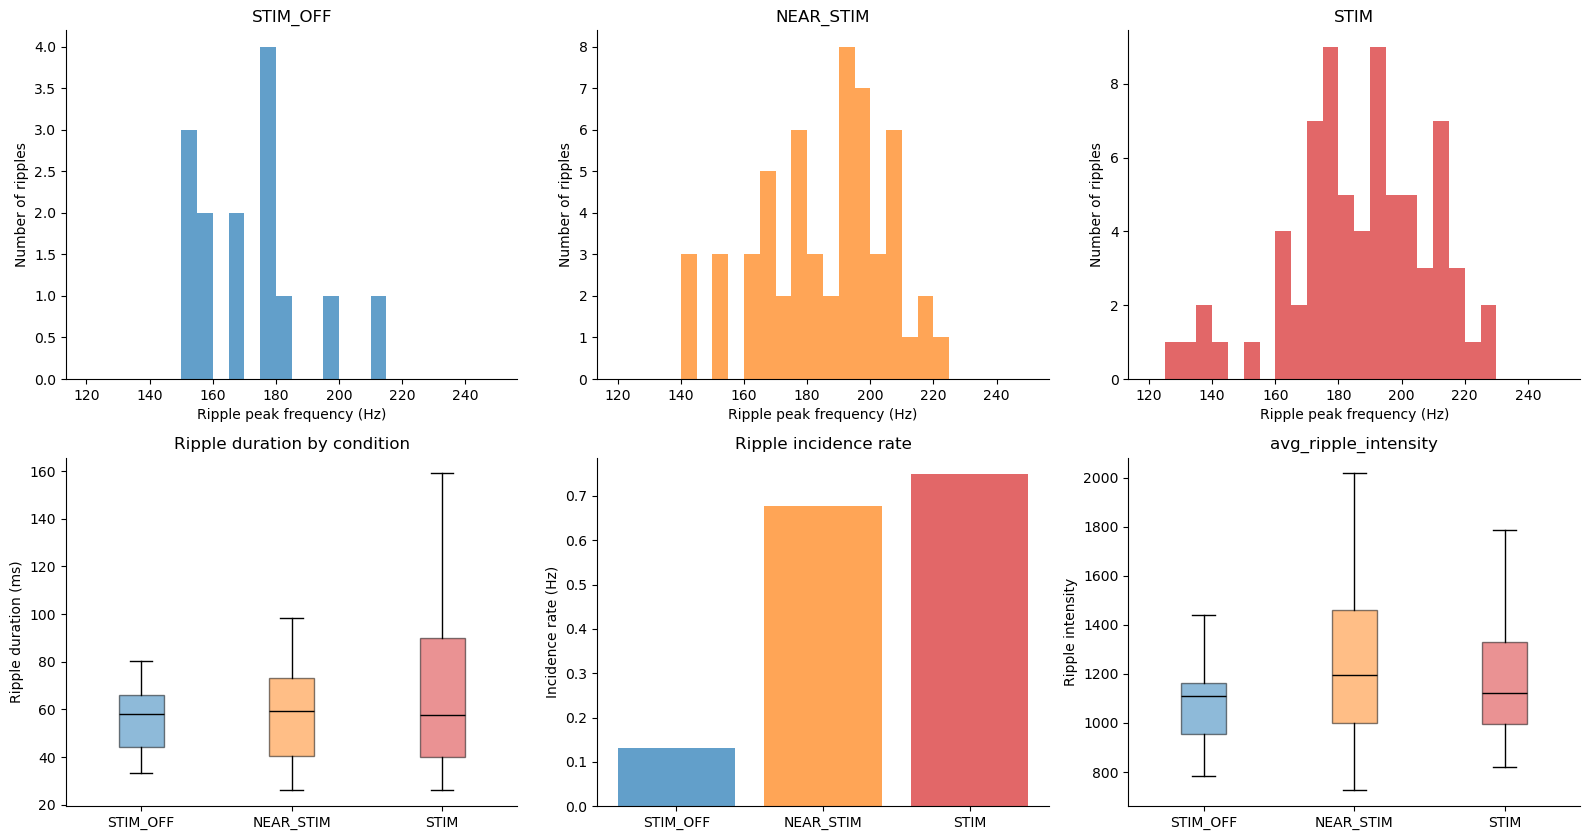

,condition,duration_s,n_events,event_rate_hz,mean_duration_ms,mean_peak_frequency_hz,mean_max_frequency_hz,mean_peak_intensity,mean_max_intensity
0,STIM,96.1500,72,0.748830,72.770833,186.924342,229.613221,1173.517284,1607.500073
1,NEAR_STIM,81.1180,55,0.678025,66.745455,184.946080,235.459148,1252.736114,1683.956918
2,STIM_OFF,106.6415,14,0.131281,58.107143,171.882731,216.030741,1108.718409,1488.894696


In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# OPTIONS
# ============================================================
CHANNEL_TO_PLOT = "R1"
CONDITION_COLUMN = "condition_stim_near"   # use stim / near_stim / stim_off system
CONDITIONS_TO_PLOT = ["STIM_OFF", "NEAR_STIM", "STIM"]

# frequency metric for histogram
# options: "avg_ripple_frequency_hz" or "max_ripple_frequency_hz"
FREQ_METRIC = "avg_ripple_frequency_hz"

# intensity metric
# options: "avg_ripple_intensity" or "max_ripple_intensity"
INTENSITY_METRIC = "avg_ripple_intensity"

# histogram bins
FREQ_BINS = np.arange(120, 251, 5)

# duration plot style
DURATION_PLOT_TYPE = "box"   # "box" or "violin"

# colours
cond_colors = {
    "STIM": "tab:red",
    "NEAR_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

# ============================================================
# LOAD DATA
# ============================================================
if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()
condition_summary = all_results[CHANNEL_TO_PLOT]["condition_summary"].copy()

if CONDITION_COLUMN not in events_df.columns:
    raise ValueError(
        f"{CONDITION_COLUMN} not found in events_df. "
        f"Available columns: {list(events_df.columns)}"
    )

if "condition_set" not in condition_summary.columns:
    raise ValueError("condition_summary does not contain 'condition_set'.")

events_plot = events_df[events_df[CONDITION_COLUMN].isin(CONDITIONS_TO_PLOT)].copy()

summary_plot = condition_summary[
    (condition_summary["condition_set"] == CONDITION_COLUMN) &
    (condition_summary["condition"].isin(CONDITIONS_TO_PLOT))
].copy()

# ============================================================
# FIGURE
# 3 separate histograms + duration + incidence + intensity
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
axes = axes.flatten()

# ============================================================
# 1-3) SEPARATE HISTOGRAMS OF RIPPLE PEAK FREQUENCY
# ============================================================
for ax, cond in zip(axes[:3], CONDITIONS_TO_PLOT):
    d = events_plot[events_plot[CONDITION_COLUMN] == cond]
    vals = d[FREQ_METRIC].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals):
        ax.hist(
            vals,
            bins=FREQ_BINS,
            color=cond_colors.get(cond, "gray"),
            alpha=0.7,
            edgecolor="none"
        )

    ax.set_title(cond)
    ax.set_xlabel("Ripple peak frequency (Hz)")
    ax.set_ylabel("Number of ripples")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================================================
# 4) RIPPLE DURATION
# ============================================================
ax_dur = axes[3]

duration_data = []
duration_labels = []
duration_colors = []

for cond in CONDITIONS_TO_PLOT:
    d = events_plot[events_plot[CONDITION_COLUMN] == cond]
    vals = d["duration_ms"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals):
        duration_data.append(vals)
        duration_labels.append(cond)
        duration_colors.append(cond_colors.get(cond, "gray"))

if len(duration_data):
    if DURATION_PLOT_TYPE == "violin":
        vp = ax_dur.violinplot(duration_data, showmeans=False, showmedians=True)
        for i, body in enumerate(vp["bodies"]):
            body.set_facecolor(duration_colors[i])
            body.set_edgecolor("none")
            body.set_alpha(0.5)
        if "cmedians" in vp:
            vp["cmedians"].set_color("black")
        ax_dur.set_xticks(np.arange(1, len(duration_labels) + 1))
        ax_dur.set_xticklabels(duration_labels)
    else:
        bp = ax_dur.boxplot(
            duration_data,
            patch_artist=True,
            labels=duration_labels,
            showfliers=False
        )
        for patch, c in zip(bp["boxes"], duration_colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.5)
            patch.set_edgecolor("black")
        for median in bp["medians"]:
            median.set_color("black")

ax_dur.set_ylabel("Ripple duration (ms)")
ax_dur.set_title("Ripple duration by condition")
ax_dur.spines["top"].set_visible(False)
ax_dur.spines["right"].set_visible(False)

# ============================================================
# 5) INCIDENCE RATE
# ============================================================
ax_rate = axes[4]

rate_vals = []
rate_labels = []
rate_colors = []

for cond in CONDITIONS_TO_PLOT:
    dsum = summary_plot[summary_plot["condition"] == cond]
    if len(dsum):
        rate_vals.append(float(dsum["event_rate_hz"].iloc[0]))
        rate_labels.append(cond)
        rate_colors.append(cond_colors.get(cond, "gray"))

ax_rate.bar(rate_labels, rate_vals, color=rate_colors, alpha=0.7)
ax_rate.set_ylabel("Incidence rate (Hz)")
ax_rate.set_title("Ripple incidence rate")
ax_rate.spines["top"].set_visible(False)
ax_rate.spines["right"].set_visible(False)

# ============================================================
# 6) RIPPLE INTENSITY
# ============================================================
ax_int = axes[5]

intensity_data = []
intensity_labels = []
intensity_colors = []

for cond in CONDITIONS_TO_PLOT:
    d = events_plot[events_plot[CONDITION_COLUMN] == cond]
    vals = d[INTENSITY_METRIC].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals):
        intensity_data.append(vals)
        intensity_labels.append(cond)
        intensity_colors.append(cond_colors.get(cond, "gray"))

if len(intensity_data):
    bp = ax_int.boxplot(
        intensity_data,
        patch_artist=True,
        labels=intensity_labels,
        showfliers=False
    )
    for patch, c in zip(bp["boxes"], intensity_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.5)
        patch.set_edgecolor("black")
    for median in bp["medians"]:
        median.set_color("black")

ax_int.set_ylabel("Ripple intensity")
ax_int.set_title(f"{INTENSITY_METRIC}")
ax_int.spines["top"].set_visible(False)
ax_int.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================
# PRINT SUMMARY TABLE
# ============================================================
summary_cols = [
    "condition", "duration_s", "n_events", "event_rate_hz",
    "mean_duration_ms", "mean_peak_frequency_hz", "mean_max_frequency_hz",
    "mean_peak_intensity", "mean_max_intensity"
]
display(summary_plot[summary_cols].reset_index(drop=True))

# Theta detection

wavelet analysis for theta and slow gamma

In [240]:
# ============================================================
# 3) WAVELET ANALYSIS FOR THETA / SLOW GAMMA
# ============================================================

def detect_band_wavelet_channel(
    x,
    fs,
    channel_name,
    baseline_mask,
    artifact_mask=None,
    band_name="theta",
    w=10.0,
    fmin=5.0,
    fmax=12.0,
    n_freqs=60,
    thr_sd=2.0,
    min_duration_ms=250.0,
    prominence_sd=0.5,
    rel_height=0.7,
):
    """
    Generic wavelet-based band bout detection.

    Notes:
    - Uses mean abs(CWT) across the chosen band as projection.
    - Better interpreted as 'band-power bouts' for theta/gamma,
      rather than discrete oscillation events like SWRs.
    """

    x = np.asarray(x, dtype=np.float32)
    n = x.size
    t = np.arange(n) / fs

    valid_mask = np.isfinite(x)
    baseline_mask = np.asarray(baseline_mask, dtype=bool) & valid_mask

    if artifact_mask is None:
        artifact_mask = np.zeros(n, dtype=bool)
    else:
        artifact_mask = np.asarray(artifact_mask, dtype=bool)

    if baseline_mask.sum() == 0:
        raise ValueError(f"{channel_name}: baseline_mask has no valid samples")

    x_centered = x.copy()
    x_centered[valid_mask] = x_centered[valid_mask] - np.nanmedian(x_centered[valid_mask])
    x_centered[~valid_mask] = 0.0

    freq, widths = _build_wavelet_freqs_and_widths(
        fs=fs, fmin=fmin, fmax=fmax, n_freqs=n_freqs, w=w
    )

    cwt = signal.cwt(x_centered, signal.morlet2, widths, w=w)
    abs_cwt = np.abs(cwt)

    # mean band magnitude over time
    proj = np.mean(abs_cwt, axis=0)

    mu = float(np.mean(proj[baseline_mask]))
    sd = float(np.std(proj[baseline_mask], ddof=0))
    thr = mu + thr_sd * sd
    prominence = prominence_sd * sd

    min_width_samples = max(1, int(round(min_duration_ms * fs / 1000.0)))

    peaks, properties = find_peaks(
        proj,
        height=thr,
        prominence=prominence,
        width=min_width_samples,
    )

    if len(peaks) > 0:
        keep = valid_mask[peaks] & (~artifact_mask[peaks])
        peaks = peaks[keep]
        for k in list(properties.keys()):
            properties[k] = properties[k][keep]

    if len(peaks) > 0:
        width_results = peak_widths(proj, peaks, rel_height=rel_height)
        left_ips = width_results[2]
        right_ips = width_results[3]
    else:
        left_ips = np.array([], dtype=float)
        right_ips = np.array([], dtype=float)

    max_intensity_per_t = np.max(abs_cwt, axis=0)
    dominant_freq_per_t = freq[np.argmax(abs_cwt, axis=0)]

    rows = []
    for i_evt, pk in enumerate(peaks):
        start_idx = int(np.floor(left_ips[i_evt]))
        end_idx = int(np.ceil(right_ips[i_evt]))

        start_idx = max(0, min(start_idx, n - 1))
        end_idx = max(start_idx + 1, min(end_idx, n))

        if artifact_mask[pk]:
            continue

        evt_valid = valid_mask[start_idx:end_idx] & (~artifact_mask[start_idx:end_idx])
        if evt_valid.sum() == 0:
            continue

        evt_dom_freq = dominant_freq_per_t[start_idx:end_idx][evt_valid]
        evt_max_int = max_intensity_per_t[start_idx:end_idx][evt_valid]

        rows.append({
            "channel": channel_name,
            "band_name": band_name,
            "peak_idx": int(pk),
            "peak_time_s": float(pk / fs),
            "start_idx": int(start_idx),
            "end_idx": int(end_idx),
            "start_s": float(start_idx / fs),
            "end_s": float(end_idx / fs),
            "duration_ms": float((end_idx - start_idx) * 1000.0 / fs),
            "peak_projection": float(proj[pk]),
            "threshold": float(thr),

            # generic band metrics
            "max_band_frequency_hz": float(np.max(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "avg_band_frequency_hz": float(np.mean(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "max_band_intensity": float(np.max(evt_max_int)) if evt_max_int.size else np.nan,
            "avg_band_intensity": float(np.mean(evt_max_int)) if evt_max_int.size else np.nan,

            # compatibility aliases so your downstream code still works
            "max_ripple_frequency_hz": float(np.max(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "avg_ripple_frequency_hz": float(np.mean(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "max_ripple_intensity": float(np.max(evt_max_int)) if evt_max_int.size else np.nan,
            "avg_ripple_intensity": float(np.mean(evt_max_int)) if evt_max_int.size else np.nan,
        })

    events_df = pd.DataFrame(rows)

    summary = {
        "channel": channel_name,
        "band_name": band_name,
        "n_events_total": int(len(events_df)),
        "valid_duration_s": float((valid_mask & ~artifact_mask).sum() / fs),
        "baseline_duration_s": float(baseline_mask.sum() / fs),
        "baseline_mean_projection": mu,
        "baseline_sd_projection": sd,
        "threshold": thr,
        "event_rate_total_hz": float(len(events_df) / ((valid_mask & ~artifact_mask).sum() / fs))
        if (valid_mask & ~artifact_mask).sum() > 0 else np.nan,
        "mean_duration_total_ms": float(events_df["duration_ms"].mean()) if len(events_df) else np.nan,
        "mean_peak_frequency_total_hz": float(events_df["avg_band_frequency_hz"].mean()) if len(events_df) else np.nan,
        "mean_max_frequency_total_hz": float(events_df["max_band_frequency_hz"].mean()) if len(events_df) else np.nan,
        "mean_peak_intensity_total": float(events_df["avg_band_intensity"].mean()) if len(events_df) else np.nan,
        "mean_max_intensity_total": float(events_df["max_band_intensity"].mean()) if len(events_df) else np.nan,
    }

    return {
        "events_df": events_df,
        "summary": summary,
        "t": t,
        "x": x,
        "projection": proj,
        "threshold": thr,
        "freq": freq,
        "abs_cwt": abs_cwt,
    }

band setting & theta analysis

In [297]:
# ============================================================
# BAND SETTINGS
# ============================================================
THETA_PARAMS = dict(
    band_name="theta",
    fmin=5.0,
    fmax=12.0,
    n_freqs=60,
    thr_sd=1.8,
    min_duration_ms=250.0,
    prominence_sd=0.3,
    rel_height=0.75,
)

SLOW_GAMMA_PARAMS = dict(
    band_name="slow_gamma",
    fmin=25.0,
    fmax=45.0,
    n_freqs=50,
    thr_sd=2.0,
    min_duration_ms=60.0,
    prominence_sd=0.5,
    rel_height=0.7,
)



In [298]:


# ============================================================
# MERGE OPTIONS
# ============================================================
MERGE_THETA_EVENTS = False
THETA_MERGE_GAP_MS = 50.0   # merge if next event starts within this gap

# ============================================================
# HELPER: MERGE OVERLAPPING / NEARBY BAND EVENTS
# ============================================================
def merge_overlapping_band_events(
    events_df,
    fs,
    merge_gap_ms=50.0,
    band_name=None,
):
    """
    Merge overlapping or near-touching band events.

    Parameters
    ----------
    events_df : pd.DataFrame
        Must contain at least:
            start_idx, end_idx, peak_idx,
            start_s, end_s, peak_time_s,
            duration_ms, peak_projection
    fs : float
        Sampling rate.
    merge_gap_ms : float
        If the next event starts within this gap after the current event ends,
        merge them.
    band_name : str or None
        Optional override for band_name in merged output.

    Returns
    -------
    merged_df : pd.DataFrame
    """
    if events_df is None or len(events_df) == 0:
        return events_df.copy()

    d = events_df.copy().sort_values(["start_idx", "end_idx"]).reset_index(drop=True)
    merge_gap_samples = int(round(float(merge_gap_ms) * float(fs) / 1000.0))

    merged_rows = []
    cur = d.iloc[0].copy()

    metric_cols = [
        "max_band_frequency_hz",
        "avg_band_frequency_hz",
        "max_band_intensity",
        "avg_band_intensity",
        "max_ripple_frequency_hz",
        "avg_ripple_frequency_hz",
        "max_ripple_intensity",
        "avg_ripple_intensity",
    ]

    for i in range(1, len(d)):
        nxt = d.iloc[i]

        # overlap or small gap -> merge
        if int(nxt["start_idx"]) <= int(cur["end_idx"]) + merge_gap_samples:
            old_start = int(cur["start_idx"])
            old_end = int(cur["end_idx"])
            nxt_start = int(nxt["start_idx"])
            nxt_end = int(nxt["end_idx"])

            cur["start_idx"] = min(old_start, nxt_start)
            cur["end_idx"] = max(old_end, nxt_end)
            cur["start_s"] = float(cur["start_idx"] / fs)
            cur["end_s"] = float(cur["end_idx"] / fs)
            cur["duration_ms"] = float((cur["end_idx"] - cur["start_idx"]) * 1000.0 / fs)

            # keep the stronger peak as representative peak
            cur_peak_proj = float(cur.get("peak_projection", np.nan))
            nxt_peak_proj = float(nxt.get("peak_projection", np.nan))

            if np.isfinite(nxt_peak_proj) and (not np.isfinite(cur_peak_proj) or nxt_peak_proj > cur_peak_proj):
                cur["peak_idx"] = int(nxt["peak_idx"])
                cur["peak_time_s"] = float(nxt["peak_time_s"])
                cur["peak_projection"] = nxt_peak_proj

            # aggregate metrics
            for col in metric_cols:
                if col in d.columns:
                    a = float(cur[col]) if pd.notna(cur[col]) else np.nan
                    b = float(nxt[col]) if pd.notna(nxt[col]) else np.nan
                    vals = [v for v in [a, b] if np.isfinite(v)]

                    if len(vals) == 0:
                        cur[col] = np.nan
                    elif col.startswith("max_"):
                        cur[col] = float(np.max(vals))
                    else:
                        cur[col] = float(np.mean(vals))

        else:
            merged_rows.append(cur.copy())
            cur = nxt.copy()

    merged_rows.append(cur.copy())

    merged_df = pd.DataFrame(merged_rows).reset_index(drop=True)

    if band_name is not None and "band_name" in merged_df.columns:
        merged_df["band_name"] = band_name

    return merged_df

# ============================================================
# RUN THETA ANALYSIS
# ============================================================
all_results_theta = {}
all_events_theta = []
all_summary_theta = []
all_condition_summary_theta = []
all_artifact_info_theta = []

for ch_name in CHANNEL_NAMES:
    if ch_name not in channel_map:
        continue

    ch_idx = int(channel_map[ch_name])
    if ch_idx < 0 or ch_idx >= lfp_aligned.shape[1]:
        continue

    print(f"\nRunning THETA wavelet detection for {ch_name} (index {ch_idx})")

    x = lfp_aligned[:, ch_idx]

    artifact_mask, artifact_info = build_artifact_mask(
        x=x,
        fs=fs,
        remove_first_s=ARTIFACT_REMOVE_FIRST_S,
        raw_amp_k=ARTIFACT_RAW_AMP_K,
    )
    artifact_info["channel"] = ch_name
    artifact_info["band_name"] = "theta"
    all_artifact_info_theta.append(pd.DataFrame([artifact_info]))

    # baseline choice
    if BASELINE_USE_STIM_OFF_ONLY:
        baseline_mask = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    else:
        baseline_mask = np.isfinite(x) & (~artifact_mask)

    det_res = detect_band_wavelet_channel(
        x=x,
        fs=fs,
        channel_name=ch_name,
        baseline_mask=baseline_mask,
        artifact_mask=artifact_mask,
        w=WAVELET_W,
        **THETA_PARAMS,
    )

    events_df = det_res["events_df"].copy()

    # optional merge step
    if MERGE_THETA_EVENTS:
        events_df = merge_overlapping_band_events(
            events_df,
            fs=fs,
            merge_gap_ms=THETA_MERGE_GAP_MS,
            band_name="theta",
        )

    # add condition systems after optional merge
    events_df = add_condition_set_stim_near(
        events_df,
        stim_mask=stim_mask,
        near_stim_mask=near_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df = add_condition_set_pre_post(
        events_df,
        stim_mask=stim_mask,
        pre_stim_mask=pre_stim_mask,
        post_stim_mask=post_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df["condition"] = events_df["condition_stim_near"]

    stim_off_mask_valid = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    stim_mask_valid = np.isfinite(x) & (~artifact_mask) & stim_mask
    near_mask_valid = np.isfinite(x) & (~artifact_mask) & near_stim_mask
    pre_mask_valid = np.isfinite(x) & (~artifact_mask) & pre_stim_mask
    post_mask_valid = np.isfinite(x) & (~artifact_mask) & post_stim_mask
    artifact_mask_valid = np.isfinite(x) & artifact_mask

    summary_stim_near = summarise_events_condition_set(
        events_df,
        condition_col="condition_stim_near",
        condition_masks={
            "STIM": stim_mask_valid,
            "NEAR_STIM": near_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_stim_near["channel"] = ch_name
    summary_stim_near["band_name"] = "theta"

    summary_pre_post = summarise_events_condition_set(
        events_df,
        condition_col="condition_pre_post",
        condition_masks={
            "STIM": stim_mask_valid,
            "PRE_STIM": pre_mask_valid,
            "POST_STIM": post_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_pre_post["channel"] = ch_name
    summary_pre_post["band_name"] = "theta"

    condition_summary = pd.concat(
        [summary_stim_near, summary_pre_post],
        ignore_index=True
    )

    # update summary after optional merge
    valid_duration_s = float((np.isfinite(x) & ~artifact_mask).sum() / fs)

    summary_row = pd.DataFrame([{
        "channel": ch_name,
        "band_name": "theta",
        "n_events_total": int(len(events_df)),
        "valid_duration_s": valid_duration_s,
        "baseline_duration_s": float(baseline_mask.sum() / fs),
        "baseline_mean_projection": float(det_res["summary"]["baseline_mean_projection"]),
        "baseline_sd_projection": float(det_res["summary"]["baseline_sd_projection"]),
        "threshold": float(det_res["summary"]["threshold"]),
        "event_rate_total_hz": float(len(events_df) / valid_duration_s) if valid_duration_s > 0 else np.nan,
        "mean_duration_total_ms": float(events_df["duration_ms"].mean()) if len(events_df) else np.nan,
        "mean_peak_frequency_total_hz": float(events_df["avg_band_frequency_hz"].mean()) if len(events_df) else np.nan,
        "mean_max_frequency_total_hz": float(events_df["max_band_frequency_hz"].mean()) if len(events_df) else np.nan,
        "mean_peak_intensity_total": float(events_df["avg_band_intensity"].mean()) if len(events_df) else np.nan,
        "mean_max_intensity_total": float(events_df["max_band_intensity"].mean()) if len(events_df) else np.nan,
        "artifact_duration_s": float(artifact_mask.sum() / fs),
        "baseline_mode": "STIM_OFF_ONLY" if BASELINE_USE_STIM_OFF_ONLY else "WHOLE_TRACE_MINUS_ARTIFACT",
        "merge_theta_events": bool(MERGE_THETA_EVENTS),
        "theta_merge_gap_ms": float(THETA_MERGE_GAP_MS),
    }])

    all_results_theta[ch_name] = {
        "det_res": det_res,                    # original detector output
        "events_df": events_df,                # possibly merged events
        "summary": summary_row,
        "condition_summary": condition_summary,
        "artifact_mask": artifact_mask,
        "artifact_info": artifact_info,
        "baseline_mode": summary_row["baseline_mode"].iloc[0],
        "merge_theta_events": MERGE_THETA_EVENTS,
        "theta_merge_gap_ms": THETA_MERGE_GAP_MS,
    }

    all_events_theta.append(events_df)
    all_summary_theta.append(summary_row)
    all_condition_summary_theta.append(condition_summary)

print("\nFinished THETA analysis.")
print("Merge overlapping theta events:", MERGE_THETA_EVENTS)
if MERGE_THETA_EVENTS:
    print("Theta merge gap (ms):", THETA_MERGE_GAP_MS)


Running THETA wavelet detection for R1 (index 10)

Running THETA wavelet detection for R2 (index 12)

Running THETA wavelet detection for R3 (index 14)

Running THETA wavelet detection for R4 (index 16)

Finished THETA analysis.
Merge overlapping theta events: False


In [206]:
# ============================================================
# RUN SLOW GAMMA ANALYSIS
# ============================================================
all_results_slow_gamma = {}
all_events_slow_gamma = []
all_summary_slow_gamma = []
all_condition_summary_slow_gamma = []
all_artifact_info_slow_gamma = []

for ch_name in CHANNEL_NAMES:
    if ch_name not in channel_map:
        continue

    ch_idx = int(channel_map[ch_name])
    if ch_idx < 0 or ch_idx >= lfp_aligned.shape[1]:
        continue

    print(f"\nRunning SLOW GAMMA wavelet detection for {ch_name} (index {ch_idx})")

    x = lfp_aligned[:, ch_idx]

    artifact_mask, artifact_info = build_artifact_mask(
        x=x,
        fs=fs,
        remove_first_s=ARTIFACT_REMOVE_FIRST_S,
        raw_amp_k=ARTIFACT_RAW_AMP_K,
    )
    artifact_info["channel"] = ch_name
    artifact_info["band_name"] = "slow_gamma"
    all_artifact_info_slow_gamma.append(pd.DataFrame([artifact_info]))

    if BASELINE_USE_STIM_OFF_ONLY:
        baseline_mask = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    else:
        baseline_mask = np.isfinite(x) & (~artifact_mask)

    det_res = detect_band_wavelet_channel(
        x=x,
        fs=fs,
        channel_name=ch_name,
        baseline_mask=baseline_mask,
        artifact_mask=artifact_mask,
        w=WAVELET_W,
        **SLOW_GAMMA_PARAMS,
    )

    events_df = det_res["events_df"].copy()

    events_df = add_condition_set_stim_near(
        events_df,
        stim_mask=stim_mask,
        near_stim_mask=near_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df = add_condition_set_pre_post(
        events_df,
        stim_mask=stim_mask,
        pre_stim_mask=pre_stim_mask,
        post_stim_mask=post_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df["condition"] = events_df["condition_stim_near"]

    stim_off_mask_valid = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    stim_mask_valid = np.isfinite(x) & (~artifact_mask) & stim_mask
    near_mask_valid = np.isfinite(x) & (~artifact_mask) & near_stim_mask
    pre_mask_valid = np.isfinite(x) & (~artifact_mask) & pre_stim_mask
    post_mask_valid = np.isfinite(x) & (~artifact_mask) & post_stim_mask
    artifact_mask_valid = np.isfinite(x) & artifact_mask

    summary_stim_near = summarise_events_condition_set(
        events_df,
        condition_col="condition_stim_near",
        condition_masks={
            "STIM": stim_mask_valid,
            "NEAR_STIM": near_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_stim_near["channel"] = ch_name
    summary_stim_near["band_name"] = "slow_gamma"

    summary_pre_post = summarise_events_condition_set(
        events_df,
        condition_col="condition_pre_post",
        condition_masks={
            "STIM": stim_mask_valid,
            "PRE_STIM": pre_mask_valid,
            "POST_STIM": post_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_pre_post["channel"] = ch_name
    summary_pre_post["band_name"] = "slow_gamma"

    condition_summary = pd.concat(
        [summary_stim_near, summary_pre_post],
        ignore_index=True
    )

    summary_row = pd.DataFrame([det_res["summary"]])
    summary_row["channel"] = ch_name
    summary_row["artifact_duration_s"] = float(artifact_mask.sum() / fs)
    summary_row["baseline_mode"] = "STIM_OFF_ONLY" if BASELINE_USE_STIM_OFF_ONLY else "WHOLE_TRACE_MINUS_ARTIFACT"

    all_results_slow_gamma[ch_name] = {
        "det_res": det_res,
        "events_df": events_df,
        "summary": summary_row,
        "condition_summary": condition_summary,
        "artifact_mask": artifact_mask,
        "artifact_info": artifact_info,
        "baseline_mode": summary_row["baseline_mode"].iloc[0],
    }

    all_events_slow_gamma.append(events_df)
    all_summary_slow_gamma.append(summary_row)
    all_condition_summary_slow_gamma.append(condition_summary)


Running SLOW GAMMA wavelet detection for R1 (index 10)

Running SLOW GAMMA wavelet detection for R2 (index 12)

Running SLOW GAMMA wavelet detection for R3 (index 14)

Running SLOW GAMMA wavelet detection for R4 (index 16)


In [207]:
# ============================================================
# COMBINE THETA OUTPUTS
# ============================================================
df_events_theta = pd.concat(all_events_theta, ignore_index=True) if len(all_events_theta) else pd.DataFrame()
df_summary_theta = pd.concat(all_summary_theta, ignore_index=True) if len(all_summary_theta) else pd.DataFrame()
df_condition_summary_theta = pd.concat(all_condition_summary_theta, ignore_index=True) if len(all_condition_summary_theta) else pd.DataFrame()
df_artifact_info_theta = pd.concat(all_artifact_info_theta, ignore_index=True) if len(all_artifact_info_theta) else pd.DataFrame()

for df_ in [df_events_theta, df_summary_theta, df_condition_summary_theta, df_artifact_info_theta]:
    if len(df_) > 0:
        df_["animal_id"] = animal_id
        df_["aligned_npy_path"] = str(ALIGNED_NPY_PATH)

# ============================================================
# COMBINE SLOW GAMMA OUTPUTS
# ============================================================
df_events_slow_gamma = pd.concat(all_events_slow_gamma, ignore_index=True) if len(all_events_slow_gamma) else pd.DataFrame()
df_summary_slow_gamma = pd.concat(all_summary_slow_gamma, ignore_index=True) if len(all_summary_slow_gamma) else pd.DataFrame()
df_condition_summary_slow_gamma = pd.concat(all_condition_summary_slow_gamma, ignore_index=True) if len(all_condition_summary_slow_gamma) else pd.DataFrame()
df_artifact_info_slow_gamma = pd.concat(all_artifact_info_slow_gamma, ignore_index=True) if len(all_artifact_info_slow_gamma) else pd.DataFrame()

for df_ in [df_events_slow_gamma, df_summary_slow_gamma, df_condition_summary_slow_gamma, df_artifact_info_slow_gamma]:
    if len(df_) > 0:
        df_["animal_id"] = animal_id
        df_["aligned_npy_path"] = str(ALIGNED_NPY_PATH)

print("\n================ THETA SUMMARY ================\n")
display(df_summary_theta)

print("\n================ THETA CONDITION SUMMARY ================\n")
display(df_condition_summary_theta)

print("\n================ SLOW GAMMA SUMMARY ================\n")
display(df_summary_slow_gamma)

print("\n================ SLOW GAMMA CONDITION SUMMARY ================\n")
display(df_condition_summary_slow_gamma)


================ THETA SUMMARY ================



,channel,band_name,n_events_total,valid_duration_s,baseline_duration_s,baseline_mean_projection,baseline_sd_projection,threshold,event_rate_total_hz,mean_duration_total_ms,mean_peak_frequency_total_hz,mean_max_frequency_total_hz,mean_peak_intensity_total,mean_max_intensity_total,artifact_duration_s,baseline_mode,animal_id,aligned_npy_path
0,R1,theta,26,202.7915,202.7915,5553.201238,1147.337157,7847.875552,0.128211,2210.865385,7.422823,8.549451,14365.919439,17706.258689,1.0840,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,R2,theta,27,202.6975,202.6975,5045.069965,1057.569292,7160.208548,0.133203,2016.592593,7.509312,8.550265,13028.239088,15798.674842,1.1780,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,R3,theta,24,202.5670,202.5670,2981.568587,803.765136,4589.098858,0.118479,2174.541667,7.704049,8.994048,7928.935443,10083.148744,1.3085,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,R4,theta,28,202.7840,202.7840,5064.116856,1086.879588,7237.876033,0.138078,1903.857143,7.453625,8.943878,12751.962216,15888.411390,1.0915,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ THETA CONDITION SUMMARY ================



,condition_set,condition,duration_s,n_events,event_rate_hz,mean_duration_ms,mean_peak_frequency_hz,mean_max_frequency_hz,mean_peak_intensity,mean_max_intensity,channel,band_name,animal_id,aligned_npy_path
0,condition_stim_near,WHOLE_TRACE,202.7915,26,0.128211,2210.865385,7.422823,8.549451,14365.919439,17706.258689,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,condition_stim_near,STIM,96.1500,17,0.176807,1607.588235,6.976254,8.126050,14274.246238,17681.900742,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,condition_stim_near,NEAR_STIM,81.1180,6,0.073966,4553.833333,8.046177,9.214286,14430.267437,18067.472269,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,condition_stim_near,STIM_OFF,106.6415,3,0.028132,943.500000,8.706670,9.619048,14756.704914,17121.859897,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
4,condition_stim_near,ARTIFACT,1.0840,0,0.000000,NaN,NaN,NaN,NaN,NaN,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
5,condition_pre_post,WHOLE_TRACE,202.7915,26,0.128211,2210.865385,7.422823,8.549451,14365.919439,17706.258689,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
6,condition_pre_post,STIM,96.1500,17,0.176807,1607.588235,6.976254,8.126050,14274.246238,17681.900742,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
7,condition_pre_post,PRE_STIM,55.6005,2,0.035971,3638.500000,7.804445,8.928571,14102.187591,17430.051959,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
8,condition_pre_post,POST_STIM,49.1180,4,0.081437,5011.500000,8.167042,9.357143,14594.307360,18386.182424,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
9,condition_pre_post,STIM_OFF,106.6415,3,0.028132,943.500000,8.706670,9.619048,14756.704914,17121.859897,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ SLOW GAMMA SUMMARY ================



,channel,band_name,n_events_total,valid_duration_s,baseline_duration_s,baseline_mean_projection,baseline_sd_projection,threshold,event_rate_total_hz,mean_duration_total_ms,mean_peak_frequency_total_hz,mean_max_frequency_total_hz,mean_peak_intensity_total,mean_max_intensity_total,artifact_duration_s,baseline_mode,animal_id,aligned_npy_path
0,R1,slow_gamma,123,202.7915,202.7915,1077.371773,406.211471,1889.794715,0.606534,256.211382,31.019324,36.571263,2798.948618,3525.297215,1.0840,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,R2,slow_gamma,122,202.6975,202.6975,973.115064,361.213994,1695.543052,0.601882,268.381148,30.973466,37.438943,2510.745740,3160.661320,1.1780,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,R3,slow_gamma,135,202.5670,202.5670,1161.801566,432.475573,2026.752711,0.666446,269.059259,34.304247,40.362056,2744.248213,3507.244836,1.3085,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,R4,slow_gamma,125,202.7840,202.7840,1119.887447,409.955720,1939.798888,0.616419,273.924000,30.896608,36.931429,2797.768007,3520.022088,1.0915,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ SLOW GAMMA CONDITION SUMMARY ================



,condition_set,condition,duration_s,n_events,event_rate_hz,mean_duration_ms,mean_peak_frequency_hz,mean_max_frequency_hz,mean_peak_intensity,mean_max_intensity,channel,band_name,animal_id,aligned_npy_path
0,condition_stim_near,WHOLE_TRACE,202.7915,123,0.606534,256.211382,31.019324,36.571263,2798.948618,3525.297215,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,condition_stim_near,STIM,96.1500,63,0.655226,259.261905,31.013244,36.428571,2803.116704,3559.125011,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,condition_stim_near,NEAR_STIM,81.1180,47,0.579403,251.361702,31.100505,37.071211,2770.333668,3453.205601,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,condition_stim_near,STIM_OFF,106.6415,13,0.121904,258.961538,30.755289,35.455259,2882.203482,3622.001421,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
4,condition_stim_near,ARTIFACT,1.0840,0,0.000000,NaN,NaN,NaN,NaN,NaN,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
5,condition_pre_post,WHOLE_TRACE,202.7915,123,0.606534,256.211382,31.019324,36.571263,2798.948618,3525.297215,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
6,condition_pre_post,STIM,96.1500,63,0.655226,259.261905,31.013244,36.428571,2803.116704,3559.125011,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
7,condition_pre_post,PRE_STIM,55.6005,37,0.665462,245.662162,31.487225,37.178709,2800.185381,3508.517068,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
8,condition_pre_post,POST_STIM,49.1180,10,0.203591,272.450000,29.669641,36.673469,2659.882331,3248.553172,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
9,condition_pre_post,STIM_OFF,106.6415,13,0.121904,258.961538,30.755289,35.455259,2882.203482,3622.001421,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...


In [223]:
# ============================================================
# 3) WAVELET ANALYSIS FOR CONTINUOUS BOUT-BASED THETA / GAMMA
# ============================================================

def detect_band_wavelet_bouts_channel(
    x,
    fs,
    channel_name,
    baseline_mask,
    artifact_mask=None,
    band_name="theta",
    w=10.0,
    fmin=5.0,
    fmax=12.0,
    n_freqs=60,
    thr_sd=2.0,
    min_duration_ms=250.0,
    merge_gap_ms=100.0,
    smooth_sigma_ms=80.0,
):
    """
    Continuous bout-based wavelet band detection.

    Pipeline:
      1) wavelet transform
      2) mean abs(CWT) across band -> projection
      3) smooth projection
      4) threshold smoothed projection
      5) convert continuous above-threshold stretches to bouts
      6) remove short bouts
      7) merge small gaps between bouts

    This is better for continuous rhythms like theta than peak-based detection.
    """

    x = np.asarray(x, dtype=np.float32)
    n = x.size
    t = np.arange(n) / fs

    valid_mask = np.isfinite(x)
    baseline_mask = np.asarray(baseline_mask, dtype=bool) & valid_mask

    if artifact_mask is None:
        artifact_mask = np.zeros(n, dtype=bool)
    else:
        artifact_mask = np.asarray(artifact_mask, dtype=bool)

    if baseline_mask.sum() == 0:
        raise ValueError(f"{channel_name}: baseline_mask has no valid samples")

    # ----------------------------------
    # center signal
    # ----------------------------------
    x_centered = x.copy()
    x_centered[valid_mask] = x_centered[valid_mask] - np.nanmedian(x_centered[valid_mask])
    x_centered[~valid_mask] = 0.0

    # ----------------------------------
    # wavelet transform
    # ----------------------------------
    freq, widths = _build_wavelet_freqs_and_widths(
        fs=fs, fmin=fmin, fmax=fmax, n_freqs=n_freqs, w=w
    )

    cwt = signal.cwt(x_centered, signal.morlet2, widths, w=w)
    abs_cwt = np.abs(cwt)

    # mean band magnitude over time
    proj = np.mean(abs_cwt, axis=0)

    # ----------------------------------
    # smooth projection
    # ----------------------------------
    smooth_sigma_samples = max(1e-6, float(smooth_sigma_ms) * fs / 1000.0)
    proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)
    proj_smooth = proj_smooth / np.sum(proj_smooth)

    proj_pad = np.pad(proj, (len(proj_smooth)//2, len(proj_smooth)//2), mode="edge")
    proj_smoothed = np.convolve(proj_pad, proj_smooth, mode="valid")
    proj_smoothed = proj_smoothed[:len(proj)]

    # ----------------------------------
    # threshold from baseline
    # ----------------------------------
    mu = float(np.mean(proj_smoothed[baseline_mask]))
    sd = float(np.std(proj_smoothed[baseline_mask], ddof=0))
    thr = mu + thr_sd * sd

    # ----------------------------------
    # above-threshold mask
    # exclude artifacts here
    # ----------------------------------
    bout_mask = (proj_smoothed > thr) & valid_mask & (~artifact_mask)

    # ----------------------------------
    # convert boolean mask to initial bouts
    # ----------------------------------
    starts = np.where(np.diff(np.r_[0, bout_mask.astype(int)]) == 1)[0]
    ends = np.where(np.diff(np.r_[bout_mask.astype(int), 0]) == -1)[0]

    raw_bouts = []
    for s_idx, e_idx in zip(starts, ends):
        s_idx = int(s_idx)
        e_idx = int(e_idx)
        if e_idx > s_idx:
            raw_bouts.append((s_idx, e_idx))

    # ----------------------------------
    # remove short bouts
    # ----------------------------------
    min_duration_samples = max(1, int(round(min_duration_ms * fs / 1000.0)))

    kept_bouts = []
    for s_idx, e_idx in raw_bouts:
        if (e_idx - s_idx) >= min_duration_samples:
            kept_bouts.append((s_idx, e_idx))

    # ----------------------------------
    # merge small gaps
    # ----------------------------------
    merge_gap_samples = max(0, int(round(merge_gap_ms * fs / 1000.0)))

    merged_bouts = []
    if len(kept_bouts) > 0:
        cur_s, cur_e = kept_bouts[0]

        for s_idx, e_idx in kept_bouts[1:]:
            if s_idx <= (cur_e + merge_gap_samples):
                cur_e = max(cur_e, e_idx)
            else:
                merged_bouts.append((cur_s, cur_e))
                cur_s, cur_e = s_idx, e_idx

        merged_bouts.append((cur_s, cur_e))

    # ----------------------------------
    # metrics per bout
    # ----------------------------------
    max_intensity_per_t = np.max(abs_cwt, axis=0)
    dominant_freq_per_t = freq[np.argmax(abs_cwt, axis=0)]

    rows = []
    for start_idx, end_idx in merged_bouts:
        start_idx = max(0, min(int(start_idx), n - 1))
        end_idx = max(start_idx + 1, min(int(end_idx), n))

        evt_valid = valid_mask[start_idx:end_idx] & (~artifact_mask[start_idx:end_idx])
        if evt_valid.sum() == 0:
            continue

        # define peak as max of smoothed projection within bout
        local_proj = proj_smoothed[start_idx:end_idx]
        if len(local_proj) == 0 or not np.any(np.isfinite(local_proj)):
            continue

        local_peak_offset = int(np.nanargmax(local_proj))
        peak_idx = start_idx + local_peak_offset

        evt_dom_freq = dominant_freq_per_t[start_idx:end_idx][evt_valid]
        evt_max_int = max_intensity_per_t[start_idx:end_idx][evt_valid]
        evt_proj = proj_smoothed[start_idx:end_idx][evt_valid]

        rows.append({
            "channel": channel_name,
            "band_name": band_name,

            "peak_idx": int(peak_idx),
            "peak_time_s": float(peak_idx / fs),

            "start_idx": int(start_idx),
            "end_idx": int(end_idx),
            "start_s": float(start_idx / fs),
            "end_s": float(end_idx / fs),
            "duration_ms": float((end_idx - start_idx) * 1000.0 / fs),

            "peak_projection": float(proj_smoothed[peak_idx]),
            "threshold": float(thr),

            "max_band_frequency_hz": float(np.max(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "avg_band_frequency_hz": float(np.mean(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "peak_band_frequency_hz": float(dominant_freq_per_t[peak_idx]) if np.isfinite(dominant_freq_per_t[peak_idx]) else np.nan,

            "max_band_intensity": float(np.max(evt_max_int)) if evt_max_int.size else np.nan,
            "avg_band_intensity": float(np.mean(evt_max_int)) if evt_max_int.size else np.nan,
            "peak_band_intensity": float(max_intensity_per_t[peak_idx]) if np.isfinite(max_intensity_per_t[peak_idx]) else np.nan,

            # compatibility aliases for downstream code
            "max_ripple_frequency_hz": float(np.max(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "avg_ripple_frequency_hz": float(np.mean(evt_dom_freq)) if evt_dom_freq.size else np.nan,
            "max_ripple_intensity": float(np.max(evt_max_int)) if evt_max_int.size else np.nan,
            "avg_ripple_intensity": float(np.mean(evt_max_int)) if evt_max_int.size else np.nan,
        })

    events_df = pd.DataFrame(rows)

    summary = {
        "channel": channel_name,
        "band_name": band_name,
        "n_events_total": int(len(events_df)),
        "valid_duration_s": float((valid_mask & ~artifact_mask).sum() / fs),
        "baseline_duration_s": float(baseline_mask.sum() / fs),
        "baseline_mean_projection": mu,
        "baseline_sd_projection": sd,
        "threshold": thr,
        "event_rate_total_hz": float(len(events_df) / ((valid_mask & ~artifact_mask).sum() / fs))
        if (valid_mask & ~artifact_mask).sum() > 0 else np.nan,
        "mean_duration_total_ms": float(events_df["duration_ms"].mean()) if len(events_df) else np.nan,
        "mean_peak_frequency_total_hz": float(events_df["peak_band_frequency_hz"].mean()) if len(events_df) else np.nan,
        "mean_avg_frequency_total_hz": float(events_df["avg_band_frequency_hz"].mean()) if len(events_df) else np.nan,
        "mean_peak_intensity_total": float(events_df["peak_band_intensity"].mean()) if len(events_df) else np.nan,
        "mean_avg_intensity_total": float(events_df["avg_band_intensity"].mean()) if len(events_df) else np.nan,
    }

    return {
        "events_df": events_df,
        "summary": summary,
        "t": t,
        "x": x,
        "projection": proj,                  # raw band projection
        "projection_smoothed": proj_smoothed,
        "threshold": thr,
        "freq": freq,
        "abs_cwt": abs_cwt,
        "bout_mask": bout_mask,
    }

In [224]:
# ============================================================
# BAND SETTINGS
# ============================================================
THETA_PARAMS = dict(
    band_name="theta",
    fmin=5.0,
    fmax=12.0,
    n_freqs=50,
    thr_sd=1.5,            # lower than before, better for continuous theta
    min_duration_ms=400.0, # theta bouts should usually be longer
    merge_gap_ms=100.0,    # merge short interruptions
    smooth_sigma_ms=80.0,  # smooth theta power
)

SLOW_GAMMA_PARAMS = dict(
    band_name="slow_gamma",
    fmin=25.0,
    fmax=45.0,
    n_freqs=50,
    thr_sd=2.0,
    min_duration_ms=80.0,
    merge_gap_ms=40.0,
    smooth_sigma_ms=30.0,
)

In [226]:
from scipy.signal.windows import gaussian

# ============================================================
# RUN THETA ANALYSIS (continuous bout-based)
# ============================================================
all_results_theta = {}
all_events_theta = []
all_summary_theta = []
all_condition_summary_theta = []
all_artifact_info_theta = []

for ch_name in CHANNEL_NAMES:
    if ch_name not in channel_map:
        continue

    ch_idx = int(channel_map[ch_name])
    if ch_idx < 0 or ch_idx >= lfp_aligned.shape[1]:
        continue

    print(f"\nRunning THETA wavelet bout detection for {ch_name} (index {ch_idx})")

    x = lfp_aligned[:, ch_idx]

    artifact_mask, artifact_info = build_artifact_mask(
        x=x,
        fs=fs,
        remove_first_s=ARTIFACT_REMOVE_FIRST_S,
        raw_amp_k=ARTIFACT_RAW_AMP_K,
    )
    artifact_info["channel"] = ch_name
    artifact_info["band_name"] = "theta"
    all_artifact_info_theta.append(pd.DataFrame([artifact_info]))

    if BASELINE_USE_STIM_OFF_ONLY:
        baseline_mask = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    else:
        baseline_mask = np.isfinite(x) & (~artifact_mask)

    det_res = detect_band_wavelet_bouts_channel(
        x=x,
        fs=fs,
        channel_name=ch_name,
        baseline_mask=baseline_mask,
        artifact_mask=artifact_mask,
        w=WAVELET_W,
        **THETA_PARAMS,
    )

    events_df = det_res["events_df"].copy()

    events_df = add_condition_set_stim_near(
        events_df,
        stim_mask=stim_mask,
        near_stim_mask=near_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df = add_condition_set_pre_post(
        events_df,
        stim_mask=stim_mask,
        pre_stim_mask=pre_stim_mask,
        post_stim_mask=post_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df["condition"] = events_df["condition_stim_near"]

    stim_off_mask_valid = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    stim_mask_valid = np.isfinite(x) & (~artifact_mask) & stim_mask
    near_mask_valid = np.isfinite(x) & (~artifact_mask) & near_stim_mask
    pre_mask_valid = np.isfinite(x) & (~artifact_mask) & pre_stim_mask
    post_mask_valid = np.isfinite(x) & (~artifact_mask) & post_stim_mask
    artifact_mask_valid = np.isfinite(x) & artifact_mask

    summary_stim_near = summarise_events_condition_set(
        events_df,
        condition_col="condition_stim_near",
        condition_masks={
            "STIM": stim_mask_valid,
            "NEAR_STIM": near_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_stim_near["channel"] = ch_name
    summary_stim_near["band_name"] = "theta"

    summary_pre_post = summarise_events_condition_set(
        events_df,
        condition_col="condition_pre_post",
        condition_masks={
            "STIM": stim_mask_valid,
            "PRE_STIM": pre_mask_valid,
            "POST_STIM": post_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_pre_post["channel"] = ch_name
    summary_pre_post["band_name"] = "theta"

    condition_summary = pd.concat(
        [summary_stim_near, summary_pre_post],
        ignore_index=True
    )

    summary_row = pd.DataFrame([det_res["summary"]])
    summary_row["channel"] = ch_name
    summary_row["artifact_duration_s"] = float(artifact_mask.sum() / fs)
    summary_row["baseline_mode"] = "STIM_OFF_ONLY" if BASELINE_USE_STIM_OFF_ONLY else "WHOLE_TRACE_MINUS_ARTIFACT"

    all_results_theta[ch_name] = {
        "det_res": det_res,
        "events_df": events_df,
        "summary": summary_row,
        "condition_summary": condition_summary,
        "artifact_mask": artifact_mask,
        "artifact_info": artifact_info,
        "baseline_mode": summary_row["baseline_mode"].iloc[0],
    }

    all_events_theta.append(events_df)
    all_summary_theta.append(summary_row)
    all_condition_summary_theta.append(condition_summary)


Running THETA wavelet bout detection for R1 (index 10)


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/3639634811.py:75: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)



Running THETA wavelet bout detection for R2 (index 12)


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/3639634811.py:75: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)



Running THETA wavelet bout detection for R3 (index 14)


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/3639634811.py:75: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)



Running THETA wavelet bout detection for R4 (index 16)


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/3639634811.py:75: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)


In [229]:
# ============================================================
# RUN SLOW GAMMA ANALYSIS (continuous bout-based)
# ============================================================
all_results_slow_gamma = {}
all_events_slow_gamma = []
all_summary_slow_gamma = []
all_condition_summary_slow_gamma = []
all_artifact_info_slow_gamma = []

for ch_name in CHANNEL_NAMES:
    if ch_name not in channel_map:
        continue

    ch_idx = int(channel_map[ch_name])
    if ch_idx < 0 or ch_idx >= lfp_aligned.shape[1]:
        continue

    print(f"\nRunning SLOW GAMMA wavelet bout detection for {ch_name} (index {ch_idx})")

    x = lfp_aligned[:, ch_idx]

    artifact_mask, artifact_info = build_artifact_mask(
        x=x,
        fs=fs,
        remove_first_s=ARTIFACT_REMOVE_FIRST_S,
        raw_amp_k=ARTIFACT_RAW_AMP_K,
    )
    artifact_info["channel"] = ch_name
    artifact_info["band_name"] = "slow_gamma"
    all_artifact_info_slow_gamma.append(pd.DataFrame([artifact_info]))

    if BASELINE_USE_STIM_OFF_ONLY:
        baseline_mask = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    else:
        baseline_mask = np.isfinite(x) & (~artifact_mask)

    det_res = detect_band_wavelet_bouts_channel(
        x=x,
        fs=fs,
        channel_name=ch_name,
        baseline_mask=baseline_mask,
        artifact_mask=artifact_mask,
        w=WAVELET_W,
        **SLOW_GAMMA_PARAMS,
    )

    events_df = det_res["events_df"].copy()

    events_df = add_condition_set_stim_near(
        events_df,
        stim_mask=stim_mask,
        near_stim_mask=near_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df = add_condition_set_pre_post(
        events_df,
        stim_mask=stim_mask,
        pre_stim_mask=pre_stim_mask,
        post_stim_mask=post_stim_mask,
        artifact_mask=artifact_mask,
    )

    events_df["condition"] = events_df["condition_stim_near"]

    stim_off_mask_valid = np.isfinite(x) & (~artifact_mask) & (~stim_mask)
    stim_mask_valid = np.isfinite(x) & (~artifact_mask) & stim_mask
    near_mask_valid = np.isfinite(x) & (~artifact_mask) & near_stim_mask
    pre_mask_valid = np.isfinite(x) & (~artifact_mask) & pre_stim_mask
    post_mask_valid = np.isfinite(x) & (~artifact_mask) & post_stim_mask
    artifact_mask_valid = np.isfinite(x) & artifact_mask

    summary_stim_near = summarise_events_condition_set(
        events_df,
        condition_col="condition_stim_near",
        condition_masks={
            "STIM": stim_mask_valid,
            "NEAR_STIM": near_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_stim_near["channel"] = ch_name
    summary_stim_near["band_name"] = "slow_gamma"

    summary_pre_post = summarise_events_condition_set(
        events_df,
        condition_col="condition_pre_post",
        condition_masks={
            "STIM": stim_mask_valid,
            "PRE_STIM": pre_mask_valid,
            "POST_STIM": post_mask_valid,
            "STIM_OFF": stim_off_mask_valid,
            "ARTIFACT": artifact_mask_valid,
        },
        artifact_mask=artifact_mask,
        fs=fs,
        x=x,
    )
    summary_pre_post["channel"] = ch_name
    summary_pre_post["band_name"] = "slow_gamma"

    condition_summary = pd.concat(
        [summary_stim_near, summary_pre_post],
        ignore_index=True
    )

    summary_row = pd.DataFrame([det_res["summary"]])
    summary_row["channel"] = ch_name
    summary_row["artifact_duration_s"] = float(artifact_mask.sum() / fs)
    summary_row["baseline_mode"] = "STIM_OFF_ONLY" if BASELINE_USE_STIM_OFF_ONLY else "WHOLE_TRACE_MINUS_ARTIFACT"

    all_results_slow_gamma[ch_name] = {
        "det_res": det_res,
        "events_df": events_df,
        "summary": summary_row,
        "condition_summary": condition_summary,
        "artifact_mask": artifact_mask,
        "artifact_info": artifact_info,
        "baseline_mode": summary_row["baseline_mode"].iloc[0],
    }

    all_events_slow_gamma.append(events_df)
    all_summary_slow_gamma.append(summary_row)
    all_condition_summary_slow_gamma.append(condition_summary)


Running SLOW GAMMA wavelet bout detection for R1 (index 10)


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/3639634811.py:75: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)



Running SLOW GAMMA wavelet bout detection for R2 (index 12)


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/3639634811.py:75: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)



Running SLOW GAMMA wavelet bout detection for R3 (index 14)


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/3639634811.py:75: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)



Running SLOW GAMMA wavelet bout detection for R4 (index 16)


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/3639634811.py:75: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  proj_smooth = signal.gaussian(M=max(3, int(np.round(smooth_sigma_samples * 8)) | 1), std=smooth_sigma_samples)


In [230]:
# ============================================================
# COMBINE THETA OUTPUTS
# ============================================================
df_events_theta = pd.concat(all_events_theta, ignore_index=True) if len(all_events_theta) else pd.DataFrame()
df_summary_theta = pd.concat(all_summary_theta, ignore_index=True) if len(all_summary_theta) else pd.DataFrame()
df_condition_summary_theta = pd.concat(all_condition_summary_theta, ignore_index=True) if len(all_condition_summary_theta) else pd.DataFrame()
df_artifact_info_theta = pd.concat(all_artifact_info_theta, ignore_index=True) if len(all_artifact_info_theta) else pd.DataFrame()

for df_ in [df_events_theta, df_summary_theta, df_condition_summary_theta, df_artifact_info_theta]:
    if len(df_) > 0:
        df_["animal_id"] = animal_id
        df_["aligned_npy_path"] = str(ALIGNED_NPY_PATH)

# ============================================================
# COMBINE SLOW GAMMA OUTPUTS
# ============================================================
df_events_slow_gamma = pd.concat(all_events_slow_gamma, ignore_index=True) if len(all_events_slow_gamma) else pd.DataFrame()
df_summary_slow_gamma = pd.concat(all_summary_slow_gamma, ignore_index=True) if len(all_summary_slow_gamma) else pd.DataFrame()
df_condition_summary_slow_gamma = pd.concat(all_condition_summary_slow_gamma, ignore_index=True) if len(all_condition_summary_slow_gamma) else pd.DataFrame()
df_artifact_info_slow_gamma = pd.concat(all_artifact_info_slow_gamma, ignore_index=True) if len(all_artifact_info_slow_gamma) else pd.DataFrame()

for df_ in [df_events_slow_gamma, df_summary_slow_gamma, df_condition_summary_slow_gamma, df_artifact_info_slow_gamma]:
    if len(df_) > 0:
        df_["animal_id"] = animal_id
        df_["aligned_npy_path"] = str(ALIGNED_NPY_PATH)

print("\n================ THETA SUMMARY ================\n")
display(df_summary_theta)

print("\n================ THETA CONDITION SUMMARY ================\n")
display(df_condition_summary_theta)

print("\n================ SLOW GAMMA SUMMARY ================\n")
display(df_summary_slow_gamma)

print("\n================ SLOW GAMMA CONDITION SUMMARY ================\n")
display(df_condition_summary_slow_gamma)


================ THETA SUMMARY ================



,channel,band_name,n_events_total,valid_duration_s,baseline_duration_s,baseline_mean_projection,baseline_sd_projection,threshold,event_rate_total_hz,mean_duration_total_ms,mean_peak_frequency_total_hz,mean_avg_frequency_total_hz,mean_peak_intensity_total,mean_avg_intensity_total,artifact_duration_s,baseline_mode,animal_id,aligned_npy_path
0,R1,theta,12,202.7915,202.7915,5554.038425,1071.476360,7161.252965,0.059174,630.291667,7.702381,7.558276,16176.275299,15711.245078,1.0840,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,R2,theta,11,202.6975,202.6975,5045.391898,985.244023,6523.257932,0.054268,660.818182,7.480519,7.462327,14771.851434,14445.819870,1.1780,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,R3,theta,11,202.5670,202.5670,2981.736223,762.302047,4125.189294,0.054303,594.636364,7.909091,7.844894,9287.663853,8990.367556,1.3085,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,R4,theta,9,202.7840,202.7840,5064.952279,1014.571456,6586.809463,0.044382,741.611111,6.809524,6.856228,14184.943608,13978.723962,1.0915,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ THETA CONDITION SUMMARY ================



,condition_set,condition,duration_s,n_events,event_rate_hz,mean_duration_ms,mean_peak_frequency_hz,mean_max_frequency_hz,mean_peak_intensity,mean_max_intensity,channel,band_name,animal_id,aligned_npy_path
0,condition_stim_near,WHOLE_TRACE,202.7915,12,0.059174,630.291667,7.558276,8.452381,15711.245078,17588.673700,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,condition_stim_near,STIM,96.1500,7,0.072803,710.285714,6.759064,7.857143,16158.371142,18452.413847,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,condition_stim_near,NEAR_STIM,81.1180,2,0.024655,452.000000,8.668366,8.785714,15194.187684,16511.367245,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,condition_stim_near,STIM_OFF,106.6415,3,0.028132,562.500000,8.683046,9.619048,15012.655857,16291.484326,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
4,condition_stim_near,ARTIFACT,1.0840,0,0.000000,NaN,NaN,NaN,NaN,NaN,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
5,condition_pre_post,WHOLE_TRACE,202.7915,12,0.059174,630.291667,7.558276,8.452381,15711.245078,17588.673700,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
6,condition_pre_post,STIM,96.1500,7,0.072803,710.285714,6.759064,7.857143,16158.371142,18452.413847,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
7,condition_pre_post,PRE_STIM,55.6005,0,0.000000,NaN,NaN,NaN,NaN,NaN,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
8,condition_pre_post,POST_STIM,49.1180,2,0.040718,452.000000,8.668366,8.785714,15194.187684,16511.367245,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
9,condition_pre_post,STIM_OFF,106.6415,3,0.028132,562.500000,8.683046,9.619048,15012.655857,16291.484326,R1,theta,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ SLOW GAMMA SUMMARY ================



,channel,band_name,n_events_total,valid_duration_s,baseline_duration_s,baseline_mean_projection,baseline_sd_projection,threshold,event_rate_total_hz,mean_duration_total_ms,mean_peak_frequency_total_hz,mean_avg_frequency_total_hz,mean_peak_intensity_total,mean_avg_intensity_total,artifact_duration_s,baseline_mode,animal_id,aligned_npy_path
0,R1,slow_gamma,50,202.7915,202.7915,1077.376841,357.749818,1792.876476,0.246559,128.940000,31.204082,30.729611,3964.525424,3691.258893,1.0840,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,R2,slow_gamma,41,202.6975,202.6975,973.114878,317.904117,1608.923113,0.202272,140.682927,31.132404,30.976370,3583.104735,3332.910426,1.1780,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,R3,slow_gamma,47,202.5670,202.5670,1161.818737,377.781593,1917.381922,0.232022,124.170213,35.794616,35.572380,4075.568031,3661.438319,1.3085,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,R4,slow_gamma,46,202.7840,202.7840,1119.905624,358.385431,1836.676485,0.226842,130.641304,32.009760,31.191366,3961.807474,3691.148891,1.0915,WHOLE_TRACE_MINUS_ARTIFACT,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



================ SLOW GAMMA CONDITION SUMMARY ================



,condition_set,condition,duration_s,n_events,event_rate_hz,mean_duration_ms,mean_peak_frequency_hz,mean_max_frequency_hz,mean_peak_intensity,mean_max_intensity,channel,band_name,animal_id,aligned_npy_path
0,condition_stim_near,WHOLE_TRACE,202.7915,50,0.246559,128.940000,30.729611,34.191837,3691.258893,4126.449783,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,condition_stim_near,STIM,96.1500,26,0.270411,122.730769,31.030786,34.748823,3664.943563,4139.666132,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,condition_stim_near,NEAR_STIM,81.1180,18,0.221899,136.055556,29.835391,33.027211,3705.795720,4102.406943,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,condition_stim_near,STIM_OFF,106.6415,6,0.056263,134.500000,32.107185,35.272109,3761.681505,4141.307460,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
4,condition_stim_near,ARTIFACT,1.0840,0,0.000000,NaN,NaN,NaN,NaN,NaN,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
5,condition_pre_post,WHOLE_TRACE,202.7915,50,0.246559,128.940000,30.729611,34.191837,3691.258893,4126.449783,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
6,condition_pre_post,STIM,96.1500,26,0.270411,122.730769,31.030786,34.748823,3664.943563,4139.666132,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
7,condition_pre_post,PRE_STIM,55.6005,14,0.251796,138.107143,30.169567,33.804665,3772.704589,4205.604544,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
8,condition_pre_post,POST_STIM,49.1180,4,0.081437,128.875000,28.665772,30.306122,3471.614680,3741.215339,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
9,condition_pre_post,STIM_OFF,106.6415,6,0.056263,134.500000,32.107185,35.272109,3761.681505,4141.307460,R1,slow_gamma,AO,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/2148076717.py:236: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


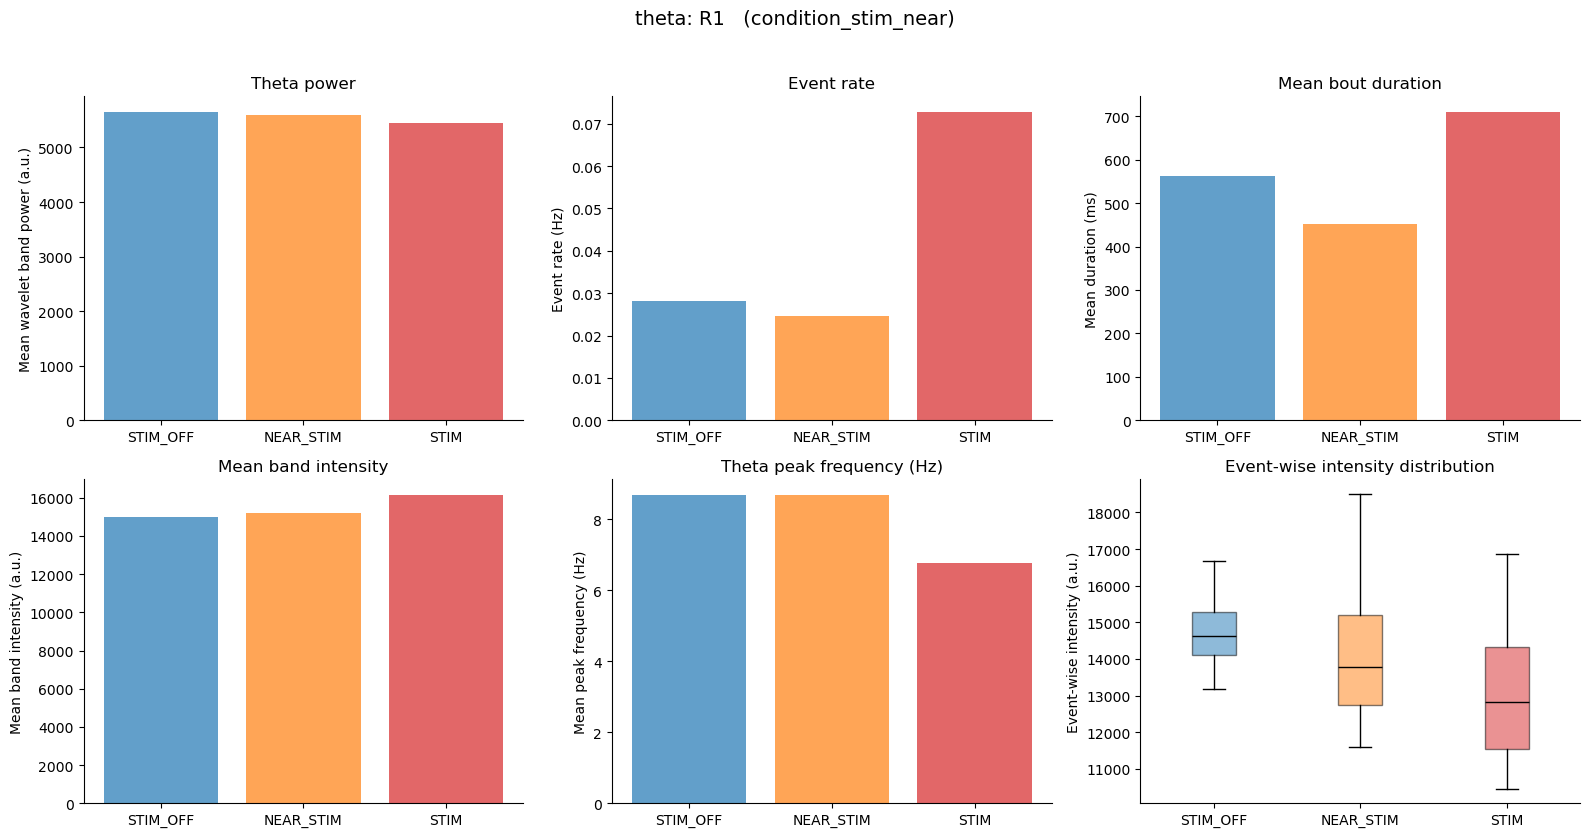

,condition,duration_s,n_events,event_rate_hz,mean_duration_ms,mean_peak_frequency_hz,mean_peak_intensity,mean_max_intensity,mean_band_power
0,STIM,96.1500,7,0.072803,710.285714,6.759064,16158.371142,18452.413847,5456.713068
1,NEAR_STIM,81.1180,2,0.024655,452.000000,8.668366,15194.187684,16511.367245,5586.084765
2,STIM_OFF,106.6415,3,0.028132,562.500000,8.683046,15012.655857,16291.484326,5654.093751


In [245]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# OPTIONS
# ============================================================
BAND_TO_PLOT = "theta"   # "theta" or "slow_gamma"
CHANNEL_TO_PLOT = "R1"

# condition system for comparison
CONDITION_COLUMN = "condition_stim_near"
CONDITIONS_TO_PLOT = ["STIM_OFF", "NEAR_STIM", "STIM"]

# colours
cond_colors = {
    "STIM": "tab:red",
    "NEAR_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

# which summary table to use
# expects you have already run the code that created:
#   df_condition_summary_theta / all_results_theta
#   df_condition_summary_slow_gamma / all_results_slow_gamma

# ============================================================
# PICK DATASET
# ============================================================
if BAND_TO_PLOT == "theta":
    results_dict = all_results_theta
    condition_summary_all = df_condition_summary_theta.copy()
    power_label = "Theta power"
    freq_label = "Theta peak frequency (Hz)"
    intensity_col = "mean_peak_intensity"
    duration_col = "mean_duration_ms"
    rate_col = "event_rate_hz"
    freq_col = "mean_peak_frequency_hz"
    intensity_event_col = "avg_band_intensity" if "avg_band_intensity" in results_dict[CHANNEL_TO_PLOT]["events_df"].columns else "avg_ripple_intensity"
    freq_event_col = "avg_band_frequency_hz" if "avg_band_frequency_hz" in results_dict[CHANNEL_TO_PLOT]["events_df"].columns else "avg_ripple_frequency_hz"
elif BAND_TO_PLOT == "slow_gamma":
    results_dict = all_results_slow_gamma
    condition_summary_all = df_condition_summary_slow_gamma.copy()
    power_label = "Slow gamma power"
    freq_label = "Slow gamma peak frequency (Hz)"
    intensity_col = "mean_peak_intensity"
    duration_col = "mean_duration_ms"
    rate_col = "event_rate_hz"
    freq_col = "mean_peak_frequency_hz"
    intensity_event_col = "avg_band_intensity" if "avg_band_intensity" in results_dict[CHANNEL_TO_PLOT]["events_df"].columns else "avg_ripple_intensity"
    freq_event_col = "avg_band_frequency_hz" if "avg_band_frequency_hz" in results_dict[CHANNEL_TO_PLOT]["events_df"].columns else "avg_ripple_frequency_hz"
else:
    raise ValueError("BAND_TO_PLOT must be 'theta' or 'slow_gamma'")

if CHANNEL_TO_PLOT not in results_dict:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in {BAND_TO_PLOT} results. Available: {list(results_dict.keys())}")

det_res = results_dict[CHANNEL_TO_PLOT]["det_res"]
events_df = results_dict[CHANNEL_TO_PLOT]["events_df"].copy()

if CONDITION_COLUMN not in events_df.columns:
    raise ValueError(
        f"{CONDITION_COLUMN} not found in events_df. "
        f"Available columns: {list(events_df.columns)}"
    )

# summary rows for this channel and condition set
summary_df = condition_summary_all[
    (condition_summary_all["channel"] == CHANNEL_TO_PLOT) &
    (condition_summary_all["condition_set"] == CONDITION_COLUMN) &
    (condition_summary_all["condition"].isin(CONDITIONS_TO_PLOT))
].copy()

if len(summary_df) == 0:
    raise ValueError("No rows found in condition summary for this channel / condition set.")

# keep only desired events
events_plot = events_df[events_df[CONDITION_COLUMN].isin(CONDITIONS_TO_PLOT)].copy()

# ============================================================
# COMPUTE CONTINUOUS BAND POWER BY CONDITION
# ============================================================
proj = np.asarray(det_res["projection"], dtype=float)
t = np.asarray(det_res["t"], dtype=float)

# use artifact mask from same analysis
artifact_mask = np.asarray(results_dict[CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)

valid = np.isfinite(proj) & (~artifact_mask)

# condition masks created earlier in your notebook
if CONDITION_COLUMN == "condition_stim_near":
    condition_masks = {
        "STIM": np.asarray(stim_mask, dtype=bool) & valid,
        "NEAR_STIM": np.asarray(near_stim_mask, dtype=bool) & valid,
        "STIM_OFF": (~np.asarray(stim_mask, dtype=bool)) & valid,
    }
elif CONDITION_COLUMN == "condition_pre_post":
    condition_masks = {
        "STIM": np.asarray(stim_mask, dtype=bool) & valid,
        "PRE_STIM": np.asarray(pre_stim_mask, dtype=bool) & valid,
        "POST_STIM": np.asarray(post_stim_mask, dtype=bool) & valid,
        "STIM_OFF": (~np.asarray(stim_mask, dtype=bool)) & valid,
    }
else:
    raise ValueError("This plotting block currently expects condition_stim_near or condition_pre_post")

power_rows = []
for cond in CONDITIONS_TO_PLOT:
    m = condition_masks[cond]
    vals = proj[m]
    vals = vals[np.isfinite(vals)]

    power_rows.append({
        "condition": cond,
        "mean_band_power": float(np.mean(vals)) if len(vals) else np.nan,
        "median_band_power": float(np.median(vals)) if len(vals) else np.nan,
        "n_samples": int(np.sum(np.isfinite(vals))),
    })

power_df = pd.DataFrame(power_rows)

# ============================================================
# FIGURE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
axes = axes.flatten()

# ------------------------------------------------------------
# 1) THETA / SLOW GAMMA POWER
# ------------------------------------------------------------
ax = axes[0]
xpos = np.arange(len(CONDITIONS_TO_PLOT))
power_vals = [power_df.loc[power_df["condition"] == c, "mean_band_power"].iloc[0] for c in CONDITIONS_TO_PLOT]
ax.bar(
    xpos,
    power_vals,
    color=[cond_colors[c] for c in CONDITIONS_TO_PLOT],
    alpha=0.7
)
ax.set_xticks(xpos)
ax.set_xticklabels(CONDITIONS_TO_PLOT)
ax.set_ylabel("Mean wavelet band power (a.u.)")
ax.set_title(power_label)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 2) EVENT RATE
# ------------------------------------------------------------
ax = axes[1]
rate_vals = [summary_df.loc[summary_df["condition"] == c, rate_col].iloc[0] for c in CONDITIONS_TO_PLOT]
ax.bar(
    xpos,
    rate_vals,
    color=[cond_colors[c] for c in CONDITIONS_TO_PLOT],
    alpha=0.7
)
ax.set_xticks(xpos)
ax.set_xticklabels(CONDITIONS_TO_PLOT)
ax.set_ylabel("Event rate (Hz)")
ax.set_title("Event rate")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 3) MEAN DURATION
# ------------------------------------------------------------
ax = axes[2]
dur_vals = [summary_df.loc[summary_df["condition"] == c, duration_col].iloc[0] for c in CONDITIONS_TO_PLOT]
ax.bar(
    xpos,
    dur_vals,
    color=[cond_colors[c] for c in CONDITIONS_TO_PLOT],
    alpha=0.7
)
ax.set_xticks(xpos)
ax.set_xticklabels(CONDITIONS_TO_PLOT)
ax.set_ylabel("Mean duration (ms)")
ax.set_title("Mean bout duration")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 4) MEAN BAND INTENSITY
# ------------------------------------------------------------
ax = axes[3]
int_vals = [summary_df.loc[summary_df["condition"] == c, intensity_col].iloc[0] for c in CONDITIONS_TO_PLOT]
ax.bar(
    xpos,
    int_vals,
    color=[cond_colors[c] for c in CONDITIONS_TO_PLOT],
    alpha=0.7
)
ax.set_xticks(xpos)
ax.set_xticklabels(CONDITIONS_TO_PLOT)
ax.set_ylabel("Mean band intensity (a.u.)")
ax.set_title("Mean band intensity")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 5) PEAK FREQUENCY
# ------------------------------------------------------------
ax = axes[4]
freq_vals = [summary_df.loc[summary_df["condition"] == c, freq_col].iloc[0] for c in CONDITIONS_TO_PLOT]
ax.bar(
    xpos,
    freq_vals,
    color=[cond_colors[c] for c in CONDITIONS_TO_PLOT],
    alpha=0.7
)
ax.set_xticks(xpos)
ax.set_xticklabels(CONDITIONS_TO_PLOT)
ax.set_ylabel("Mean peak frequency (Hz)")
ax.set_title(freq_label)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 6) EVENT-WISE DISTRIBUTION PANEL
# here show event-wise intensity as boxplot for extra detail
# ------------------------------------------------------------
ax = axes[5]
box_data = []
box_labels = []
for cond in CONDITIONS_TO_PLOT:
    d = events_plot[events_plot[CONDITION_COLUMN] == cond]
    vals = d[intensity_event_col].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals):
        box_data.append(vals)
        box_labels.append(cond)

if len(box_data):
    bp = ax.boxplot(
        box_data,
        patch_artist=True,
        labels=box_labels,
        showfliers=False
    )
    for patch, cond in zip(bp["boxes"], box_labels):
        patch.set_facecolor(cond_colors[cond])
        patch.set_alpha(0.5)
        patch.set_edgecolor("black")
    for median in bp["medians"]:
        median.set_color("black")

ax.set_ylabel("Event-wise intensity (a.u.)")
ax.set_title("Event-wise intensity distribution")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle(f"{BAND_TO_PLOT}: {CHANNEL_TO_PLOT}   ({CONDITION_COLUMN})", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ============================================================
# OPTIONAL: PRINT TABLE
# ============================================================
out_df = summary_df[[
    "condition",
    "duration_s",
    "n_events",
    "event_rate_hz",
    "mean_duration_ms",
    "mean_peak_frequency_hz",
    "mean_peak_intensity",
    "mean_max_intensity"
]].copy()

out_df = out_df.merge(
    power_df[["condition", "mean_band_power"]],
    on="condition",
    how="left"
)

display(out_df.reset_index(drop=True))

/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/433137496.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


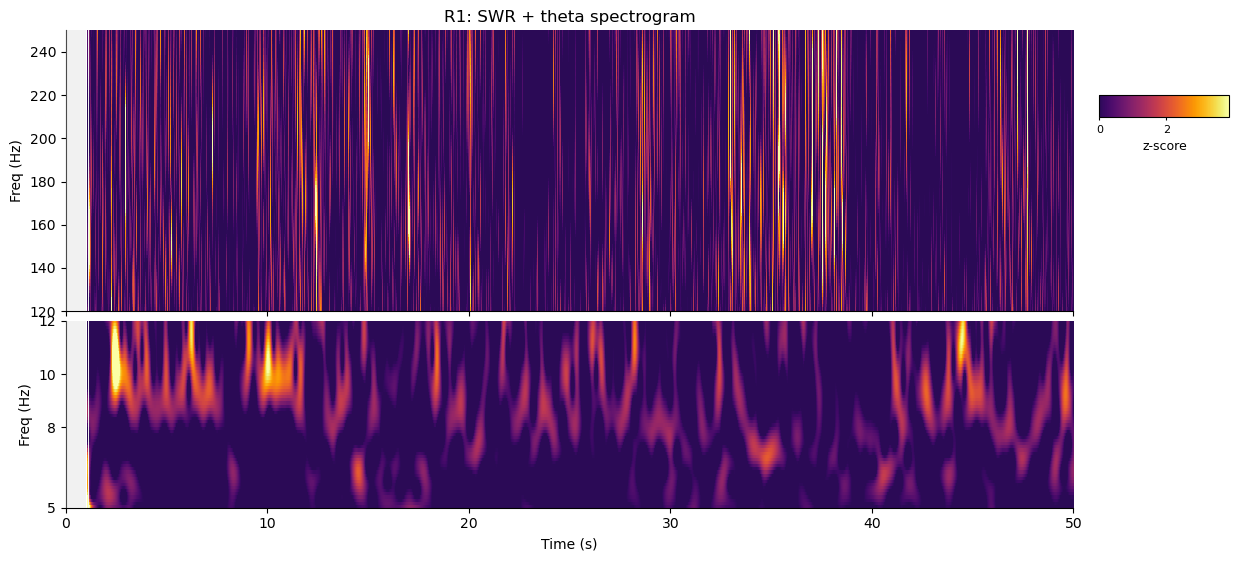

Channel plotted: R1
Window: 0.000 s to 50.000 s
Normalization: zscore_per_frequency
Artifact hidden: True
Artifact samples in plotted window: 2168


In [246]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# OPTIONS
# ============================================================
CHANNEL_TO_PLOT = "R1"
START_S = 0.0
WINDOW_S = 50.0

# normalization
# "none" = raw abs wavelet magnitude
# "zscore_per_frequency" = z-score each frequency row across the full trace
NORMALIZE_MODE = "zscore_per_frequency"

# whether to hide artifact periods in the spectrogram
# True  -> artifact time bins are blanked out
# False -> artifact bins are still shown
HIDE_ARTIFACT = True

# frequency ranges to display
THETA_FMIN_PLOT = 3
THETA_FMAX_PLOT = 15

SWR_FMIN_PLOT = 120
SWR_FMAX_PLOT = 250

# colormap settings
VMAX_PERCENTILE = 99.5
CMAP_NAME = "inferno"
CMAP_MINVAL = 0.15
CMAP_MAXVAL = 1.0

# ============================================================
# HELPERS
# ============================================================
def truncate_colormap(cmap_name="inferno", minval=0.15, maxval=1.0, n=256):
    cmap = plt.get_cmap(cmap_name)
    return mpl.colors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap_name}_{minval:.2f}_{maxval:.2f}",
        cmap(np.linspace(minval, maxval, n))
    )

def normalize_cwt(cwt_abs, mode="none"):
    cwt_abs = np.asarray(cwt_abs, dtype=float)

    if mode == "none":
        return cwt_abs

    if mode == "zscore_per_frequency":
        mu = np.nanmean(cwt_abs, axis=1, keepdims=True)
        sd = np.nanstd(cwt_abs, axis=1, keepdims=True)
        sd[~np.isfinite(sd) | (sd == 0)] = 1.0
        return (cwt_abs - mu) / sd

    raise ValueError("NORMALIZE_MODE must be 'none' or 'zscore_per_frequency'")

def apply_artifact_mask_to_cwt(cwt_2d, artifact_mask_1d):
    """
    Set artifact columns to NaN so they appear blank in imshow.
    """
    out = np.asarray(cwt_2d, dtype=float).copy()
    art = np.asarray(artifact_mask_1d, dtype=bool)
    if out.shape[1] != len(art):
        raise ValueError("artifact mask length does not match cwt time dimension")
    out[:, art] = np.nan
    return out

# ============================================================
# LOAD DETECTION RESULTS
# Assumes these already exist from your previous analysis:
#   all_results        -> SWR results
#   all_results_theta  -> theta results
# ============================================================
if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results")

if CHANNEL_TO_PLOT not in all_results_theta:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results_theta")

det_res_swr = all_results[CHANNEL_TO_PLOT]["det_res"]
det_res_theta = all_results_theta[CHANNEL_TO_PLOT]["det_res"]

artifact_mask_swr = np.asarray(all_results[CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)
artifact_mask_theta = np.asarray(all_results_theta[CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)

t_swr = np.asarray(det_res_swr["t"], dtype=float)
freq_swr = np.asarray(det_res_swr["freq"], dtype=float)
cwt_swr = np.asarray(det_res_swr["abs_cwt"], dtype=float)

t_theta = np.asarray(det_res_theta["t"], dtype=float)
freq_theta = np.asarray(det_res_theta["freq"], dtype=float)
cwt_theta = np.asarray(det_res_theta["abs_cwt"], dtype=float)

# ------------------------------------------------------------
# basic checks
# ------------------------------------------------------------
if len(t_swr) != len(t_theta):
    raise ValueError("Theta and SWR time vectors have different lengths")

if not np.allclose(t_swr, t_theta, atol=1e-9, rtol=0):
    raise ValueError("Theta and SWR time vectors are not aligned")

if len(artifact_mask_swr) != len(t_swr):
    raise ValueError("artifact_mask_swr length does not match t_swr")

if len(artifact_mask_theta) != len(t_theta):
    raise ValueError("artifact_mask_theta length does not match t_theta")

# use shared aligned time axis
t_shared = t_swr
fs_local = 1.0 / np.median(np.diff(t_shared))
n = len(t_shared)

# union of artifacts from both analyses
artifact_mask_union = artifact_mask_swr | artifact_mask_theta

# ============================================================
# SELECT TIME WINDOW
# ============================================================
idx0 = max(0, int(np.floor(START_S * fs_local)))
idx1 = min(n, int(np.ceil((START_S + WINDOW_S) * fs_local)))
if idx1 <= idx0:
    idx1 = min(n, idx0 + 1)

i0 = float(t_shared[idx0])
if idx1 < n:
    i1 = float(t_shared[idx1])
else:
    i1 = float(t_shared[idx1 - 1] + 1.0 / fs_local)

t_start = float(i0)
t_end = float(i1)

# ============================================================
# SELECT FREQUENCY RANGES
# ============================================================
theta_mask = (freq_theta >= THETA_FMIN_PLOT) & (freq_theta <= THETA_FMAX_PLOT)
swr_mask = (freq_swr >= SWR_FMIN_PLOT) & (freq_swr <= SWR_FMAX_PLOT)

freq_theta_win = freq_theta[theta_mask]
freq_swr_win = freq_swr[swr_mask]

if len(freq_theta_win) == 0:
    raise ValueError("No theta frequencies remain after THETA_FMIN_PLOT / THETA_FMAX_PLOT")

if len(freq_swr_win) == 0:
    raise ValueError("No SWR frequencies remain after SWR_FMIN_PLOT / SWR_FMAX_PLOT")

# ============================================================
# NORMALIZE
# ============================================================
cwt_theta_norm = normalize_cwt(cwt_theta, mode=NORMALIZE_MODE)
cwt_swr_norm = normalize_cwt(cwt_swr, mode=NORMALIZE_MODE)

# optionally blank out artifact parts before windowing
if HIDE_ARTIFACT:
    cwt_theta_norm = apply_artifact_mask_to_cwt(cwt_theta_norm, artifact_mask_union)
    cwt_swr_norm = apply_artifact_mask_to_cwt(cwt_swr_norm, artifact_mask_union)

theta_win = cwt_theta_norm[theta_mask, idx0:idx1]
swr_win = cwt_swr_norm[swr_mask, idx0:idx1]

artifact_win = artifact_mask_union[idx0:idx1]

# ============================================================
# COLOR SCALING
# ============================================================
vals = np.concatenate([
    theta_win[np.isfinite(theta_win)].ravel(),
    swr_win[np.isfinite(swr_win)].ravel()
])

if vals.size == 0:
    vmin = 0.0
    vmax = 1.0
else:
    if NORMALIZE_MODE == "zscore_per_frequency":
        vmin = max(0.0, np.nanpercentile(vals, 5))
        vmax = np.nanpercentile(vals, VMAX_PERCENTILE)
    else:
        vmin = 0.0
        vmax = np.nanpercentile(vals, VMAX_PERCENTILE)

cmap_trunc = truncate_colormap(
    cmap_name=CMAP_NAME,
    minval=CMAP_MINVAL,
    maxval=CMAP_MAXVAL,
    n=256
)

# make artifact / NaN part blank white
cmap_plot = cmap_trunc.copy()
cmap_plot.set_bad(color="white")

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 6.2),
    sharex=True,
    gridspec_kw={"height_ratios": [1.5, 1.0], "hspace": 0.04}
)

ax_swr, ax_theta = axes

# ------------------------------------------------------------
# SWR spectrogram
# ------------------------------------------------------------
im1 = ax_swr.imshow(
    swr_win,
    aspect="auto",
    origin="lower",
    extent=[t_start, t_end, freq_swr_win[0], freq_swr_win[-1]],
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
    cmap=cmap_plot,
)

ax_swr.set_xlim(t_start, t_end)
ax_swr.set_ylim(freq_swr_win[0], freq_swr_win[-1])
ax_swr.set_ylabel("Freq (Hz)")
ax_swr.set_title(f"{CHANNEL_TO_PLOT}: SWR + theta spectrogram")
ax_swr.spines["top"].set_visible(False)
ax_swr.spines["right"].set_visible(False)

if float(np.min(freq_swr_win)) <= 120 and float(np.max(freq_swr_win)) >= 250:
    ax_swr.set_yticks([120, 140, 160, 180, 200, 220, 240])
else:
    ax_swr.set_yticks(np.linspace(freq_swr_win[0], freq_swr_win[-1], 5))

# ------------------------------------------------------------
# Theta spectrogram
# ------------------------------------------------------------
im2 = ax_theta.imshow(
    theta_win,
    aspect="auto",
    origin="lower",
    extent=[t_start, t_end, freq_theta_win[0], freq_theta_win[-1]],
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
    cmap=cmap_plot,
)

ax_theta.set_xlim(t_start, t_end)
ax_theta.set_ylim(freq_theta_win[0], freq_theta_win[-1])
ax_theta.set_ylabel("Freq (Hz)")
ax_theta.set_xlabel("Time (s)")
ax_theta.spines["top"].set_visible(False)
ax_theta.spines["right"].set_visible(False)

theta_ticks = [3, 5, 8, 10, 12, 15]
theta_ticks = [v for v in theta_ticks if freq_theta_win[0] <= v <= freq_theta_win[-1]]
ax_theta.set_yticks(theta_ticks)

# ------------------------------------------------------------
# Optional artifact markers at top edge
# keeps timescale intact but shows where blanking happened
# ------------------------------------------------------------
if HIDE_ARTIFACT and np.any(artifact_win):
    # mark artifact columns with faint grey bars at very top of each panel
    art_i = artifact_win.astype(int)
    starts = np.where(np.diff(np.r_[0, art_i]) == 1)[0]
    ends = np.where(np.diff(np.r_[art_i, 0]) == -1)[0]

    for s_idx, e_idx in zip(starts, ends):
        s_t = t_shared[idx0 + s_idx]
        e_t = t_shared[min(idx0 + e_idx, n - 1)]
        ax_swr.axvspan(s_t, e_t, color="0.85", alpha=0.35, lw=0, zorder=5)
        ax_theta.axvspan(s_t, e_t, color="0.85", alpha=0.35, lw=0, zorder=5)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------
cax = fig.add_axes([0.92, 0.74, 0.10, 0.035])
cbar = fig.colorbar(im1, cax=cax, orientation="horizontal")
cbar.ax.tick_params(labelsize=8, length=2)

if NORMALIZE_MODE == "zscore_per_frequency":
    cbar.set_label("z-score", fontsize=9)
else:
    cbar.set_label("Wavelet magnitude", fontsize=9)

plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

print(f"Channel plotted: {CHANNEL_TO_PLOT}")
print(f"Window: {t_start:.3f} s to {t_end:.3f} s")
print(f"Normalization: {NORMALIZE_MODE}")
print(f"Artifact hidden: {HIDE_ARTIFACT}")
print(f"Artifact samples in plotted window: {int(np.sum(artifact_win))}")

AO ses-33_date-20250924


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_18799/420046366.py:436: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


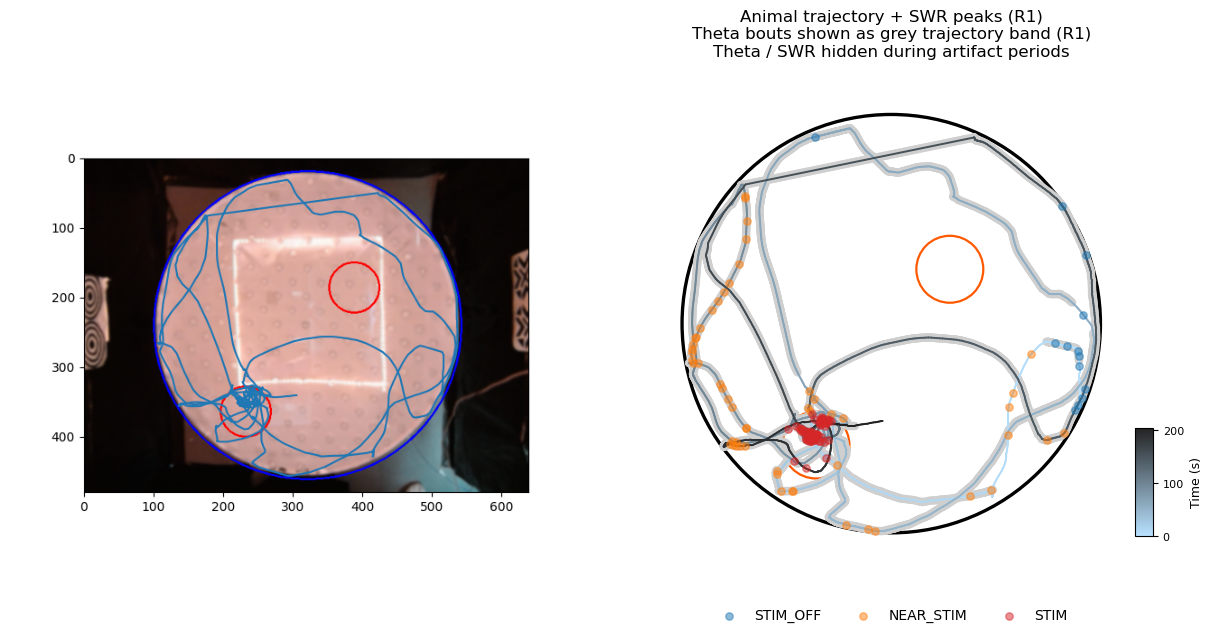

SWR channel used: R1
Theta channel used: R1
Condition column used: condition_stim_near
Artifact mode: hide_events_in_artifact
Total SWR peaks plotted: 140
condition_stim_near
STIM         72
NEAR_STIM    55
STIM_OFF     13
Name: count, dtype: int64
Total theta bouts plotted: 56


In [247]:
# animal trajectory + optional theta bouts + optional SWR locations
# with artifact display modes

from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
import matplotlib as mpl
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Load trial data
# ------------------------------------------------------------
metadata = util.load_metadata()
ROW_IDX = 2235
dl = DataLoader(metadata.iloc[ROW_IDX])

position = dl.get_data('position')
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

print(dl.id, dl.ses_dir)

# ------------------------------------------------------------
# Choose channels + condition system
# ------------------------------------------------------------
CHANNEL_TO_PLOT = "R1"
THETA_CHANNEL_TO_PLOT = "R1"

# options:
#   "condition_stim_near"
#   "condition_pre_post"
#   "condition"
CONDITION_COLUMN = "condition_stim_near"

# ------------------------------------------------------------
# Display options
# ------------------------------------------------------------
SHOW_THETA_BOUTS = True
SHOW_SWR_DOTS = True

# Artifact mode:
#   "hide_events_in_artifact" -> hide theta/SWR during artifact periods
#   "show_artifact_overlay"   -> show all theta/SWR, and shade artifact periods on trajectory
#   "show_artifact_events_only" -> show only theta/SWR that overlap artifact periods
ARTIFACT_MODE = "hide_events_in_artifact"

THETA_RESULTS_DICT = all_results_theta   # assumes theta analysis already run

THETA_BAND_COLOR = "#cfcfcf"       # light grey
THETA_BAND_ALPHA = 0.9
THETA_BAND_LINEWIDTH = 6.0

ARTIFACT_OVERLAY_COLOR = "#bdbdbd"
ARTIFACT_OVERLAY_ALPHA = 0.6
ARTIFACT_OVERLAY_LINEWIDTH = 8.0

# ------------------------------------------------------------
# Cheeseboard geometry
# ------------------------------------------------------------
BOARD_CENTER_X = 50
BOARD_CENTER_Y = 50
BOARD_RADIUS = 50
TRIGGER_RADIUS = 8
PLOT_PADDING = 12

# ============================================================
# HELPERS
# ============================================================
def build_artifact_intervals_from_mask(mask_bool, t_axis):
    mask_bool = np.asarray(mask_bool, dtype=bool)
    t_axis = np.asarray(t_axis, dtype=float)

    if len(mask_bool) != len(t_axis):
        raise ValueError("artifact mask length does not match time axis length")

    if len(t_axis) < 2 or not np.any(mask_bool):
        return []

    starts = np.where(np.diff(np.r_[0, mask_bool.astype(int)]) == 1)[0]
    ends = np.where(np.diff(np.r_[mask_bool.astype(int), 0]) == -1)[0]

    intervals = []
    dt_med = np.nanmedian(np.diff(t_axis))

    for s_idx, e_idx in zip(starts, ends):
        s_t = float(t_axis[s_idx])
        if e_idx < len(t_axis):
            e_t = float(t_axis[e_idx])
        else:
            e_t = float(t_axis[-1] + dt_med)
        if e_t > s_t:
            intervals.append((s_t, e_t))

    return intervals

def interval_overlaps_any(s, e, intervals):
    for a, b in intervals:
        if (e > a) and (s < b):
            return True
    return False

def classify_overlap(df, intervals, start_col="start_s", end_col="end_s", peak_col="peak_time_s"):
    if len(df) == 0:
        out = df.copy()
        out["_artifact_overlap"] = pd.Series(dtype=bool)
        return out

    keep = []
    for _, ev in df.iterrows():
        s = float(ev[start_col]) if start_col in df.columns else float(ev[peak_col])
        e = float(ev[end_col]) if end_col in df.columns else float(ev[peak_col])
        pk = float(ev[peak_col])
        is_art = interval_overlaps_any(pk, pk + 1e-12, intervals) or interval_overlaps_any(s, e, intervals)
        keep.append(is_art)

    out = df.copy()
    out["_artifact_overlap"] = np.asarray(keep, dtype=bool)
    return out

# ============================================================
# LOAD SWR RESULTS
# ============================================================
if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()
swr_det_res = all_results[CHANNEL_TO_PLOT]["det_res"]
swr_artifact_mask = np.asarray(all_results[CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)
t_swr = np.asarray(swr_det_res["t"], dtype=float)

if CONDITION_COLUMN not in events_df.columns:
    raise ValueError(
        f"{CONDITION_COLUMN} not found in events_df. "
        f"Available columns: {list(events_df.columns)}"
    )

swr_artifact_intervals = build_artifact_intervals_from_mask(swr_artifact_mask, t_swr)

# keep non-condition ARTIFACT rows out, but track overlap separately
events_df = events_df[events_df[CONDITION_COLUMN] != "ARTIFACT"].copy()
events_df = classify_overlap(events_df, swr_artifact_intervals)

if ARTIFACT_MODE == "hide_events_in_artifact":
    events_df = events_df[~events_df["_artifact_overlap"]].copy()
elif ARTIFACT_MODE == "show_artifact_events_only":
    events_df = events_df[events_df["_artifact_overlap"]].copy()
elif ARTIFACT_MODE == "show_artifact_overlay":
    pass
else:
    raise ValueError("ARTIFACT_MODE must be one of: 'hide_events_in_artifact', 'show_artifact_overlay', 'show_artifact_events_only'")

# ============================================================
# LOAD THETA RESULTS
# ============================================================
theta_events_df = pd.DataFrame()
theta_artifact_intervals = []

if SHOW_THETA_BOUTS:
    if THETA_CHANNEL_TO_PLOT not in THETA_RESULTS_DICT:
        raise ValueError(
            f"{THETA_CHANNEL_TO_PLOT} not found in theta results. "
            f"Available: {list(THETA_RESULTS_DICT.keys())}"
        )

    theta_events_df = THETA_RESULTS_DICT[THETA_CHANNEL_TO_PLOT]["events_df"].copy()
    theta_det_res = THETA_RESULTS_DICT[THETA_CHANNEL_TO_PLOT]["det_res"]
    theta_artifact_mask = np.asarray(THETA_RESULTS_DICT[THETA_CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)
    t_theta = np.asarray(theta_det_res["t"], dtype=float)

    theta_artifact_intervals = build_artifact_intervals_from_mask(theta_artifact_mask, t_theta)

    if "condition" in theta_events_df.columns:
        theta_events_df = theta_events_df[theta_events_df["condition"] != "ARTIFACT"].copy()
    if "condition_stim_near" in theta_events_df.columns:
        theta_events_df = theta_events_df[theta_events_df["condition_stim_near"] != "ARTIFACT"].copy()
    if "condition_pre_post" in theta_events_df.columns:
        theta_events_df = theta_events_df[theta_events_df["condition_pre_post"] != "ARTIFACT"].copy()

    theta_events_df = classify_overlap(theta_events_df, theta_artifact_intervals)

    if ARTIFACT_MODE == "hide_events_in_artifact":
        theta_events_df = theta_events_df[~theta_events_df["_artifact_overlap"]].copy()
    elif ARTIFACT_MODE == "show_artifact_events_only":
        theta_events_df = theta_events_df[theta_events_df["_artifact_overlap"]].copy()

# ============================================================
# POSITION DATA
# ============================================================
if 't' not in position.columns:
    raise ValueError("position dataframe does not contain column 't'.")

t = position['t'].values.astype(float)

dt = np.nanmedian(np.diff(t)) if len(t) > 1 else np.nan
if np.isfinite(dt) and dt > 1.0:
    t = t / 1000.0

x = position['x'].values.astype(float)
y = position['y'].values.astype(float)

ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)
x = x[ok]
y = y[ok]
t = t[ok]

if len(t) < 2:
    raise ValueError("Not enough valid position samples.")

# ============================================================
# FIGURE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=(1, 1))

# ------------------------------------------------------------
# Left panel: image
# ------------------------------------------------------------
axes[0].imshow(img)
axes[0].axis('off')

# ------------------------------------------------------------
# Right panel: trajectory
# ------------------------------------------------------------
ax = axes[1]
ax.set_facecolor("white")

# ------------------------------------------------------------
# Time-coloured trajectory
# ------------------------------------------------------------
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "traj_time",
    ['#b8e2ff', '#222222']
)
norm = mpl.colors.Normalize(t.min(), t.max())

# ------------------------------------------------------------
# Artifact overlay on trajectory
# ------------------------------------------------------------
if ARTIFACT_MODE == "show_artifact_overlay":
    artifact_union = sorted(swr_artifact_intervals + theta_artifact_intervals, key=lambda z: z[0])
    if len(artifact_union):
        art_seg_list = []
        for s, e in artifact_union:
            mask_seg = (t[:-1] <= e) & (t[1:] >= s)
            if np.any(mask_seg):
                art_seg_list.append(segments[mask_seg])

        if len(art_seg_list):
            art_segments = np.concatenate(art_seg_list, axis=0)
            lc_art = LineCollection(
                art_segments,
                colors=ARTIFACT_OVERLAY_COLOR,
                linewidths=ARTIFACT_OVERLAY_LINEWIDTH,
                alpha=ARTIFACT_OVERLAY_ALPHA,
                capstyle='round',
                zorder=1.0
            )
            ax.add_collection(lc_art)

# ------------------------------------------------------------
# Theta bouts mapped as grey bands on trajectory
# ------------------------------------------------------------
if SHOW_THETA_BOUTS and len(theta_events_df):
    theta_events_df = theta_events_df.copy()
    theta_events_df = theta_events_df[
        (theta_events_df["end_s"] >= t.min()) &
        (theta_events_df["start_s"] <= t.max())
    ].copy()

    theta_seg_list = []

    for _, ev in theta_events_df.iterrows():
        s = float(ev["start_s"])
        e = float(ev["end_s"])
        mask_seg = (t[:-1] <= e) & (t[1:] >= s)
        if np.any(mask_seg):
            theta_seg_list.append(segments[mask_seg])

    if len(theta_seg_list):
        theta_segments = np.concatenate(theta_seg_list, axis=0)

        lc_theta = LineCollection(
            theta_segments,
            colors=THETA_BAND_COLOR,
            linewidths=THETA_BAND_LINEWIDTH,
            alpha=THETA_BAND_ALPHA,
            capstyle='round',
            zorder=1.5
        )
        ax.add_collection(lc_theta)

# ------------------------------------------------------------
# Main time-coloured trajectory
# ------------------------------------------------------------
lc = LineCollection(
    segments,
    cmap=cmap,
    norm=norm,
    linewidth=1.4,
    capstyle='round',
    zorder=2.5
)
lc.set_array(t[:-1])
ax.add_collection(lc)

# ------------------------------------------------------------
# Map SWR peak times to nearest position points
# ------------------------------------------------------------
cond_colors = {
    "STIM": "tab:red",
    "NEAR_STIM": "tab:orange",
    "PRE_STIM": "tab:orange",
    "POST_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

if CONDITION_COLUMN == "condition_stim_near":
    cond_order = ["STIM_OFF", "NEAR_STIM", "STIM"]
elif CONDITION_COLUMN == "condition_pre_post":
    cond_order = ["STIM_OFF", "PRE_STIM", "POST_STIM", "STIM"]
else:
    cond_order = [c for c in ["STIM_OFF", "NEAR_STIM", "PRE_STIM", "POST_STIM", "STIM"] if c in events_df[CONDITION_COLUMN].unique()]

legend_done = set()

if SHOW_SWR_DOTS and len(events_df):
    events_df = events_df.copy()
    events_df = events_df[
        (events_df["peak_time_s"] >= t.min()) &
        (events_df["peak_time_s"] <= t.max())
    ].copy()

    if len(events_df):
        swr_peak_times = events_df["peak_time_s"].to_numpy(dtype=float)

        idx = np.searchsorted(t, swr_peak_times)
        idx = np.clip(idx, 0, len(t) - 1)

        idx_prev = np.clip(idx - 1, 0, len(t) - 1)
        use_prev = np.abs(t[idx_prev] - swr_peak_times) < np.abs(t[idx] - swr_peak_times)
        idx[use_prev] = idx_prev[use_prev]

        events_df["traj_x"] = x[idx]
        events_df["traj_y"] = y[idx]

        for cond in cond_order:
            d = events_df[events_df[CONDITION_COLUMN] == cond]
            if len(d):
                ax.scatter(
                    d["traj_x"],
                    d["traj_y"],
                    s=28,
                    c=cond_colors.get(cond, "gray"),
                    alpha=0.5,
                    zorder=5,
                    label=cond if cond not in legend_done else None
                )
                legend_done.add(cond)

# ------------------------------------------------------------
# Cheeseboard circle
# ------------------------------------------------------------
board_circle = Circle(
    (BOARD_CENTER_X, BOARD_CENTER_Y),
    BOARD_RADIUS,
    color='black',
    fill=False,
    linewidth=2.4
)
ax.add_artist(board_circle)

# ------------------------------------------------------------
# Reward zones
# ------------------------------------------------------------
for i in range(len(triggerLoc)):
    cx = triggerLoc['x'][i]
    cy = triggerLoc['y'][i]

    reward_circle = Circle(
        (cx, cy),
        TRIGGER_RADIUS,
        color="#ff5900",
        fill=False,
        linewidth=1.6
    )
    ax.add_artist(reward_circle)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
ax.set_xlim(
    BOARD_CENTER_X - BOARD_RADIUS - PLOT_PADDING,
    BOARD_CENTER_X + BOARD_RADIUS + PLOT_PADDING
)

ax.set_ylim(
    BOARD_CENTER_Y + BOARD_RADIUS + PLOT_PADDING,
    BOARD_CENTER_Y - BOARD_RADIUS - PLOT_PADDING
)

ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

title_text = f"Animal trajectory + SWR peaks ({CHANNEL_TO_PLOT})"
if SHOW_THETA_BOUTS:
    title_text += f"\nTheta bouts shown as grey trajectory band ({THETA_CHANNEL_TO_PLOT})"

if ARTIFACT_MODE == "hide_events_in_artifact":
    title_text += "\nTheta / SWR hidden during artifact periods"
elif ARTIFACT_MODE == "show_artifact_overlay":
    title_text += "\nArtifact periods shown as grey overlay"
elif ARTIFACT_MODE == "show_artifact_events_only":
    title_text += "\nOnly theta / SWR during artifact periods shown"

ax.set_title(title_text, fontsize=12)

if len(legend_done):
    ncol = 3 if len(legend_done) <= 3 else 4
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=ncol)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------
cax = fig.add_axes([0.95, 0.13, 0.015, 0.18])
cbar = fig.colorbar(lc, cax=cax)
cbar.set_label("Time (s)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------
print(f"SWR channel used: {CHANNEL_TO_PLOT}")
print(f"Theta channel used: {THETA_CHANNEL_TO_PLOT}")
print(f"Condition column used: {CONDITION_COLUMN}")
print(f"Artifact mode: {ARTIFACT_MODE}")
print(f"Total SWR peaks plotted: {len(events_df)}")
if len(events_df):
    print(events_df[CONDITION_COLUMN].value_counts(dropna=False))

if SHOW_THETA_BOUTS:
    print(f"Total theta bouts plotted: {len(theta_events_df)}")

In [236]:
# making video of trajectory + LFP + SWR events with audio
# updated to optionally show theta bouts as:
#   - grey band on trajectory
#   - grey shading on LFP trace
# and optionally hide SWR/theta events during artifact periods
#
# assumes:
#   - all_results has already been created for SWR
#   - all_results_theta has already been created for theta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import Circle, Ellipse
from matplotlib.animation import FuncAnimation, FFMpegWriter
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, savgol_filter
import subprocess

# ============================================================
# USER SETTINGS
# ============================================================
ROW_IDX = 2235
CHANNEL_TO_PLOT = "R1"
THETA_CHANNEL_TO_PLOT = "R1"

# choose which SWR condition system to use
# options:
#   "condition_stim_near" -> STIM / NEAR_STIM / STIM_OFF
#   "condition_pre_post"  -> STIM / PRE_STIM / POST_STIM / STIM_OFF
#   "condition"           -> fallback/default if present
CONDITION_COLUMN = "condition_stim_near"

VIDEO_FPS = 30
LFP_WINDOW_SECONDS = 2.0
OUTPUT_VIDEO = "trajectory_lfp_theta_swr.mp4"
OUTPUT_AUDIO = "trajectory_lfp_theta_swr_audio.wav"
FINAL_VIDEO = "trajectory_lfp_theta_swr_with_audio.mp4"

BOARD_CENTER_X = 50
BOARD_CENTER_Y = 50
BOARD_RADIUS = 50
TRIGGER_RADIUS = 8
PLOT_PADDING = 12

# --- theta display ---
SHOW_THETA_BOUTS = True
THETA_TRAJ_COLOR = "#cfcfcf"      # light grey
THETA_TRAJ_ALPHA = 0.95
THETA_TRAJ_LINEWIDTH = 6.0

THETA_LFP_SHADE_COLOR = "#d0d0d0"
THETA_LFP_SHADE_ALPHA = 0.28

# --- artifact handling ---
# True  -> hide theta/SWR events that overlap artifact periods
# False -> keep them
HIDE_EVENTS_IN_ARTIFACT = True

# --- audio ---
AUDIO_SR = 44100
BASE_LFP_GAIN = 0.025
RIPPLE_BOOST_GAIN = 0.35
FINAL_AUDIO_GAIN = 0.9

# ripple audio band
RIPPLE_AUDIO_FMIN = 120
RIPPLE_AUDIO_FMAX = 250

# --- SWR dot appearance ---
SWR_DOT_SIZE = 55
SWR_DOT_ALPHA = 0.45

# --- LFP SWR shading ---
LFP_SWR_SHADE_ALPHA = 0.18

# --- mouse shape on trajectory ---
MOUSE_BODY_LENGTH = 4.0
MOUSE_BODY_WIDTH = 2.4
MOUSE_HEAD_SIZE = 1.3
MOUSE_EAR_SIZE = 0.7

# ============================================================
# HELPERS
# ============================================================
def robust_normalize(x, q=99.5):
    x = np.asarray(x, dtype=float)
    finite = np.isfinite(x)
    if not np.any(finite):
        return np.zeros_like(x, dtype=float)
    scale = np.percentile(np.abs(x[finite]), q)
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0
    return np.clip(x / scale, -1, 1)

def bandpass_filter(x, fs, low, high, order=3):
    nyq = fs / 2.0
    low = max(low / nyq, 1e-6)
    high = min(high / nyq, 0.999)
    if high <= low:
        raise ValueError(f"Invalid bandpass range: {low*nyq}–{high*nyq} Hz")
    b, a = butter(order, [low, high], btype="bandpass")
    return filtfilt(b, a, x)

def lowpass_filter(x, fs, high, order=3):
    nyq = fs / 2.0
    high = min(high / nyq, 0.999)
    b, a = butter(order, high, btype="low")
    return filtfilt(b, a, x)

def resample_to_audio_time(t_src, x_src, sr, t0, t1):
    t_audio = np.arange(int(np.ceil((t1 - t0) * sr))) / sr + t0
    x_interp = np.interp(t_audio, t_src, x_src)
    return t_audio, x_interp

def rotate_points(points_xy, angle_rad):
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    R = np.array([[c, -s], [s, c]])
    return points_xy @ R.T

def build_artifact_intervals_from_mask(mask_bool, t_axis):
    """
    Convert sample-wise artifact mask into time intervals [start_s, end_s].
    """
    mask_bool = np.asarray(mask_bool, dtype=bool)
    t_axis = np.asarray(t_axis, dtype=float)

    if len(mask_bool) != len(t_axis):
        raise ValueError("artifact mask length does not match time axis length")

    if len(t_axis) < 2 or not np.any(mask_bool):
        return []

    starts = np.where(np.diff(np.r_[0, mask_bool.astype(int)]) == 1)[0]
    ends = np.where(np.diff(np.r_[mask_bool.astype(int), 0]) == -1)[0]

    intervals = []
    dt_med = np.nanmedian(np.diff(t_axis))

    for s_idx, e_idx in zip(starts, ends):
        s_t = float(t_axis[s_idx])
        if e_idx < len(t_axis):
            e_t = float(t_axis[e_idx])
        else:
            e_t = float(t_axis[-1] + dt_med)
        if e_t > s_t:
            intervals.append((s_t, e_t))

    return intervals

def interval_overlaps_any(s, e, intervals):
    for a, b in intervals:
        if (e > a) and (s < b):
            return True
    return False

def mark_artifact_overlap(df, intervals, start_col="start_s", end_col="end_s", peak_col="peak_time_s"):
    """
    Adds boolean column '_artifact_overlap'.
    """
    out = df.copy()
    if len(out) == 0:
        out["_artifact_overlap"] = pd.Series(dtype=bool)
        return out

    flags = []
    for _, ev in out.iterrows():
        s = float(ev[start_col]) if start_col in out.columns else float(ev[peak_col])
        e = float(ev[end_col]) if end_col in out.columns else float(ev[peak_col])
        pk = float(ev[peak_col])
        is_art = interval_overlaps_any(pk, pk + 1e-12, intervals) or interval_overlaps_any(s, e, intervals)
        flags.append(is_art)

    out["_artifact_overlap"] = np.asarray(flags, dtype=bool)
    return out

def build_point_mask_from_intervals(t_axis, events_df, start_col="start_s", end_col="end_s"):
    """
    Return boolean mask over t_axis: True if time lies inside any event interval.
    """
    t_axis = np.asarray(t_axis, dtype=float)
    mask = np.zeros(len(t_axis), dtype=bool)

    if len(events_df) == 0:
        return mask

    for _, ev in events_df.iterrows():
        s = float(ev[start_col])
        e = float(ev[end_col])
        mask |= (t_axis >= s) & (t_axis <= e)

    return mask

# ============================================================
# LOAD TRIAL DATA
# ============================================================
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[ROW_IDX])

position = dl.get_data("position")
triggerLoc = dl.get_data("triggerLoc")

print("Trial row:", ROW_IDX)
print("DataLoader:", dl.id, dl.ses_dir)

# ============================================================
# LOAD SWR RESULTS
# ============================================================
if CHANNEL_TO_PLOT not in all_results:
    raise ValueError(f"{CHANNEL_TO_PLOT} not found in all_results. Available: {list(all_results.keys())}")

det_res = all_results[CHANNEL_TO_PLOT]["det_res"]
events_df = all_results[CHANNEL_TO_PLOT]["events_df"].copy()
artifact_mask_swr = np.asarray(all_results[CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)

if CONDITION_COLUMN not in events_df.columns:
    raise ValueError(
        f"{CONDITION_COLUMN} not found in events_df. "
        f"Available columns: {list(events_df.columns)}"
    )

# remove explicit ARTIFACT-labelled SWR rows first
events_df = events_df[events_df[CONDITION_COLUMN] != "ARTIFACT"].copy()

# keep a generic column for plotting downstream
events_df["condition_plot"] = events_df[CONDITION_COLUMN]

# ============================================================
# LOAD THETA RESULTS
# ============================================================
theta_events_df = pd.DataFrame()
artifact_mask_theta = None

if SHOW_THETA_BOUTS:
    if THETA_CHANNEL_TO_PLOT not in all_results_theta:
        raise ValueError(
            f"{THETA_CHANNEL_TO_PLOT} not found in all_results_theta. "
            f"Available: {list(all_results_theta.keys())}"
        )

    det_res_theta = all_results_theta[THETA_CHANNEL_TO_PLOT]["det_res"]
    theta_events_df = all_results_theta[THETA_CHANNEL_TO_PLOT]["events_df"].copy()
    artifact_mask_theta = np.asarray(all_results_theta[THETA_CHANNEL_TO_PLOT]["artifact_mask"], dtype=bool)

    # remove explicit ARTIFACT-labelled theta rows if present
    for c in ["condition", "condition_stim_near", "condition_pre_post"]:
        if c in theta_events_df.columns:
            theta_events_df = theta_events_df[theta_events_df[c] != "ARTIFACT"].copy()

# ============================================================
# POSITION TIME / XY
# ============================================================
if "t" not in position.columns:
    raise ValueError("position dataframe does not contain column 't'.")

t_pos = position["t"].to_numpy(dtype=float)
if np.nanmedian(np.diff(t_pos)) > 1.0:
    t_pos = t_pos / 1000.0

x = position["x"].to_numpy(dtype=float)
y = position["y"].to_numpy(dtype=float)

ok = np.isfinite(t_pos) & np.isfinite(x) & np.isfinite(y)
t_pos = t_pos[ok]
x = x[ok]
y = y[ok]

# ============================================================
# LFP / TIME AXES
# ============================================================
t_lfp = np.asarray(det_res["t"], dtype=float)
lfp = np.asarray(det_res["x"], dtype=float)

if len(t_lfp) != len(artifact_mask_swr):
    raise ValueError("SWR artifact mask length does not match SWR time axis length")

t_min = max(np.nanmin(t_pos), np.nanmin(t_lfp))
t_max = min(np.nanmax(t_pos), np.nanmax(t_lfp))

# artifact intervals on SWR time axis
artifact_intervals_swr = build_artifact_intervals_from_mask(artifact_mask_swr, t_lfp)

if SHOW_THETA_BOUTS:
    t_theta = np.asarray(det_res_theta["t"], dtype=float)
    if len(t_theta) != len(artifact_mask_theta):
        raise ValueError("Theta artifact mask length does not match theta time axis length")
    artifact_intervals_theta = build_artifact_intervals_from_mask(artifact_mask_theta, t_theta)
else:
    artifact_intervals_theta = []

# union artifact intervals is not strictly merged, but overlap checking still works
artifact_intervals_union = artifact_intervals_swr + artifact_intervals_theta

# ============================================================
# FILTER EVENTS TO TRIAL TIME RANGE
# ============================================================
events_df = events_df[
    (events_df["peak_time_s"] >= t_min) &
    (events_df["peak_time_s"] <= t_max)
].copy()

if SHOW_THETA_BOUTS and len(theta_events_df):
    theta_events_df = theta_events_df[
        (theta_events_df["end_s"] >= t_min) &
        (theta_events_df["start_s"] <= t_max)
    ].copy()

# optionally remove events that overlap artifact periods
if HIDE_EVENTS_IN_ARTIFACT and len(events_df):
    events_df = mark_artifact_overlap(events_df, artifact_intervals_union)
    events_df = events_df[~events_df["_artifact_overlap"]].copy()

if HIDE_EVENTS_IN_ARTIFACT and SHOW_THETA_BOUTS and len(theta_events_df):
    theta_events_df = mark_artifact_overlap(theta_events_df, artifact_intervals_union)
    theta_events_df = theta_events_df[~theta_events_df["_artifact_overlap"]].copy()

# ============================================================
# CONDITION COLOURS
# ============================================================
cond_colors = {
    "STIM": "tab:red",
    "NEAR_STIM": "tab:orange",
    "PRE_STIM": "tab:orange",
    "POST_STIM": "tab:orange",
    "STIM_OFF": "tab:blue",
}

# ============================================================
# MAP SWR TIMES TO TRAJECTORY COORDS
# ============================================================
if len(events_df):
    swr_t = events_df["peak_time_s"].to_numpy(dtype=float)
    idx = np.searchsorted(t_pos, swr_t)
    idx = np.clip(idx, 0, len(t_pos) - 1)

    idx_prev = np.clip(idx - 1, 0, len(t_pos) - 1)
    use_prev = np.abs(t_pos[idx_prev] - swr_t) < np.abs(t_pos[idx] - swr_t)
    idx[use_prev] = idx_prev[use_prev]

    events_df["traj_x"] = x[idx]
    events_df["traj_y"] = y[idx]

# ============================================================
# BUILD THETA POINT MASK ON TRAJECTORY TIME AXIS
# ============================================================
if SHOW_THETA_BOUTS and len(theta_events_df):
    theta_point_mask = build_point_mask_from_intervals(
        t_axis=t_pos,
        events_df=theta_events_df,
        start_col="start_s",
        end_col="end_s",
    )
else:
    theta_point_mask = np.zeros(len(t_pos), dtype=bool)

# ============================================================
# BUILD AUDIO
# ============================================================
fs_lfp = 1.0 / np.median(np.diff(t_lfp))
print("Aligned LFP fs:", fs_lfp)

lfp_finite = np.copy(lfp)
lfp_finite[~np.isfinite(lfp_finite)] = np.nanmedian(lfp[np.isfinite(lfp)])

lfp_base = lowpass_filter(lfp_finite, fs_lfp, high=40, order=3)
ripple_band = bandpass_filter(lfp_finite, fs_lfp, RIPPLE_AUDIO_FMIN, RIPPLE_AUDIO_FMAX, order=3)

t_audio, base_audio = resample_to_audio_time(t_lfp, lfp_base, AUDIO_SR, t_min, t_max)
_, ripple_audio = resample_to_audio_time(t_lfp, ripple_band, AUDIO_SR, t_min, t_max)

base_audio = robust_normalize(base_audio)
ripple_audio = robust_normalize(ripple_audio)

base_audio = savgol_filter(base_audio, 101, 3, mode="interp")
base_audio = np.tanh(1.2 * base_audio)
ripple_audio = np.tanh(2.5 * ripple_audio)

audio = BASE_LFP_GAIN * base_audio + RIPPLE_BOOST_GAIN * ripple_audio
audio = robust_normalize(audio) * FINAL_AUDIO_GAIN
audio = np.clip(audio, -0.98, 0.98)

wavfile.write(OUTPUT_AUDIO, AUDIO_SR, (audio * 32767).astype(np.int16))
print("Saved audio:", OUTPUT_AUDIO)

# ============================================================
# VIDEO FIGURE
# ============================================================
fig = plt.figure(figsize=(13.5, 7.2))

gs = fig.add_gridspec(
    3, 2,
    width_ratios=[1.12, 1.35],
    height_ratios=[0.35, 0.3, 0.40],
    wspace=0.18,
    hspace=0.02
)

ax_blank_top = fig.add_subplot(gs[0, 0])
ax_lfp = fig.add_subplot(gs[1, 0])
ax_blank_bottom = fig.add_subplot(gs[2, 0])
ax_traj = fig.add_subplot(gs[:, 1])

ax_blank_top.axis("off")
ax_blank_bottom.axis("off")

# ----------------------------
# Right panel: trajectory
# ----------------------------
ax_traj.set_facecolor("white")
ax_traj.set_xlim(
    BOARD_CENTER_X - BOARD_RADIUS - PLOT_PADDING,
    BOARD_CENTER_X + BOARD_RADIUS + PLOT_PADDING
)
ax_traj.set_ylim(
    BOARD_CENTER_Y + BOARD_RADIUS + PLOT_PADDING,
    BOARD_CENTER_Y - BOARD_RADIUS - PLOT_PADDING
)
ax_traj.set_aspect("equal")
ax_traj.set_xticks([])
ax_traj.set_yticks([])
for spine in ax_traj.spines.values():
    spine.set_visible(False)
ax_traj.set_title(f"Trajectory + SWRs ({CHANNEL_TO_PLOT})", fontsize=13, pad=10)

board_circle = Circle(
    (BOARD_CENTER_X, BOARD_CENTER_Y),
    BOARD_RADIUS,
    color="black",
    fill=False,
    linewidth=2.4
)
ax_traj.add_artist(board_circle)

for i in range(len(triggerLoc)):
    reward_circle = Circle(
        (float(triggerLoc["x"].iloc[i]), float(triggerLoc["y"].iloc[i])),
        TRIGGER_RADIUS,
        color="#ff5900",
        fill=False,
        linewidth=1.7
    )
    ax_traj.add_artist(reward_circle)

# static faint full trajectory
ax_traj.plot(x, y, color="0.85", lw=1.1, zorder=1)

# animated growing theta band
theta_traj_line, = ax_traj.plot(
    [],
    [],
    color=THETA_TRAJ_COLOR,
    lw=THETA_TRAJ_LINEWIDTH,
    alpha=THETA_TRAJ_ALPHA,
    zorder=2
)

# animated growing trajectory
traj_line, = ax_traj.plot([], [], color="black", lw=1.9, zorder=3)

# persistent SWR dots
swr_seen = ax_traj.scatter(
    [],
    [],
    s=SWR_DOT_SIZE,
    facecolors=[],
    edgecolors="none",
    linewidths=0,
    alpha=SWR_DOT_ALPHA,
    zorder=5
)

# mouse shape (body + head + ears)
mouse_body = Ellipse(
    (0, 0),
    width=MOUSE_BODY_LENGTH,
    height=MOUSE_BODY_WIDTH,
    angle=0,
    facecolor="black",
    edgecolor="none",
    zorder=6
)
ax_traj.add_patch(mouse_body)

mouse_head = Circle(
    (0, 0),
    radius=MOUSE_HEAD_SIZE / 2.0,
    facecolor="black",
    edgecolor="none",
    zorder=6
)
ax_traj.add_patch(mouse_head)

mouse_ear_left = Circle(
    (0, 0),
    radius=MOUSE_EAR_SIZE,
    facecolor="black",
    edgecolor="none",
    zorder=6
)
ax_traj.add_patch(mouse_ear_left)

mouse_ear_right = Circle(
    (0, 0),
    radius=MOUSE_EAR_SIZE,
    facecolor="black",
    edgecolor="none",
    zorder=6
)
ax_traj.add_patch(mouse_ear_right)

# ----------------------------
# Left panel: LFP
# ----------------------------
ax_lfp.set_title(f"{CHANNEL_TO_PLOT} aligned LFP", fontsize=12, pad=8)
ax_lfp.set_xlabel("Time (s)", fontsize=10)
ax_lfp.set_ylabel("LFP", fontsize=10)
ax_lfp.spines["top"].set_visible(False)
ax_lfp.spines["right"].set_visible(False)
ax_lfp.spines["left"].set_linewidth(1.5)
ax_lfp.spines["bottom"].set_linewidth(1.5)

ax_lfp.tick_params(axis="x", labelsize=8, width=1.2, length=4)
ax_lfp.tick_params(axis="y", labelsize=8, width=1.2, length=4)

lfp_line, = ax_lfp.plot([], [], lw=1.0, color="0.2")
lfp_now = ax_lfp.axvline(0, color="#e76f51", lw=1.2, alpha=0.9)

lfp_theta_patches = []
lfp_swr_patches = []
lfp_ylim = (-5000, 5000)

# ============================================================
# ANIMATION
# ============================================================
video_times = np.arange(t_min, t_max, 1.0 / VIDEO_FPS)

def update(frame_idx):
    global lfp_theta_patches, lfp_swr_patches

    t_now = video_times[frame_idx]

    # ---------------- trajectory grows from start ----------------
    i_pos = np.searchsorted(t_pos, t_now, side="right") - 1
    i_pos = np.clip(i_pos, 0, len(t_pos) - 1)

    # black trajectory
    traj_line.set_data(x[:i_pos + 1], y[:i_pos + 1])

    # grey theta band on trajectory
    if SHOW_THETA_BOUTS and np.any(theta_point_mask[:i_pos + 1]):
        x_theta = x[:i_pos + 1].copy()
        y_theta = y[:i_pos + 1].copy()

        keep = theta_point_mask[:i_pos + 1]
        x_theta[~keep] = np.nan
        y_theta[~keep] = np.nan

        theta_traj_line.set_data(x_theta, y_theta)
    else:
        theta_traj_line.set_data([], [])

    # direction for mouse orientation
    k_back = 5
    j = max(0, i_pos - k_back)

    dx_dir = x[i_pos] - x[j]
    dy_dir = y[i_pos] - y[j]
    disp = np.hypot(dx_dir, dy_dir)

    if frame_idx == 0:
        update.prev_theta = 0.0

    if disp > 0.5:
        theta_ang = np.arctan2(dy_dir, dx_dir)
        update.prev_theta = theta_ang
    else:
        theta_ang = update.prev_theta

    # body
    mouse_body.center = (x[i_pos], y[i_pos])
    mouse_body.angle = np.degrees(theta_ang)

    # head
    head_offset = np.array([[MOUSE_BODY_LENGTH * 0.32, 0.0]])
    head_xy = rotate_points(head_offset, theta_ang)[0] + np.array([x[i_pos], y[i_pos]])
    mouse_head.center = tuple(head_xy)

    # ears
    ear_left_local = np.array([[MOUSE_BODY_LENGTH * 0.22,  MOUSE_BODY_WIDTH * 0.38]])
    ear_right_local = np.array([[MOUSE_BODY_LENGTH * 0.22, -MOUSE_BODY_WIDTH * 0.38]])

    ear_left_xy = rotate_points(ear_left_local, theta_ang)[0] + np.array([x[i_pos], y[i_pos]])
    ear_right_xy = rotate_points(ear_right_local, theta_ang)[0] + np.array([x[i_pos], y[i_pos]])

    mouse_ear_left.center = tuple(ear_left_xy)
    mouse_ear_right.center = tuple(ear_right_xy)

    # ---------------- persistent coloured SWR dots ----------------
    if len(events_df):
        d = events_df.loc[events_df["peak_time_s"] <= t_now]
        if len(d):
            pts = np.column_stack([d["traj_x"].to_numpy(float), d["traj_y"].to_numpy(float)])
            cols = [cond_colors.get(c, "tab:blue") for c in d["condition_plot"]]
            swr_seen.set_offsets(pts)
            swr_seen.set_facecolors(cols)
            swr_seen.set_edgecolors("none")
            swr_seen.set_linewidths(0)
            swr_seen.set_alpha(SWR_DOT_ALPHA)
        else:
            swr_seen.set_offsets(np.empty((0, 2)))
    else:
        swr_seen.set_offsets(np.empty((0, 2)))

    # ---------------- LFP plot: scrolling 2 s window ----------------
    if t_now <= LFP_WINDOW_SECONDS:
        l0 = 0.0
        l1 = LFP_WINDOW_SECONDS
    else:
        l0 = t_now - LFP_WINDOW_SECONDS
        l1 = t_now

    m = (t_lfp >= l0) & (t_lfp <= l1)
    tx = t_lfp[m]
    yy = lfp[m]

    if np.any(m):
        lfp_line.set_data(tx, yy)
        ax_lfp.set_xlim(l0, l1)
        ax_lfp.set_ylim(*lfp_ylim)

        tick_step = 0.5
        first_tick = np.ceil(l0 / tick_step) * tick_step
        xticks = np.arange(first_tick, l1 + 1e-9, tick_step)

        ax_lfp.set_xticks(xticks)
        ax_lfp.set_xticklabels([f"{v:.1f}" for v in xticks], fontsize=8)

        lfp_now.set_xdata([t_now, t_now])
    else:
        lfp_line.set_data([], [])

    # remove old theta patches
    for patch in lfp_theta_patches:
        patch.remove()
    lfp_theta_patches = []

    # add theta shading in current LFP window
    if SHOW_THETA_BOUTS and len(theta_events_df):
        d_theta_win = theta_events_df.loc[
            (theta_events_df["end_s"] >= l0) &
            (theta_events_df["start_s"] <= l1) &
            (theta_events_df["start_s"] <= t_now)
        ]
        for _, ev in d_theta_win.iterrows():
            patch = ax_lfp.axvspan(
                ev["start_s"],
                ev["end_s"],
                color=THETA_LFP_SHADE_COLOR,
                alpha=THETA_LFP_SHADE_ALPHA,
                lw=0,
                zorder=0
            )
            lfp_theta_patches.append(patch)

    # remove old SWR patches
    for patch in lfp_swr_patches:
        patch.remove()
    lfp_swr_patches = []

    # add SWR shading in current LFP window
    if len(events_df):
        d_win = events_df.loc[
            (events_df["end_s"] >= l0) &
            (events_df["start_s"] <= l1) &
            (events_df["peak_time_s"] <= t_now)
        ]
        for _, ev in d_win.iterrows():
            c = cond_colors.get(ev["condition_plot"], "tab:blue")
            patch = ax_lfp.axvspan(
                ev["start_s"],
                ev["end_s"],
                color=c,
                alpha=LFP_SWR_SHADE_ALPHA,
                lw=0,
                zorder=1
            )
            lfp_swr_patches.append(patch)

    # titles
    title_text = f"Trajectory + SWRs ({CHANNEL_TO_PLOT}, {CONDITION_COLUMN})"
    if SHOW_THETA_BOUTS:
        title_text += f" + theta ({THETA_CHANNEL_TO_PLOT})"
    if HIDE_EVENTS_IN_ARTIFACT:
        title_text += " | artifact-hidden"
    title_text += f"   t = {t_now:0.2f} s"

    ax_traj.set_title(title_text, fontsize=13, pad=10)
    ax_lfp.set_title(f"{CHANNEL_TO_PLOT} aligned LFP", fontsize=12, pad=8)

    artists = [
        theta_traj_line, traj_line, swr_seen,
        mouse_body, mouse_head, mouse_ear_left, mouse_ear_right,
        lfp_line, lfp_now
    ]
    artists.extend(lfp_theta_patches)
    artists.extend(lfp_swr_patches)
    return artists

anim = FuncAnimation(
    fig,
    update,
    frames=len(video_times),
    interval=1000 / VIDEO_FPS,
    blit=False
)

# ============================================================
# SAVE VIDEO
# ============================================================
writer = FFMpegWriter(fps=VIDEO_FPS, bitrate=3000)
anim.save(OUTPUT_VIDEO, writer=writer)
plt.close(fig)
print("Saved silent video:", OUTPUT_VIDEO)

# ============================================================
# MUX AUDIO + VIDEO
# ============================================================
try:
    cmd = [
        "ffmpeg",
        "-y",
        "-i", OUTPUT_VIDEO,
        "-i", OUTPUT_AUDIO,
        "-c:v", "copy",
        "-c:a", "aac",
        "-shortest",
        FINAL_VIDEO,
    ]
    subprocess.run(cmd, check=True)
    print("Saved final video with audio:", FINAL_VIDEO)
except Exception as e:
    print("Could not mux audio automatically.")
    print("Silent video:", OUTPUT_VIDEO)
    print("Audio wav:", OUTPUT_AUDIO)
    print("Reason:", repr(e))

Trial row: 2235
DataLoader: AO ses-33_date-20250924
Aligned LFP fs: 1999.9999999904503
Saved audio: trajectory_lfp_theta_swr_audio.wav
Saved silent video: trajectory_lfp_theta_swr.mp4


ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with clang version 18.1.8
  configuration: --prefix=/Users/stella/miniforge3/envs/cheeseboard-lfp --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1732155217949/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libmp3lame --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zl

Saved final video with audio: trajectory_lfp_theta_swr_with_audio.mp4


[out#0/mp4 @ 0x142005720] video:55573KiB audio:1733KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.362398%
frame= 6115 fps=0.0 q=-1.0 Lsize=   57513KiB time=00:03:23.83 bitrate=2311.4kbits/s speed= 294x    
[aac @ 0x142008620] Qavg: 198.390
